# Notebook 16 - the observed ENSO sediment contrast (stage C2)

**One question, asked of the observations alone.** The Magdalena-Cauca basin in Colombia drains
257,438 km2 of the northern Andes to the Caribbean. It carries a very large suspended sediment
load, and that load is thought to swing with **ENSO** - the El Nino-Southern Oscillation, the
Pacific ocean-atmosphere cycle whose two phases are **La Nina** (cool Pacific, *wet* in Colombia)
and **El Nino** (warm Pacific, *dry* in Colombia). This notebook measures that swing **from gauge
records only**: no model, no simulation, no fitted basin parameters. The number it produces is the
target a physically based model must later reproduce.

**Words you need before anything else.** They are defined here because this is where they first
appear, and every later section assumes them.

- **Suspended sediment** - soil and rock particles small enough to be carried *within* the water
  column rather than rolling along the bed. It is what makes a tropical river brown.
- **SSC**, *suspended sediment concentration* - how much sediment is in a unit volume of water,
  in milligrams per litre (mg/L). It is measured by taking a physical water sample, filtering it,
  drying the residue and weighing it. **It is a concentration, not an amount.**
- **Sediment flux** (also *sediment load*) - the *amount* of sediment passing a cross-section per
  unit time, here in **tonnes per day (t/day)**. Section 1 derives flux from SSC and discharge.
- **Discharge**, symbol $Q$ - the volume of water passing a cross-section per unit time, in cubic
  metres per second (m3/s).
- **Gauge** / **station** - a fixed point on a river where a national agency (here **IDEAM**, the
  Colombian hydrometeorological institute) records water level, discharge, and sometimes SSC. Each
  has an 8-digit `code`. In this project a station is identified by that code, never by name: two
  different stations in the dataset are both called *BOCAS*.
- **Rating curve** - a fitted relationship used to *predict* a quantity that is measured rarely
  (here SSC or sediment flux) from a quantity that is measured every day (here discharge). Defined
  properly, with its equation and its assumptions, in section 3.2.
- **Pre-registration** - this project's governing discipline: the thresholds, window definitions,
  estimators and pass/fail rules are frozen in a numbered document **before** the numbers that will
  be judged against them are computed. For stage C2 that frozen text is `docs/34` section 1, and
  the audit trail proving the order is `docs/agents/journal_c2-contrast.md`. Pre-registration is
  what stops a result being chosen after the fact from among many that were tried.
- **Estimator** - a recipe for turning data into a number. Two different estimators of the same
  quantity, disagreeing, is information; this notebook uses that deliberately (section 7.1).

**What this notebook is.** A reader's edition of stage C2: every headline number recomputed from the
raw records where that is cheap, every number that cannot be cheaply recomputed loaded from the
artifact that holds it and cited by filename, every figure given an explicit reading, and every
disagreement between the project's own prose and its own executed output reported rather than
smoothed over. Section 9 collects the failures and the open problems, which in this project are
part of the deliverable rather than an appendix to it.

**What this notebook is not.** It is not a sediment budget of the basin, it is not a model result,
and it is not a statement about the Magdalena main channel - section 4 shows why the main channel
cannot be measured at all with the data on hand, which is the single most consequential finding
of the stage.

## 0 - Where stage C2 sits, and why it is model-free

This project builds an **MGB-SED** model of the basin: a distributed rainfall-runoff model
(MGB-SA) coupled to a soil-erosion and sediment-routing scheme. Phase A built its inputs, Phase B
built and calibrated its hydrology, and Phase C is the sediment work. C2 - this notebook - is
deliberately placed **before** any sediment model runs, so that the observational target is fixed
while it can still be wrong in public.

A minimum of Phase B vocabulary is needed to read section 10, and each term is defined at the
point it appears here:

- **Minibacia** - the model's spatial unit: a small sub-catchment (this basin is cut into 8,672 of
  them, median area about 30 km2), each draining to exactly one downstream neighbour. The chain of
  downstream neighbours defines the river network topology, and section 7.2 uses it to decide which
  station lies upstream of which.
- **KGE**, *Kling-Gupta Efficiency* - the score Phase B optimised, comparing a simulated daily
  discharge series with the observed one. It combines three separable parts:
  **$r$** (the Pearson correlation, "is the timing right?"),
  **$\alpha$** (the ratio of simulated to observed standard deviation, "is the variability right?"),
  and **$\beta$** (the ratio of simulated to observed mean, "is the total volume right?").
  KGE = 1 is perfect; KGE = 0 is no better than predicting the observed mean every day.
- **PBIAS**, *percent bias* - $100 \times (\sum \text{sim} - \sum \text{obs}) / \sum \text{obs}$,
  the volume error as a percentage. Positive means the model produces too much water.
- **Climatology benchmark** - the honest baseline for a "does the model add anything?" question:
  predict each calendar day with the long-term average for that day of the year. Skill *over
  climatology* is what matters when a series has a strong, easily guessed seasonal cycle.
- **Objective function** - the single number a search maximises. **DDS** (Dynamically Dimensioned
  Search) is the search algorithm Phase B used to maximise it. A parameter is said to be
  **railed** when the search pushes it to the edge of its allowed range, which usually means the
  fit is being bought by an unphysical value rather than earned.

Phase B is **closed** at the configuration named `H2E`, at a measured input-imposed skill ceiling:
validation median KGE 0.356, PBIAS +3.5 %, and - the reason stage C2 exists in this form - the
model sits essentially *at* climatology in the El Nino dry phase (skill over climatology -0.0005)
while beating it in La Nina (+0.106). A model that cannot yet reproduce the dry phase hydrologically
must not be the source of the dry-phase sediment target. Hence: measure the target from
observations first. That is this notebook.

### 0.1 - Provenance: every input file, its size and its hash

This cell only reads and fingerprints files; it computes no science. For each input it records the
SHA-256 (first 12 hex characters, enough to detect a change) and the size in megabytes, so that any
number in this notebook can be traced to an exact byte-level version of its source. Nothing is
improvised if a file is missing - the notebook stops.

Sources, with what each provides:

| key | file | what it holds |
|---|---|---|
| `ssc_daily` | `data/processed/sediment_daily_qc.csv` | QC'd daily SSC per station (mg/L), C1 stage |
| `ssc_inv` | `data/processed/sediment_inventory_qc.csv` | one row per SSC station: class, coordinates, upstream area (km2), selectivity flag |
| `ssc_fits` | `data/processed/ssc_rating_fits.csv` | fitted rating curves, one row per station-era |
| `ssc_eras` | `data/processed/ssc_station_eras.csv` | era boundaries and the reason for each |
| `ssc_sel` | `data/processed/ssc_sampling_selectivity.csv` | per-station sampling-selectivity test |
| `q_daily` | `data/processed/discharge_daily.csv` | QC'd daily discharge per station (m3/s) |
| `c2_flux` | `data/processed/c2/c2_station_window_flux.csv` | **frozen C2 output**: 72 station-windows, both estimators, bootstrap CIs |
| `c2_ratios` | `data/processed/c2/c2_rate_ratios.csv` | **frozen C2 output**: 36 rows = 18 stations x 2 window pairs |
| `c2_agree` | `data/processed/c2/c2_estimator_agreement.csv` | **frozen C2 output**: 38 station-windows admitting both estimators |
| `c2_mono` | `data/processed/c2/c2_monotonicity.csv` | **frozen C2 output**: 40 upstream-downstream comparisons |
| `c2_month` | `data/processed/c2/c2_monthly_shape.csv` | **frozen C2 output**: monthly mean flux per station-window |
| `q_npz` | `data/processed/model_inputs_v2/discharge.npz` | the model's own observed-discharge bundle, 115 gauges - used in section 4.2 as an independent check |

In [1]:
import hashlib, json, pathlib, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False, 'font.size': 9,
                     'axes.titlesize': 9, 'legend.fontsize': 8})

REPO = None
for _b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (_b / 'data' / 'processed' / 'c2').exists() and (_b / 'src').exists():
        REPO = _b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'

FILES = {
    'ssc_daily': PROC / 'sediment_daily_qc.csv',
    'ssc_inv':   PROC / 'sediment_inventory_qc.csv',
    'ssc_fits':  PROC / 'ssc_rating_fits.csv',
    'ssc_eras':  PROC / 'ssc_station_eras.csv',
    'ssc_sel':   PROC / 'ssc_sampling_selectivity.csv',
    'q_daily':   PROC / 'discharge_daily.csv',
    'c2_flux':   PROC / 'c2' / 'c2_station_window_flux.csv',
    'c2_ratios': PROC / 'c2' / 'c2_rate_ratios.csv',
    'c2_agree':  PROC / 'c2' / 'c2_estimator_agreement.csv',
    'c2_mono':   PROC / 'c2' / 'c2_monotonicity.csv',
    'c2_month':  PROC / 'c2' / 'c2_monthly_shape.csv',
    'q_npz':     PROC / 'model_inputs_v2' / 'discharge.npz',
}
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

rows = []
for k, p in FILES.items():
    b = p.read_bytes()
    rows.append((k, p.relative_to(REPO).as_posix(), round(len(b) / 1e6, 2),
                 hashlib.sha256(b).hexdigest()[:12]))
PROV = pd.DataFrame(rows, columns=['key', 'path', 'MB', 'sha256_12'])
print(f'repo {REPO}')
print(PROV.to_string(index=False))

FIGN = {'n': 0}


def show(fig):
    '''Finalise and display a figure, counting it so section 11 can report the total.'''
    FIGN['n'] += 1
    fig.tight_layout()
    plt.show()


# colours used consistently throughout: phase and estimator never share a colour
CW, CD = '#1f6fb4', '#c1461f'       # La Nina (wet), El Nino (dry)
CA, CB = '#1b7837', '#6a3d9a'       # estimator (a) sample-day, estimator (b) rating
print('\nhelpers ready; colours: wet', CW, 'dry', CD, '| estimator a', CA, 'b', CB)

repo C:\dev\magdalena-mgb-sed
      key                                         path    MB    sha256_12
ssc_daily         data/processed/sediment_daily_qc.csv 24.02 0bc6b5e2a763
  ssc_inv     data/processed/sediment_inventory_qc.csv  0.02 fb0690fd81a1
 ssc_fits           data/processed/ssc_rating_fits.csv  0.01 4268fe3f09df
 ssc_eras          data/processed/ssc_station_eras.csv  0.00 6ce1e5b6b2bb
  ssc_sel  data/processed/ssc_sampling_selectivity.csv  0.01 8cddeb3c6f84
  q_daily           data/processed/discharge_daily.csv 49.85 0d5037198a9f
  c2_flux data/processed/c2/c2_station_window_flux.csv  0.01 c93128d70d78
c2_ratios         data/processed/c2/c2_rate_ratios.csv  0.01 3174804874b4
 c2_agree data/processed/c2/c2_estimator_agreement.csv  0.01 27b537235ff7
  c2_mono        data/processed/c2/c2_monotonicity.csv  0.00 d0cb12d6b7a9
 c2_month       data/processed/c2/c2_monthly_shape.csv  0.04 02da8952235b
    q_npz data/processed/model_inputs_v2/discharge.npz  1.08 ded15f418b45

helpers

### 0.2 - Loading the records, and the station set stage C1 handed over

This cell loads and *filters*; it computes no statistic. It produces, with units:

- `SD` - daily SSC records, columns `code`, `date`, `ssc_mean_mg_l` (mg/L), restricted to the C2
  station set and to rows C1 marked keepable: `c1_deleted == False` (C1 deleted nothing, so this
  removes nothing, but the filter is applied rather than assumed) and `ssc_mean_mg_l` present.
- `QD` - daily discharge, columns `code`, `date`, `q_m3s` (m3/s), same station set, `q_m3s` present.
- `PAIR` - the **same-day inner join** of the two on `(code, date)`: one row per day where a station
  has both a concentration and a discharge. This is the only kind of day from which a flux can be
  computed without assumption.

The station set is stage C1's verdict, not a new choice. C1 classified all 79 SSC stations into
`usable`, `usable-with-caveat` and `excluded`; C2 takes the union of the first two. The
`up_area_km2` column is the **upstream drainage area** in km2 and is used **only to order stations
for display**, never to normalise a flux - `docs/23` section 13.2 measured the per-gauge areas as
unreliable (disagreeing by more than 2x on 36 % of shared gauges), and any sediment yield in
t/km2/yr would inherit that error one for one. **No area-normalised quantity appears anywhere in
this notebook.**

One column needs disambiguating before it misleads. The inventory's `reach` field marks a station as
`mainstem` if it sits on the **trunk of either** the Magdalena **or** the Cauca. Those are very
different positions - the Cauca is itself a tributary of the Magdalena - so the cell derives an
explicit `branch` label instead: **Magdalena trunk** (one station, `21237020`), **Cauca trunk** (four
stations), or **tributary**. Wherever this notebook says "no mainstem contrast exists" it means the
**Magdalena** trunk, and `branch` is the column that makes that checkable.

In [2]:
SD_ALL = pd.read_csv(FILES['ssc_daily'], parse_dates=['date'], low_memory=False)
QD_ALL = pd.read_csv(FILES['q_daily'], parse_dates=['date'])
INV = pd.read_csv(FILES['ssc_inv'])

CLS = ['usable', 'usable-with-caveat']
USE = INV[INV.ssc_class.isin(CLS)].copy()
USE['label'] = USE.name.str.replace(r'\s*-?\s*AUT$', '', regex=True).str.strip()
USE = USE.sort_values('up_area_km2').reset_index(drop=True)
CODES = list(USE.code)
NM = dict(zip(USE.code, USE.label))
AREA = dict(zip(USE.code, USE.up_area_km2))
REACH = dict(zip(USE.code, USE.reach))
BRANCH = {c: ('Magdalena trunk' if c == 21237020
              else ('Cauca trunk' if REACH[c] == 'mainstem' else 'tributary'))
          for c in CODES}

SD = SD_ALL[(SD_ALL.code.isin(CODES)) & (~SD_ALL.c1_deleted)
            & SD_ALL.ssc_mean_mg_l.notna()][['code', 'date', 'ssc_mean_mg_l']].copy()
QD = QD_ALL[(QD_ALL.code.isin(CODES)) & QD_ALL.q_m3s.notna()][['code', 'date', 'q_m3s']].copy()
PAIR = SD.merge(QD, on=['code', 'date'], how='inner')

print('C1 classes over all 79 SSC stations :', INV.ssc_class.value_counts().to_dict())
print('C2 station set                      :', len(USE), 'stations',
      f'({(USE.ssc_class == "usable").sum()} usable,'
      f' {(USE.ssc_class == "usable-with-caveat").sum()} usable-with-caveat)')
print('SSC daily rows, all stations / C2 set:', len(SD_ALL), '/', len(SD))
print('Q   daily rows, all stations / C2 set:', len(QD_ALL), '/', len(QD))
print('duplicate (code,date) keys           : SSC', int(SD.duplicated(["code", "date"]).sum()),
      '| Q', int(QD.duplicated(["code", "date"]).sum()))
print('PAIR: same-day SSC+Q rows            :', len(PAIR),
      '   <-- docs/agents/journal_c2-contrast.md step 2 records 71,528')
print('date span PAIR                       :', PAIR.date.min().date(), '->', PAIR.date.max().date())
print()
print(USE.assign(branch=USE.code.map(BRANCH))[
    ['code', 'label', 'ssc_class', 'branch', 'up_area_km2',
     'n_lanina_2011', 'n_elnino_2015_16', 'flag_flow_selective']].to_string(index=False))

C1 classes over all 79 SSC stations : {'excluded': 61, 'usable-with-caveat': 12, 'usable': 6}
C2 station set                      : 18 stations (6 usable, 12 usable-with-caveat)
SSC daily rows, all stations / C2 set: 269337 / 79491
Q   daily rows, all stations / C2 set: 1296324 / 167555
duplicate (code,date) keys           : SSC 0 | Q 0
PAIR: same-day SSC+Q rows            : 71529    <-- docs/agents/journal_c2-contrast.md step 2 records 71,528
date span PAIR                       : 1990-01-01 -> 2018-12-31

    code              label          ssc_class          branch  up_area_km2  n_lanina_2011  n_elnino_2015_16  flag_flow_selective
22017030              BOCAS             usable       tributary         68.0            236               210                False
26017060      PUENTE ARAGÓN usable-with-caveat     Cauca trunk        151.8            207                34                False
26167060           PAILA LA usable-with-caveat       tributary        178.5              0       

**Note the one-row disagreement, now rather than later.** `PAIR` has **71,529** rows; the C2
session's own journal records **71,528**. One row in about seventy thousand changes no result here
(no statistic in this notebook is computed over all of `PAIR` at once), but the honest thing is to
flag it as an unexplained difference in a filter definition rather than to round it away. It is
carried into section 9.5 with the other doc-versus-output mismatches.

### 0.3 - The four windows, and where their lengths come from

A **window** here is a fixed calendar interval standing in for one ENSO phase. Four are used, in
two **pairs**, and both pairs are reported for every result. They are frozen in `docs/34` section
1.1; this cell reads their definitions, computes their lengths as

$$D = (t_1 - t_0)/\text{1 day} + 1$$

where $t_0$ and $t_1$ are the inclusive first and last calendar day, and $D$ is a count of days
(dimensionless), and then checks each computed $D$ against the `window_days` column of the frozen
C2 table `c2_station_window_flux.csv`. If the two disagree the notebook stops: everything in
sections 2 and 5 depends on these four integers being right.

| id | pair | phase | interval | why this interval |
|---|---|---|---|---|
| `P-LN` | primary | La Nina, wet | 2011-01-01 - 2011-12-31 | calendar 2011: the window every earlier phase of this project used, and the window the model will be scored on |
| `P-EN` | primary | El Nino, dry | 2015-01-01 - 2016-12-31 | the 2015-16 El Nino as the project defined it from the outset |
| `S-LN` | sensitivity | La Nina, wet | 2010-07-01 - 2011-06-30 | centred on the ONI peak (ONI = Oceanic Nino Index, the 3-month running sea-surface-temperature anomaly used to declare ENSO phases) |
| `S-EN` | sensitivity | El Nino, dry | 2015-10-01 - 2016-04-30 | centred on the ONI peak |

Section 6 explains why a *sensitivity* pair exists at all rather than a single asserted definition.

In [3]:
WIN = {
    'P-LN': dict(pair='primary',     phase='La Nina', start='2011-01-01', end='2011-12-31'),
    'P-EN': dict(pair='primary',     phase='El Nino', start='2015-01-01', end='2016-12-31'),
    'S-LN': dict(pair='sensitivity', phase='La Nina', start='2010-07-01', end='2011-06-30'),
    'S-EN': dict(pair='sensitivity', phase='El Nino', start='2015-10-01', end='2016-04-30'),
}
for k, v in WIN.items():
    v['t0'] = pd.Timestamp(v['start'])
    v['t1'] = pd.Timestamp(v['end'])
    v['days'] = int((v['t1'] - v['t0']).days) + 1

FX = pd.read_csv(FILES['c2_flux'])
RR = pd.read_csv(FILES['c2_ratios'])
AG = pd.read_csv(FILES['c2_agree'])
MN = pd.read_csv(FILES['c2_mono'])
MO = pd.read_csv(FILES['c2_month'])

for k, v in WIN.items():
    frozen = sorted(FX.loc[FX.window == k, 'window_days'].unique())
    assert frozen == [v['days']], (k, frozen, v['days'])
    print(f"{k}  {v['pair']:11s} {v['phase']:8s} {v['start']} -> {v['end']}"
          f"  computed {v['days']:3d} d  frozen table {frozen[0]:3d} d  OK")

PLEN = WIN['P-LN']['days'] / WIN['P-EN']['days']
SLEN = WIN['S-LN']['days'] / WIN['S-EN']['days']
print()
print(f'primary     wet:dry window-length ratio = {WIN["P-LN"]["days"]}/{WIN["P-EN"]["days"]}'
      f' = {PLEN:.4f}')
print(f'sensitivity wet:dry window-length ratio = {WIN["S-LN"]["days"]}/{WIN["S-EN"]["days"]}'
      f' = {SLEN:.4f}')
print(f'frozen C2 tables: flux {FX.shape}, ratios {RR.shape}, agreement {AG.shape},'
      f' monotonicity {MN.shape}, monthly {MO.shape}')

P-LN  primary     La Nina  2011-01-01 -> 2011-12-31  computed 365 d  frozen table 365 d  OK
P-EN  primary     El Nino  2015-01-01 -> 2016-12-31  computed 731 d  frozen table 731 d  OK
S-LN  sensitivity La Nina  2010-07-01 -> 2011-06-30  computed 365 d  frozen table 365 d  OK
S-EN  sensitivity El Nino  2015-10-01 -> 2016-04-30  computed 213 d  frozen table 213 d  OK

primary     wet:dry window-length ratio = 365/731 = 0.4993
sensitivity wet:dry window-length ratio = 365/213 = 1.7136
frozen C2 tables: flux (72, 22), ratios (36, 21), agreement (38, 13), monotonicity (40, 13), monthly (758, 7)


**Read the last two numbers now, because section 2 turns on them.** The primary pair compares a
365-day window with a 731-day window, so its length ratio is **0.4993**. The sensitivity pair
compares 365 days with 213 days, so its length ratio is **1.7136**. These two numbers differ by a
factor of **3.43**, and they are properties of the *calendar*, not of the *river*.

## 1 - From a concentration to a flux: where 0.0864 comes from

A concentration cannot be compared between a wet year and a dry year and be expected to mean
anything about how much sediment moved: 500 mg/L in a trickle and 500 mg/L in a flood are the same
concentration and wildly different amounts of soil leaving the basin. What moves is a **flux**:
mass per unit time. It is the product of a volume rate and a mass-per-volume.

The **derivation**, not the assertion:

$$Q_s \;=\; Q \cdot C \;=\; \Big[\frac{\mathrm{m^3}}{\mathrm{s}}\Big]\cdot
\Big[\frac{\mathrm{mg}}{\mathrm{L}}\Big]$$

which is already a mass rate but in inconvenient units. Convert each unit in turn:

$$\underbrace{10^{3}\,\frac{\mathrm{L}}{\mathrm{m^3}}}_{\text{litres per cubic metre}}\times
\underbrace{10^{-9}\,\frac{\mathrm{t}}{\mathrm{mg}}}_{\text{tonnes per milligram}}\times
\underbrace{86400\,\frac{\mathrm{s}}{\mathrm{day}}}_{\text{seconds per day}}
\;=\; \frac{10^{3}\times 86400}{10^{9}} \;=\; 0.0864
\quad\Big[\frac{\mathrm{t}\,\mathrm{L}\,\mathrm{s}^{-1}}{\mathrm{mg}\,\mathrm{m^3}\,\mathrm{day}^{-1}}\Big]$$

so that

$$\boxed{\;Q_s\ [\mathrm{t\,day^{-1}}] \;=\; Q\ [\mathrm{m^3\,s^{-1}}]\;\times\;
C\ [\mathrm{mg\,L^{-1}}]\;\times\;0.0864\;}$$

where $Q_s$ is the **daily suspended-sediment flux** (t/day), $Q$ is that day's mean discharge
(m3/s) from `discharge_daily.csv`, and $C$ is that day's SSC (mg/L, column `ssc_mean_mg_l`) from
`sediment_daily_qc.csv`. The factor is exact - there is no empirical content in it whatsoever, only
unit algebra - and it is applied **only to same-day paired values at the same station code**, never
to a concentration from one day and a discharge from another.

One physical caveat, stated where the conversion is introduced: $C$ is a *depth-mean* concentration
inferred from a sample, and $Q$ is a *daily mean* discharge. Their product is the daily flux only if
concentration and discharge do not covary strongly *within* the day. In a flashy Andean tributary
they do, so $Q_s$ from a single daily pair carries an unquantified sub-daily error. This affects both
estimators equally and cancels in a ratio to first order, which is one more reason the deliverable
of this stage is a ratio.

The cell below verifies the constant by unit algebra rather than trusting the literal `0.0864`, and
prints two worked examples.

In [4]:
L_PER_M3 = 1e3        # litres in a cubic metre           [L / m3]
T_PER_MG = 1e-9       # tonnes in a milligram              [t / mg]
S_PER_DAY = 86400     # seconds in a day                   [s / day]
KFLUX = L_PER_M3 * T_PER_MG * S_PER_DAY
print(f'unit-algebra constant = {L_PER_M3:.0e} * {T_PER_MG:.0e} * {S_PER_DAY} = {KFLUX!r}')
assert abs(KFLUX - 0.0864) < 1e-15, KFLUX
print('matches the literal 0.0864 to within 1e-15  OK')
print()
for q, c in [(1.0, 1.0), (1000.0, 100.0), (1747.0, 250.0)]:
    print(f'Q = {q:8.1f} m3/s  x  C = {c:6.1f} mg/L  ->  '
          f'{q * c * KFLUX:12.3f} t/day  = {q * c * KFLUX * 365 / 1e6:8.4f} Mt over 365 days')

PAIR['qs_tday'] = PAIR.q_m3s * PAIR.ssc_mean_mg_l * KFLUX
print()
print('PAIR now carries qs_tday (t/day). Distribution over all',
      len(PAIR), 'paired station-days:')
print(PAIR.qs_tday.describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())

unit-algebra constant = 1e+03 * 1e-09 * 86400 = 0.08640000000000002
matches the literal 0.0864 to within 1e-15  OK

Q =      1.0 m3/s  x  C =    1.0 mg/L  ->         0.086 t/day  =   0.0000 Mt over 365 days
Q =   1000.0 m3/s  x  C =  100.0 mg/L  ->      8640.000 t/day  =   3.1536 Mt over 365 days
Q =   1747.0 m3/s  x  C =  250.0 mg/L  ->     37735.200 t/day  =  13.7733 Mt over 365 days

PAIR now carries qs_tday (t/day). Distribution over all 71529 paired station-days:
count     71529.000
mean       4402.531
std       14504.040
min           0.000
5%            3.447
25%          19.153
50%         128.563
75%        1788.869
95%       23557.548
max      378864.135


### 1.1 - What a flux looks like: the three series at one station

The figure below plots, for station `23127010` **BORBUR** (a 1,645 km2 tributary, one of the six
stations C1 classed `usable`) across the wet window `P-LN`:

$$Q(t)\ \ [\mathrm{m^3\,s^{-1}}], \qquad C(t)\ \ [\mathrm{mg\,L^{-1}}], \qquad
Q_s(t) = Q(t)\,C(t)\,0.0864\ \ [\mathrm{t\,day^{-1}}]$$

with $t$ running over the 365 days of calendar 2011. $Q$ comes from `discharge_daily.csv` and is
present nearly every day; $C$ comes from `sediment_daily_qc.csv` and is present only on days a
sample was taken; $Q_s$ therefore exists only on the intersection. All three panels share the time
axis so that a spike can be attributed to water, to concentration, or to both.

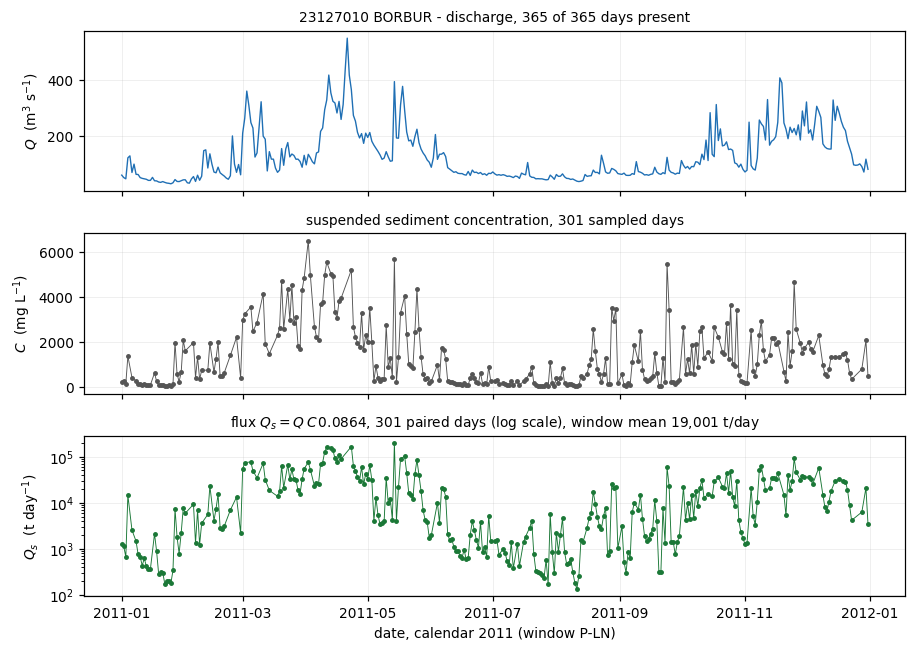

Q present 365/365 d | C sampled 301 d | paired 301 d
max single-day flux 193,988 t/day on 2011-05-14; min 134.4 t/day; ratio max/min 1,443x


In [5]:
c = 23127010
w = WIN['P-LN']
qs_ = QD[(QD.code == c) & QD.date.between(w['t0'], w['t1'])]
sd_ = SD[(SD.code == c) & SD.date.between(w['t0'], w['t1'])]
pr_ = PAIR[(PAIR.code == c) & PAIR.date.between(w['t0'], w['t1'])]

fig, ax = plt.subplots(3, 1, figsize=(8.4, 6.0), sharex=True)
ax[0].plot(qs_.date, qs_.q_m3s, color=CW, lw=0.9)
ax[0].set_ylabel('$Q$  (m$^3$ s$^{-1}$)')
ax[0].set_title(f'{c} {NM[c]} - discharge, {len(qs_)} of {w["days"]} days present')
ax[1].plot(sd_.date, sd_.ssc_mean_mg_l, color='#555555', lw=0.6, marker='o', ms=2.2)
ax[1].set_ylabel('$C$  (mg L$^{-1}$)')
ax[1].set_title(f'suspended sediment concentration, {len(sd_)} sampled days')
ax[2].plot(pr_.date, pr_.qs_tday, color=CA, lw=0.6, marker='o', ms=2.2)
ax[2].set_ylabel('$Q_s$  (t day$^{-1}$)')
ax[2].set_yscale('log')
ax[2].set_title(f'flux $Q_s = Q\\,C\\,0.0864$, {len(pr_)} paired days'
                f' (log scale), window mean {pr_.qs_tday.mean():,.0f} t/day')
ax[2].set_xlabel('date, calendar 2011 (window P-LN)')
for a in ax:
    a.grid(alpha=0.25, lw=0.5)
show(fig)
print(f'Q present {len(qs_)}/{w["days"]} d | C sampled {len(sd_)} d | paired {len(pr_)} d')
print(f'max single-day flux {pr_.qs_tday.max():,.0f} t/day on '
      f'{pr_.loc[pr_.qs_tday.idxmax(), "date"].date()}; '
      f'min {pr_.qs_tday.min():,.1f} t/day; ratio max/min '
      f'{pr_.qs_tday.max() / pr_.qs_tday.min():,.0f}x')

**What is plotted.** Three stacked panels sharing a date axis over calendar 2011 at station
`23127010` BORBUR. Top, blue: daily mean discharge $Q$ in m3/s. Middle, grey with markers: measured
SSC $C$ in mg/L, one marker per sampled day. Bottom, green with markers on a logarithmic axis: the
daily flux $Q_s = Q\,C\,0.0864$ in t/day, which exists only on days both inputs exist.

**What it shows.** Discharge is present on 365 of 365 days and concentration on 301, so 301 days
carry a flux. Within this one wet year the flux spans a factor of **1,443** - 193,988 t/day on
2011-05-14 against 134 t/day at the minimum - and the largest flux days coincide with the discharge
peaks rather than with the concentration peaks.

**What it means.** Two things the rest of the notebook depends on. First, flux is dominated by
water: the concentration series varies by about one order of magnitude while discharge, entering
multiplicatively and also driving concentration upward, produces three. That is why a *concentration*
comparison between ENSO phases would understate the contrast and why the flux conversion is not
cosmetic. Second, the within-year variability visible here is enormous, which is the warning
section 8 makes quantitative: seasonality inside a window is larger than the difference between
windows, so no single day and no single month can carry the result.

### 1.2 - Recomputing the frozen numbers from the raw records

Before any of stage C2's stored results are used, the first estimator is rebuilt from the raw
records and compared with the frozen table. For each station $i$ and window $w$, the quantity is
the arithmetic mean of the daily flux over the days that carry one:

$$\bar{Q}_s^{\,(a)}(i,w) \;=\; \frac{1}{n_{iw}}\sum_{t \in S_{iw}} Q(i,t)\,C(i,t)\,0.0864
\qquad [\mathrm{t\,day^{-1}}]$$

where $S_{iw}$ is the set of days inside window $w$ on which station $i$ has both a QC'd SSC value
and a same-day discharge, and $n_{iw} = |S_{iw}|$ is a count of days. Inputs:
`sediment_daily_qc.csv` and `discharge_daily.csv`. Output: one number in t/day per station-window,
plus $n_{iw}$.

The comparison target is columns `a_mean_tday` and `n_sample_days` of
`data/processed/c2/c2_station_window_flux.csv`, for the 38 station-windows that table marks
`a_status == 'ok'`. The test is not "are they close" but "are they identical to floating-point
round-off": the recipe is deterministic, so anything larger than about $10^{-15}$ relative
deviation would mean the two implementations differ.

station-windows with a_status == ok : 38
sample-day counts differing          : 0
max |relative deviation| in the mean : 4.441e-16
=> estimator (a) reproduced independently from the raw records for all 38 admissible station-windows


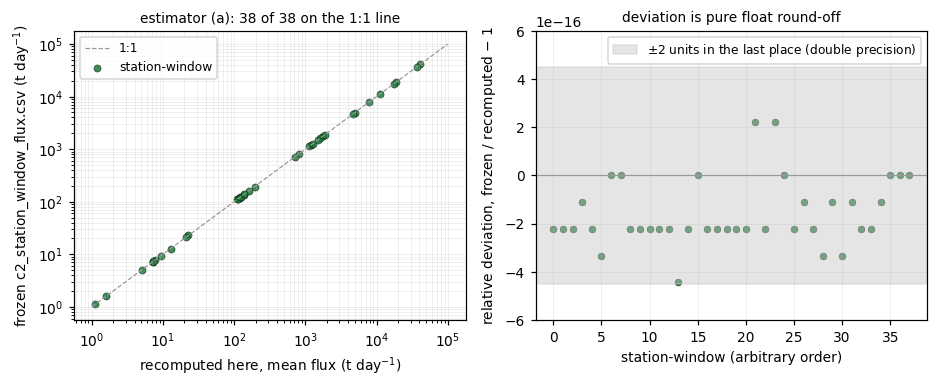

In [6]:
rows = []
for wname, w in WIN.items():
    g = PAIR[PAIR.date.between(w['t0'], w['t1'])]
    for cc, gg in g.groupby('code'):
        rows.append((cc, wname, len(gg), gg.qs_tday.mean()))
MINE = pd.DataFrame(rows, columns=['code', 'window', 'n_mine', 'a_mean_mine'])

CHK = FX.merge(MINE, on=['code', 'window'], how='left')
ok = CHK[CHK.a_status == 'ok'].copy()
ok['d_n'] = ok.n_sample_days - ok.n_mine
ok['rel'] = ok.a_mean_tday / ok.a_mean_mine - 1.0
print('station-windows with a_status == ok :', len(ok))
print('sample-day counts differing          :', int((ok.d_n != 0).sum()))
print('max |relative deviation| in the mean :', f'{ok.rel.abs().max():.3e}')
assert (ok.d_n == 0).all() and ok.rel.abs().max() < 1e-12
print('=> estimator (a) reproduced independently from the raw records for all',
      len(ok), 'admissible station-windows')

fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.6))
ax[0].loglog([1e0, 1e5], [1e0, 1e5], color='#999999', lw=0.8, ls='--', label='1:1')
ax[0].scatter(ok.a_mean_mine, ok.a_mean_tday, s=22, color=CA, alpha=0.85,
              edgecolor='k', linewidth=0.3, label='station-window')
ax[0].set_xlabel('recomputed here, mean flux (t day$^{-1}$)')
ax[0].set_ylabel('frozen c2_station_window_flux.csv (t day$^{-1}$)')
ax[0].set_title('estimator (a): 38 of 38 on the 1:1 line')
ax[0].legend(loc='upper left')
ax[0].grid(alpha=0.25, lw=0.5, which='both')
ax[1].axhline(0, color='#999999', lw=0.8)
ax[1].scatter(range(len(ok)), ok.rel, s=20, color=CA, edgecolor='k', linewidth=0.3)
ax[1].set_xlabel('station-window (arbitrary order)')
ax[1].set_ylabel('relative deviation, frozen / recomputed $-$ 1')
ax[1].set_ylim(-6e-16, 6e-16)
ax[1].axhspan(-4.5e-16, 4.5e-16, color='#cccccc', alpha=0.5,
              label='$\\pm$2 units in the last place (double precision)')
ax[1].set_title('deviation is pure float round-off')
ax[1].legend(loc='upper right')
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)

**What is plotted.** Left: the mean sample-day flux recomputed in this notebook (x, t/day, log)
against the value stored in the frozen C2 table (y, same units, log), one green marker per
station-window, with a dashed 1:1 line. Right: the relative deviation `frozen / recomputed - 1` for
the same 38 station-windows, against an arbitrary index, with the grey band marking two units in the
last place of double precision ($\pm 4.5\times10^{-16}$).

**What it shows.** All 38 markers sit on the 1:1 line, all 38 sample-day counts are identical, and
the largest relative deviation is $4.4\times10^{-16}$ - two units in the last place, inside the grey
band. Nothing is merely
close; the two implementations agree to the last bit.

**What it means.** The frozen C2 flux table is reproducible from the raw QC'd records by an
independent implementation, so the rest of this notebook may use its stored bootstrap intervals -
which are expensive to regenerate - without also inheriting an unverified level. This is the
cheapest possible audit of an artifact and it passed.

## 2 - The comparability rule, and why it is not pedantry

The two primary windows are **not the same length**: La Nina is 365 days, El Nino is 731. Stage C2
therefore registered a hard rule before computing anything (`docs/34` section 1.2):

> Cross-window comparison uses **RATES ONLY** - mean flux in t/day. Window **totals** in tonnes may
> appear as context, labelled with their window length, and are **never divided by each other**.

The reason is arithmetic, and it is worth making visible rather than asserting. Define for a station
the window **total**

$$T(i,w) \;=\; \bar{Q}_s(i,w)\times D_w \qquad [\mathrm{t}]$$

with $\bar{Q}_s$ the mean flux (t/day) and $D_w$ the window length (days). Then the two candidate
comparisons of wet against dry are related by a constant that has nothing to do with the river:

$$\underbrace{\frac{T(i,\mathrm{LN})}{T(i,\mathrm{EN})}}_{\text{total ratio}}
\;=\;\underbrace{\frac{\bar{Q}_s(i,\mathrm{LN})}{\bar{Q}_s(i,\mathrm{EN})}}_{\text{RATE ratio}}
\times\underbrace{\frac{D_{\mathrm{LN}}}{D_{\mathrm{EN}}}}_{\text{window-length ratio}}$$

For the primary pair the last factor is $365/731 = 0.4993$; for the sensitivity pair it is
$365/213 = 1.7136$. So a totals comparison **halves** every primary ratio and **inflates** every
sensitivity ratio by 71 %, and the two pairs - which are meant to bracket a definitional
uncertainty - would be pushed apart by a further factor of 3.43 for no physical reason at all. Any
station whose true rate ratio is below 2.0 would appear to move *more* sediment in the dry phase
than in the wet phase, purely because the dry window lasted twice as long.

The next three cells show the window lengths, then apply both comparisons to the real stations, then
isolate the arithmetic multiplier.

### 2.1 - The four windows on a calendar

This cell plots the windows as horizontal bars on a date axis, annotated with the day counts
computed in section 0.3. It computes nothing new: it is the definition made visible, because the
asymmetry is the point.

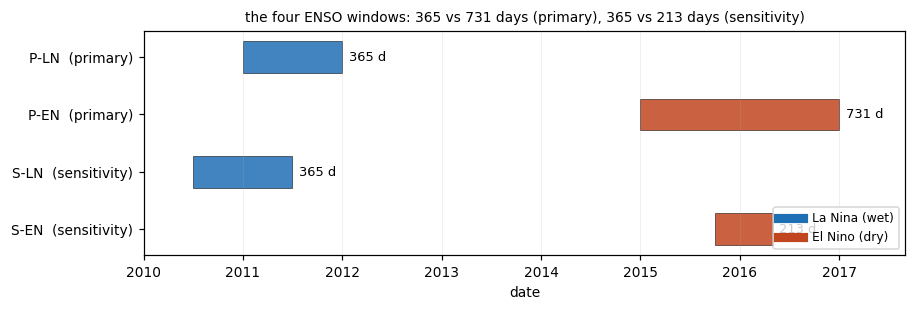

window-length ratios:  primary 0.4993  sensitivity 1.7136  ratio between them 3.432


In [7]:
fig, ax = plt.subplots(figsize=(8.4, 2.9))
order = ['P-LN', 'P-EN', 'S-LN', 'S-EN']
for i, k in enumerate(order):
    w = WIN[k]
    col = CW if w['phase'] == 'La Nina' else CD
    ax.barh(i, (w['t1'] - w['t0']).days + 1, left=w['t0'], height=0.55,
            color=col, alpha=0.85, edgecolor='k', linewidth=0.4)
    ax.text(w['t1'] + pd.Timedelta(days=25), i, f'{w["days"]} d', va='center', fontsize=8.5)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{k}  ({WIN[k]["pair"]})' for k in order])
ax.invert_yaxis()
ax.set_xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2017-09-01'))
ax.set_xlabel('date')
ax.set_title('the four ENSO windows: 365 vs 731 days (primary), 365 vs 213 days (sensitivity)')
ax.legend(handles=[Line2D([], [], color=CW, lw=6, label='La Nina (wet)'),
                   Line2D([], [], color=CD, lw=6, label='El Nino (dry)')], loc='lower right')
ax.grid(alpha=0.25, lw=0.5, axis='x')
show(fig)
print('window-length ratios:  primary', f'{PLEN:.4f}', ' sensitivity', f'{SLEN:.4f}',
      ' ratio between them', f'{SLEN / PLEN:.3f}')

**What is plotted.** Four horizontal bars on a date axis, one per window, blue for La Nina and
orange-red for El Nino, labelled with their length in days. The upper two are the primary pair, the
lower two the sensitivity pair.

**What it shows.** The primary dry bar is twice the length of the primary wet bar (731 against 365
days), while the sensitivity dry bar is *shorter* than its wet counterpart (213 against 365). The
wet-to-dry length ratio is 0.4993 in one pair and 1.7136 in the other, a factor of 3.43 apart.

**What it means.** There is no length-neutral way to compare these windows as totals, and the
asymmetry even reverses between the two pairs. Any statistic that scales with window length is
therefore not a property of the basin. Only a per-day rate is.

### 2.2 - The same stations compared as rates and as totals

This cell takes each station-window-pair-estimator combination that has a frozen **rate ratio**

$$R_{\text{rate}} = \frac{\bar{Q}_s(\mathrm{LN})}{\bar{Q}_s(\mathrm{EN})}\quad[\text{dimensionless}]$$

from `c2_rate_ratios.csv` (columns `a_ratio`, `b_ratio`), and forms the corresponding **total ratio**

$$R_{\text{total}} = R_{\text{rate}}\times\frac{D_{\mathrm{LN}}}{D_{\mathrm{EN}}}$$

using the day counts verified in section 0.3. Both are dimensionless. A ratio above 1 means the wet
phase moved more sediment; below 1 means the dry phase did. The figure marks $R=1$ with a heavy
line and shades the region below it, so a sign change is visible rather than arithmetical.

ratios present in the frozen table: 24
pair         est
primary      a      6
             b      7
sensitivity  a      4
             b      7


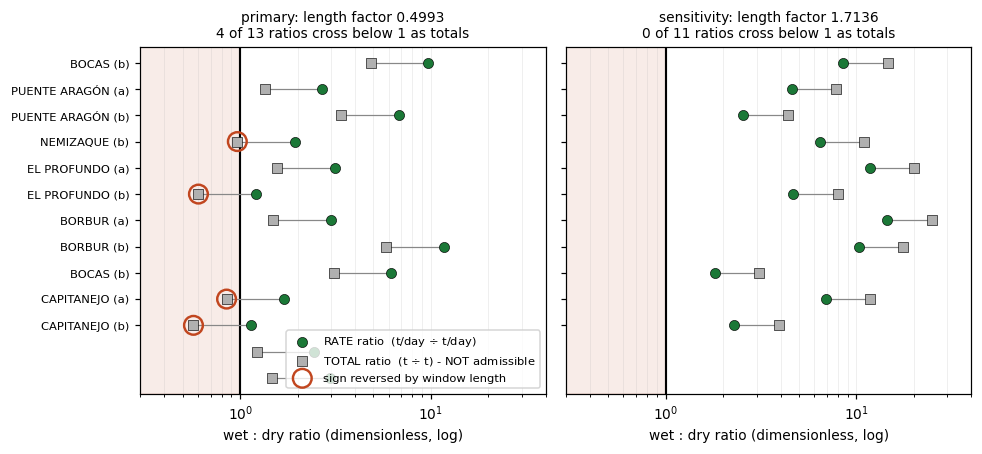


sign reversals if totals were compared:
   pair est     code         label  ratio  ratio_total
primary   b 26017060 PUENTE ARAGÓN  1.938        0.968
primary   a 21197010   EL PROFUNDO  1.212        0.605
primary   a 22017010         BOCAS  1.702        0.850
primary   b 22017010         BOCAS  1.141        0.570


In [8]:
rows = []
for _, x in RR.iterrows():
    for est, col in (('a', 'a_ratio'), ('b', 'b_ratio')):
        v = x[col]
        if pd.notna(v):
            partial = (est == 'b') and (min(x.b_cov_ln, x.b_cov_en) < 0.50)
            rows.append(dict(pair=x.pair, est=est, code=x.code, label=NM[x.code],
                             area=x.up_area_km2, ratio=v, lo=x[f'{est}_ratio_lo'],
                             hi=x[f'{est}_ratio_hi'], cov_ln=x.b_cov_ln, cov_en=x.b_cov_en,
                             partial=partial))
RAT = pd.DataFrame(rows)
RAT['lenfac'] = np.where(RAT.pair == 'primary', PLEN, SLEN)
RAT['ratio_total'] = RAT.ratio * RAT.lenfac
print('ratios present in the frozen table:', len(RAT))
print(RAT.groupby(['pair', 'est']).size().to_string())

fig, ax = plt.subplots(1, 2, figsize=(9.0, 4.2), sharey=True)
for j, pr in enumerate(['primary', 'sensitivity']):
    a = ax[j]
    s = RAT[RAT.pair == pr].sort_values(['area', 'est']).reset_index(drop=True)
    y = np.arange(len(s))
    a.axvspan(1e-2, 1.0, color=CD, alpha=0.10)
    a.axvline(1.0, color='k', lw=1.4)
    a.scatter(s.ratio, y, s=44, marker='o', color=CA, edgecolor='k', linewidth=0.4,
              label='RATE ratio  (t/day $\\div$ t/day)', zorder=3)
    a.scatter(s.ratio_total, y, s=44, marker='s', color='#b0b0b0', edgecolor='k',
              linewidth=0.4, label='TOTAL ratio  (t $\\div$ t) - NOT admissible', zorder=3)
    for i, r in s.iterrows():
        a.plot([r.ratio, r.ratio_total], [i, i], color='#888888', lw=0.8, zorder=2)
    flip = s[(s.ratio > 1) & (s.ratio_total < 1)]
    a.scatter(flip.ratio_total, flip.index, s=150, facecolor='none', edgecolor=CD,
              linewidth=1.6, zorder=4, label='sign reversed by window length')
    a.set_yticks(y)
    a.set_yticklabels([f'{r.label} ({r.est})' for _, r in s.iterrows()], fontsize=7.5)
    a.set_xscale('log')
    a.set_xlim(0.3, 40)
    a.set_xlabel('wet : dry ratio (dimensionless, log)')
    a.set_title(f'{pr}: length factor {s.lenfac.iloc[0]:.4f}\n'
                f'{len(flip)} of {len(s)} ratios cross below 1 as totals')
    a.grid(alpha=0.25, lw=0.5, axis='x', which='both')
ax[0].legend(loc='lower right', fontsize=7.5)
ax[0].invert_yaxis()
show(fig)
fl = RAT[(RAT.ratio > 1) & (RAT.ratio_total < 1)]
print('\nsign reversals if totals were compared:')
print(fl[['pair', 'est', 'code', 'label', 'ratio', 'ratio_total']].round(3).to_string(index=False))

**What is plotted.** Two panels, primary pair left and sensitivity pair right, sharing a
logarithmic x-axis of dimensionless wet:dry ratios. Each row is one station-estimator combination
(estimator in brackets after the station name), ordered by upstream area. A green circle is the
admissible **rate** ratio (t/day divided by t/day); a grey square is the inadmissible **total**
ratio (tonnes divided by tonnes) for the identical data; the grey line joins them. The heavy
vertical line is $R=1$ and the shaded region left of it is "dry phase moved more". A red ring marks
a comparison whose *sign* changes between the two.

**What it shows.** In the primary pair, 4 of the 13 ratios cross from above 1 to below 1 when the
same fluxes are compared as totals - `21197010` EL PROFUNDO falls from 1.21 to 0.61, `22017010`
BOCAS from 1.70 to 0.85 on estimator (a) and 1.14 to 0.57 on (b), and `26017060` PUENTE ARAGON from
1.94 to 0.97 on (b). In the sensitivity pair no ratio crosses; instead every one is inflated,
BORBUR moving from 10.3 to 17.6.

**What it means.** This is the demonstration, not the statement: on real stations, comparing window
totals would report that the *dry* phase moved more sediment than the wet phase at four of thirteen
comparisons, and would exaggerate the contrast in the other pair. Both effects are pure window
length. The comparability rule is therefore load-bearing - relaxing it would have produced a paper
with the wrong sign at nearly a third of its primary evidence - and every ratio quoted anywhere in
this notebook is a rate ratio.

### 2.3 - Isolating the artefact: the same data, two window definitions

The final cell of this section removes the river entirely. For each pair it plots the multiplier
$D_{\mathrm{LN}}/D_{\mathrm{EN}}$ that converts a rate ratio into a total ratio, and the ratio of
those multipliers between the two pairs:

$$\frac{D_{\mathrm{S\text{-}LN}}/D_{\mathrm{S\text{-}EN}}}
{D_{\mathrm{P\text{-}LN}}/D_{\mathrm{P\text{-}EN}}}
=\frac{1.7136}{0.4993}=3.43$$

Dimensionless; the only inputs are the four integers verified in section 0.3.

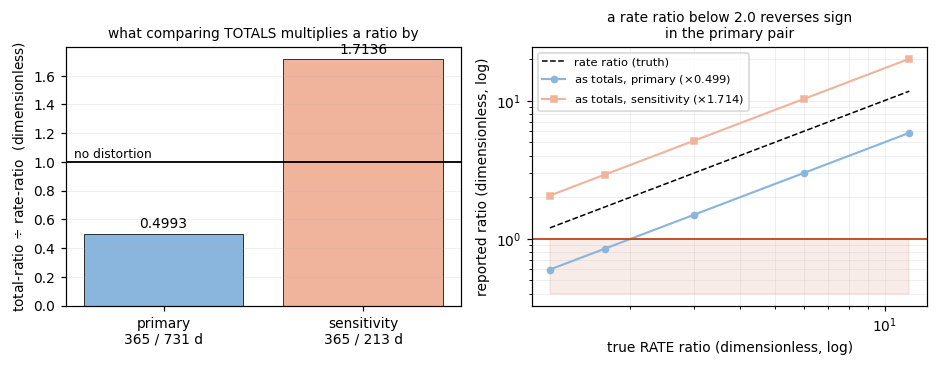

sensitivity multiplier / primary multiplier = 3.432
a rate ratio below 2.003 reports as < 1 (wrong sign) if compared as primary totals


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.4))
labs = ['primary\n365 / 731 d', 'sensitivity\n365 / 213 d']
vals = [PLEN, SLEN]
b = ax[0].bar(labs, vals, color=['#8ab6dd', '#f0b49c'], edgecolor='k', linewidth=0.5)
ax[0].axhline(1.0, color='k', lw=1.2)
ax[0].text(0.02, 1.03, 'no distortion', transform=ax[0].get_yaxis_transform(), fontsize=8)
for r, v in zip(b, vals):
    ax[0].text(r.get_x() + r.get_width() / 2, v + 0.04, f'{v:.4f}', ha='center', fontsize=9)
ax[0].set_ylabel('total-ratio $\\div$ rate-ratio  (dimensionless)')
ax[0].set_title('what comparing TOTALS multiplies a ratio by')
ax[0].grid(alpha=0.25, lw=0.5, axis='y')

demo = np.array([1.2, 1.7, 3.0, 6.0, 11.7])
ax[1].plot(demo, demo, color='k', lw=1.0, ls='--', label='rate ratio (truth)')
ax[1].plot(demo, demo * PLEN, color='#8ab6dd', lw=1.4, marker='o', ms=4,
           label=f'as totals, primary ($\\times${PLEN:.3f})')
ax[1].plot(demo, demo * SLEN, color='#f0b49c', lw=1.4, marker='s', ms=4,
           label=f'as totals, sensitivity ($\\times${SLEN:.3f})')
ax[1].axhline(1.0, color=CD, lw=1.2)
ax[1].fill_between([demo.min(), demo.max()], 0.4, 1.0, color=CD, alpha=0.10)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('true RATE ratio (dimensionless, log)')
ax[1].set_ylabel('reported ratio (dimensionless, log)')
ax[1].set_title('a rate ratio below 2.0 reverses sign\nin the primary pair')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, which='both')
show(fig)
print(f'sensitivity multiplier / primary multiplier = {SLEN / PLEN:.3f}')
print(f'a rate ratio below {1 / PLEN:.3f} reports as < 1 (wrong sign) if compared as primary totals')

**What is plotted.** Left: the two window-length multipliers as bars, with the heavy line at 1.0
marking "no distortion". Right: for a set of illustrative true rate ratios (x, log) the value that
would be *reported* (y, log) under each totals convention - dashed black is the truth, blue the
primary convention, orange the sensitivity convention - with the red line at 1.0 and the shaded
region below it marking a reported reversal of sign.

**What it shows.** The primary convention multiplies every ratio by 0.4993 and the sensitivity
convention by 1.7136, a spread of 3.43 from calendar arithmetic alone. Any true rate ratio below
**2.003** is reported as below 1 under the primary totals convention.

**What it means.** The two window pairs exist to bracket a *definitional* uncertainty about when an
ENSO phase begins and ends (section 6). Comparing totals would add a 3.43-fold *arithmetic*
distortion on top of that, making the bracket uninterpretable. Window totals appear exactly once in
this notebook, in section 5.4, as labelled context with their day count attached, and are never
divided.

## 3 - The two estimators, what each assumes, and why both are reported

There are two ways to turn a sparse concentration record into a window mean flux, and they fail in
opposite directions. Stage C2 registered both, in advance, and reports both everywhere.

**Estimator (a), the sample-day mean.** Average the flux over the days that were actually sampled.
It uses only measured concentrations - no fitted relationship at all - and its assumption is stated
in one sentence: *the sampled days are representative of the window*. If a station is sampled
preferentially at high flow, (a) is biased high; at low flow, biased low.

**Estimator (b), the rating-curve flux.** Fit a relationship between flux and discharge on the
station's own historical sample pairs, then apply it to **every** day in the window that has a
discharge value. It uses all days, so the sampling schedule cannot bias it, but it inherits whatever
the fitted relationship gets wrong - and section 3.2 shows the fitted relationship is blunt.

Neither is the truth. Their **disagreement is a diagnostic**, and stage C2 registered a rule turning
that disagreement into a specific accusation (section 7.1).

### 3.1 - Estimator (a) and its two admissibility gates

$$\bar{Q}_s^{\,(a)}(i,w)=\frac{1}{n_{iw}}\sum_{t\in S_{iw}}Q(i,t)\,C(i,t)\,0.0864
\qquad[\mathrm{t\,day^{-1}}]$$

already recomputed and verified in section 1.2. Two **pre-registered gates** decide whether it may
be reported for a given station-window:

1. **Sample size.** $n_{iw}\ge 12$ days. Below that the cell is written `n<12` and left empty. The
   floor comes from stage C1 (`docs/32`), not from inspecting C2's results.
2. **Sampling selectivity.** Stage C1 tested each station for **sampling selectivity** - a
   systematic tendency to sample at unusual flows. The test statistic is the **median flow
   percentile of sampled days**: for each sampled day, what fraction of that station's discharge
   record lies below that day's discharge (dimensionless, 0 to 1); take the median over sampled
   days. If sampling were blind to flow this median would be about 0.5. C1 compares it against the
   99th percentile of its own null distribution, $p_{99}(n)=0.5+2.326/(2\sqrt{n})$, and raises
   `flag_flow_selective` when it is **exceeded**. A flagged station gets **no** estimator (a) at all
   - its sample mean is declared unusable by the C1 registration - and the cell is written
   `flow-selective`.

Gate 2 is registered **one-sided**, and section 9.2 shows with measurements that this is a real
defect: it can only catch high-flow-biased sampling, and the station-windows that actually damaged
this stage were biased *low*. It is reported here as C1 wrote it, because thresholds are frozen once
registered; the correction is filed as an issue, not applied retroactively.

The cell below counts the outcome of both gates over all $18\times4=72$ station-windows, from
columns `a_status` and `b_status` of `c2_station_window_flux.csv`.

station-windows: 72 = 18 stations x 4 windows
estimator (a): {'ok': 38, 'n<12': 30, 'flow-selective': 4}
estimator (b): {'ok': 39, 'partial-rating': 7, 'no rating days': 26}
flow-selective stations in the C2 set: [26127010] = ['EL ALAMBRADO']


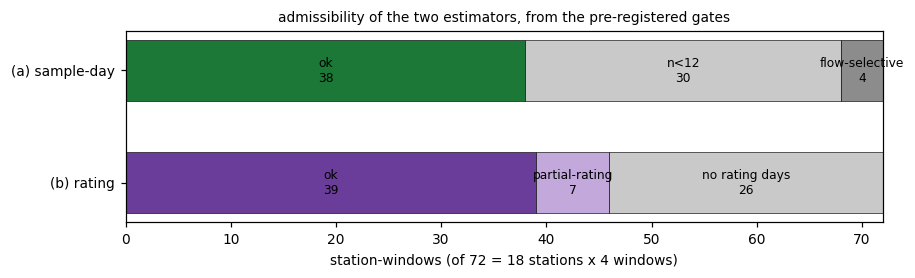

In [10]:
A_ORD = ['ok', 'n<12', 'flow-selective']
B_ORD = ['ok', 'partial-rating', 'no rating days']
acnt = FX.a_status.value_counts().reindex(A_ORD).fillna(0).astype(int)
bcnt = FX.b_status.value_counts().reindex(B_ORD).fillna(0).astype(int)
selcodes = sorted({int(x) for x in FX.loc[FX.flow_selective, 'code']})
print('station-windows:', len(FX), '=', FX.code.nunique(), 'stations x',
      FX.window.nunique(), 'windows')
print('estimator (a):', acnt.to_dict())
print('estimator (b):', bcnt.to_dict())
print('flow-selective stations in the C2 set:', selcodes, '=', [NM[x] for x in selcodes])

fig, ax = plt.subplots(figsize=(8.4, 2.6))
cols_a = {'ok': CA, 'n<12': '#c9c9c9', 'flow-selective': '#8c8c8c'}
cols_b = {'ok': CB, 'partial-rating': '#c3a8dc', 'no rating days': '#c9c9c9'}
left = 0
for k in A_ORD:
    ax.barh(1, acnt[k], left=left, height=0.55, color=cols_a[k], edgecolor='k', linewidth=0.4)
    if acnt[k]:
        ax.text(left + acnt[k] / 2, 1, f'{k}\n{acnt[k]}', ha='center', va='center', fontsize=8)
    left += acnt[k]
left = 0
for k in B_ORD:
    ax.barh(0, bcnt[k], left=left, height=0.55, color=cols_b[k], edgecolor='k', linewidth=0.4)
    if bcnt[k]:
        ax.text(left + bcnt[k] / 2, 0, f'{k}\n{bcnt[k]}', ha='center', va='center', fontsize=8)
    left += bcnt[k]
ax.set_yticks([1, 0])
ax.set_yticklabels(['(a) sample-day', '(b) rating'])
ax.set_xlim(0, 72)
ax.set_xlabel('station-windows (of 72 = 18 stations x 4 windows)')
ax.set_title('admissibility of the two estimators, from the pre-registered gates')
show(fig)

**What is plotted.** Two horizontal stacked bars, each spanning all 72 station-windows. Top:
estimator (a) split into admissible (green), blocked for fewer than 12 sample days (light grey) and
blocked as flow-selective (dark grey). Bottom: estimator (b) split into admissible (purple), reduced
rating coverage (light purple, defined in section 3.2) and impossible for want of rating days (light
grey).

**What it shows.** Estimator (a) is admissible at **38** of 72 station-windows; 30 are blocked by the
12-day floor and 4 by the selectivity flag - all 4 belonging to the single flagged station,
`26127010` EL ALAMBRADO. Estimator (b) is admissible at **39**, `partial-rating` at 7, and outright
impossible at **26**.

**What it means.** Half the design is unusable, for two entirely different reasons. The selectivity
gate costs almost nothing here (one station of eighteen), which sounds reassuring and is not:
section 9.2 shows the gate is one-sided and that a symmetric version at the same nominal level would
have flagged thirteen of eighteen. The 26 station-windows where (b) is impossible are the subject of
section 4, and they are the finding that governs the whole stage.

### 3.2 - Estimator (b): the rating curve, its eras, and the retransformation problem

A **rating curve** here is a power law between daily sediment flux and daily discharge, fitted in
logarithms so that it is linear:

$$\ln Q_s \;=\; \log a \;+\; b\,\ln Q \;+\; \varepsilon,
\qquad \varepsilon \ \text{with standard deviation } \sigma_{\ln}\ \ [\text{ln-units}]$$

where $Q_s$ is flux (t/day), $Q$ is discharge (m3/s), $\log a$ and $b$ are dimensionless
coefficients fitted by ordinary least squares on that station's own historical paired days, and
$\sigma_{\ln}$ is the residual standard deviation in natural-log units. Fitted values are read from
`ssc_rating_fits.csv` (columns `log_a`, `b`, `resid_sigma`, `r2`, `n_pairs`).

An **era** is a period over which one rating is assumed valid. A river's rating changes when the
channel changes - a flood re-cuts the bed, a reservoir traps sediment - so `ssc_station_eras.csv`
splits each record at detected change points and each era gets its own fit. Days falling inside no
era get no estimate.

**The retransformation problem, and why it must be corrected.** Because the fit is in logarithms,
$\exp(\log a + b\ln Q)$ estimates the **median** of $Q_s$ given $Q$, not its mean. A mass flux is a
sum, and a sum needs the **conditional mean**. Stage C2 registered **Duan's smearing estimator**:

$$\hat{Q}_s(t) \;=\; \exp\!\big(\log a + b\ln Q(t)\big)\times S,
\qquad S=\frac{1}{N}\sum_{j=1}^{N}\exp(\varepsilon_j)$$

where the $\varepsilon_j$ are that era's own $N$ fit residuals and $S$ is the dimensionless
**smearing factor**, always $\ge 1$. If the residuals were exactly log-normal, $S$ would equal
$\exp(\sigma_{\ln}^2/2)$; comparing measured $S$ against that expression is a check on the residual
distribution, done in section 3.3.

The window value is a rate, per the section 2 rule:

$$\bar{Q}_s^{\,(b)}(i,w)=\frac{1}{|D_{iw}|}\sum_{t\in D_{iw}}\hat{Q}_s(i,t)\qquad[\mathrm{t\,day^{-1}}]$$

over $D_{iw}$, the window days carrying a discharge value **and** falling in a usable era.
**Rating coverage** $\mathrm{cov}=|D_{iw}|/D_w$ (dimensionless, 0 to 1) is reported next to every
value; a station-window with $\mathrm{cov}<0.50$ is labelled `partial-rating`, kept in the full table
and excluded from the headline.

One caveat registered by stage C1 and repeated here because it limits how much weight the rating may
carry: $\ln Q_s$ contains $\ln Q$ by construction ($Q_s = QC\times0.0864$), so a high $R^2$ of
$Q_s$ on $Q$ is partly self-correlation. The honest measure is the fit of *concentration* on
discharge, column `r2_conc`, whose fleet median is far lower. Both are printed below.

The cell refits BORBUR's era from the raw pairs to confirm the stored coefficients, then plots the
curve with its scatter.

rating eras: all stations 30 | C2 station set 20
era break reasons (all stations): {'no in-record SNHT break (docs/17 3.8)': 26, 'pre-break segment': 2, 'docs/17 3.8 BOCAS twin, -35 % (physical)': 1, 'docs/17 3.8 BOCAS twin, +41 % (physical)': 1}
C2-set fits: median b 1.5732 | median sigma_ln 0.8391 | median R2(Qs~Q) 0.5569 | median R2(C~Q) 0.1455  <- the honest one

23127010 BORBUR era 1  1990-01-01 .. 2018-12-31  n_pairs stored 6813 / refitted here 6813
  stored    log_a 0.157925  b 1.854866  sigma_ln 1.040870
  refitted  log_a 0.157925  b 1.854866  sigma_ln 1.040870
  Duan S measured 1.676928   exp(sigma^2/2) 1.718935
  one-sigma multiplicative spread exp(sigma_ln) = 2.832x


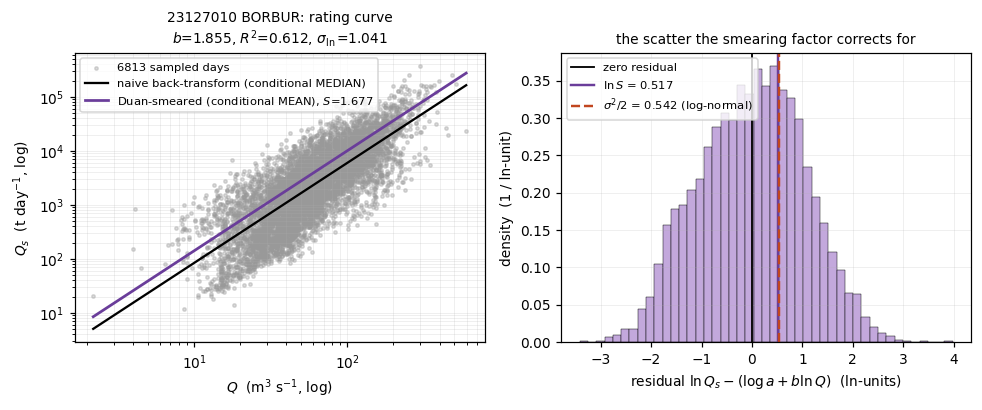

In [11]:
FIT = pd.read_csv(FILES['ssc_fits'])
ERAS = pd.read_csv(FILES['ssc_eras'])
FITU = FIT[FIT.code.isin(CODES)].copy()
print('rating eras: all stations', len(FIT), '| C2 station set', len(FITU))
print('era break reasons (all stations):', ERAS.break_source.value_counts().to_dict())
print(f'C2-set fits: median b {FITU.b.median():.4f} | median sigma_ln'
      f' {FITU.resid_sigma.median():.4f} | median R2(Qs~Q) {FITU.r2.median():.4f}'
      f' | median R2(C~Q) {FITU.r2_conc.median():.4f}  <- the honest one')

c = 23127010
e = FITU[FITU.code == c].iloc[0]
g = PAIR[(PAIR.code == c) & (PAIR.date >= pd.Timestamp(e.era_start))
         & (PAIR.date <= pd.Timestamp(e.era_end)) & (PAIR.q_m3s > 0) & (PAIR.qs_tday > 0)]
bb, aa = np.polyfit(np.log(g.q_m3s), np.log(g.qs_tday), 1)
resid = np.log(g.qs_tday) - (e.log_a + e.b * np.log(g.q_m3s))
S_meas = float(np.exp(resid).mean())
print(f'\n{c} {NM[c]} era {int(e.era)}  {e.era_start} .. {e.era_end}'
      f'  n_pairs stored {int(e.n_pairs)} / refitted here {len(g)}')
print(f'  stored    log_a {e.log_a:.6f}  b {e.b:.6f}  sigma_ln {e.resid_sigma:.6f}')
print(f'  refitted  log_a {aa:.6f}  b {bb:.6f}  sigma_ln {resid.std(ddof=2):.6f}')
print(f'  Duan S measured {S_meas:.6f}   exp(sigma^2/2) {np.exp(e.resid_sigma ** 2 / 2):.6f}')
print(f'  one-sigma multiplicative spread exp(sigma_ln) = {np.exp(e.resid_sigma):.3f}x')

qgrid = np.logspace(np.log10(g.q_m3s.min()), np.log10(g.q_m3s.max()), 60)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.8))
ax[0].scatter(g.q_m3s, g.qs_tday, s=5, color='#999999', alpha=0.35,
              label=f'{len(g)} sampled days')
ax[0].plot(qgrid, np.exp(e.log_a + e.b * np.log(qgrid)), color='#000000', lw=1.5,
           label='naive back-transform (conditional MEDIAN)')
ax[0].plot(qgrid, np.exp(e.log_a + e.b * np.log(qgrid)) * S_meas, color=CB, lw=1.8,
           label=f'Duan-smeared (conditional MEAN), $S$={S_meas:.3f}')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('$Q$  (m$^3$ s$^{-1}$, log)')
ax[0].set_ylabel('$Q_s$  (t day$^{-1}$, log)')
ax[0].set_title(f'{c} {NM[c]}: rating curve\n$b$={e.b:.3f}, $R^2$={e.r2:.3f},'
                f' $\\sigma_{{\\ln}}$={e.resid_sigma:.3f}')
ax[0].legend(loc='upper left', fontsize=7.5)
ax[0].grid(alpha=0.25, lw=0.5, which='both')

ax[1].hist(resid, bins=45, color='#c3a8dc', edgecolor='k', linewidth=0.3, density=True)
ax[1].axvline(0, color='k', lw=1.2, label='zero residual')
ax[1].axvline(np.log(S_meas), color=CB, lw=1.6, label=f'$\\ln S$ = {np.log(S_meas):.3f}')
ax[1].axvline(e.resid_sigma ** 2 / 2, color='#c1461f', lw=1.6, ls='--',
              label=f'$\\sigma^2/2$ = {e.resid_sigma ** 2 / 2:.3f} (log-normal)')
ax[1].set_xlabel('residual $\\ln Q_s - (\\log a + b\\ln Q)$  (ln-units)')
ax[1].set_ylabel('density  (1 / ln-unit)')
ax[1].set_title('the scatter the smearing factor corrects for')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)

**What is plotted.** Left, log-log: every one of BORBUR's 6,813 historical sampled days as a grey
point ($Q$ in m3/s against $Q_s$ in t/day), the fitted power law back-transformed naively in black
(the conditional median) and the Duan-smeared version in purple (the conditional mean). Right: the
histogram of the fit residuals in natural-log units, with zero in black, $\ln S$ in purple and the
log-normal expectation $\sigma^2/2$ dashed red.

**What it shows.** The refit reproduces the stored coefficients exactly - $\log a = 0.157925$,
$b = 1.854866$, $\sigma_{\ln} = 1.040870$ - so the frozen rating table is verified the same way the
flux table was in section 1.2. The scatter is very wide: $\sigma_{\ln} = 1.041$ is a
$e^{1.041} = 2.83\times$ one-standard-deviation multiplicative spread about the line. Across the
20 rating eras of the C2 set the median $R^2$ of flux on discharge is 0.557 but the median $R^2$ of
*concentration* on discharge is only **0.146**. The smearing factor here is $S = 1.677$.

**What it means.** The rating estimator is legitimate but blunt: it predicts a window mean, never a
day, and the honest statement of its information content is the 0.146 - most of the apparent
tightness of a flux rating is the discharge predicting itself. The retransformation, meanwhile, is
not a technicality: at this station it is worth **68 %**, larger than several of the effects this
notebook argues about, so omitting it would have biased every rating flux downward by tens of
percent.

### 3.3 - Is the smearing factor believable? Measured $S$ against the log-normal expectation

For every era of the 18-station set this cell recomputes from the raw pairs

$$S=\frac{1}{N}\sum_j \exp(\varepsilon_j)\ \ \text{(measured, dimensionless)}\qquad\text{versus}\qquad
\exp(\sigma_{\ln}^2/2)\ \ \text{(log-normal expectation, dimensionless)}$$

with residuals $\varepsilon_j$ formed against the **stored** coefficients rather than a refit, so
this is a property of the frozen fits. Inputs: `ssc_rating_fits.csv` for $\log a$, $b$,
$\sigma_{\ln}$ and the era bounds; `PAIR` for the pairs. It then cross-checks the same quantity a
third way: because $S$ multiplies every predicted day, the ratio of the two flux columns in the
frozen C2 table,

$$S \;=\; \frac{\texttt{b\_mean\_tday}}{\texttt{b\_mean\_tday\_naive}}$$

must return the same factor for a station-window served by one era.

eras of the C2 station set with usable pairs: 20
measured Duan S : min 1.0800  max 1.8321  median 1.4778    docs/34 s3 says "1.080 - 1.832, median 1.478"
exp(sigma^2/2)  : min 1.0835  max 1.8258  median 1.4220    docs/34 s4.1 says "1.083 - 1.826"
S recovered from the frozen flux columns (46 station-windows): min 1.0800  max 1.8321  median 1.5603
note the population difference: the RANGE is identical, the MEDIAN is not (1.478 per era vs 1.560 per station-window) - see section 9.5


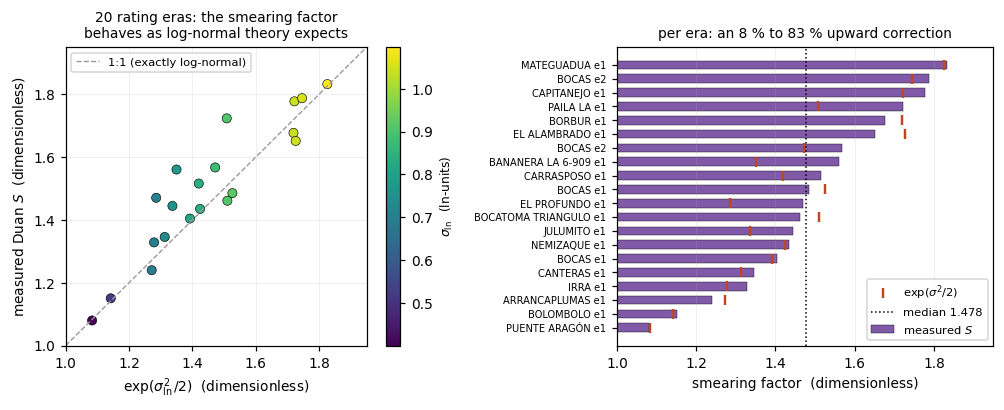

In [12]:
rows = []
for _, e in FITU.iterrows():
    g = PAIR[(PAIR.code == e.code) & (PAIR.date >= pd.Timestamp(e.era_start))
             & (PAIR.date <= pd.Timestamp(e.era_end)) & (PAIR.q_m3s > 0) & (PAIR.qs_tday > 0)]
    if len(g) < 5:
        continue
    r = np.log(g.qs_tday) - (e.log_a + e.b * np.log(g.q_m3s))
    rows.append(dict(code=e.code, label=NM[e.code], era=int(e.era), n=len(g),
                     sigma=e.resid_sigma, b=e.b, r2=e.r2,
                     S_meas=float(np.exp(r).mean()),
                     S_logn=float(np.exp(e.resid_sigma ** 2 / 2))))
SM = pd.DataFrame(rows)
FXS = FX.assign(S_rec=FX.b_mean_tday / FX.b_mean_tday_naive).dropna(subset=['S_rec'])
print(f'eras of the C2 station set with usable pairs: {len(SM)}')
print(f'measured Duan S : min {SM.S_meas.min():.4f}  max {SM.S_meas.max():.4f}'
      f'  median {SM.S_meas.median():.4f}    docs/34 s3 says "1.080 - 1.832, median 1.478"')
print(f'exp(sigma^2/2)  : min {SM.S_logn.min():.4f}  max {SM.S_logn.max():.4f}'
      f'  median {SM.S_logn.median():.4f}    docs/34 s4.1 says "1.083 - 1.826"')
print(f'S recovered from the frozen flux columns ({len(FXS)} station-windows):'
      f' min {FXS.S_rec.min():.4f}  max {FXS.S_rec.max():.4f}  median {FXS.S_rec.median():.4f}')
print('note the population difference: the RANGE is identical, the MEDIAN is not'
      ' (1.478 per era vs 1.560 per station-window) - see section 9.5')

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.8))
lim = [1.0, 1.95]
ax[0].plot(lim, lim, color='#999999', ls='--', lw=0.9, label='1:1 (exactly log-normal)')
sc = ax[0].scatter(SM.S_logn, SM.S_meas, s=36, c=SM.sigma, cmap='viridis',
                   edgecolor='k', linewidth=0.4)
fig.colorbar(sc, ax=ax[0]).set_label('$\\sigma_{\\ln}$  (ln-units)', fontsize=8)
ax[0].set_xlim(lim)
ax[0].set_ylim(lim)
ax[0].set_xlabel('$\\exp(\\sigma_{\\ln}^2/2)$  (dimensionless)')
ax[0].set_ylabel('measured Duan $S$  (dimensionless)')
ax[0].set_title(f'{len(SM)} rating eras: the smearing factor\nbehaves as log-normal theory expects')
ax[0].legend(loc='upper left', fontsize=7.5)
ax[0].grid(alpha=0.25, lw=0.5)

s = SM.sort_values('S_meas').reset_index(drop=True)
y = np.arange(len(s))
ax[1].barh(y, s.S_meas - 1.0, left=1.0, height=0.62, color=CB, alpha=0.85,
           edgecolor='k', linewidth=0.3, label='measured $S$')
ax[1].scatter(s.S_logn, y, s=40, color='#c1461f', marker='|', linewidth=1.6,
              label='$\\exp(\\sigma^2/2)$')
ax[1].axvline(1.0, color='k', lw=1.0)
ax[1].axvline(SM.S_meas.median(), color='#000000', lw=1.0, ls=':',
              label=f'median {SM.S_meas.median():.3f}')
ax[1].set_yticks(y)
ax[1].set_yticklabels([f'{r.label} e{r.era}' for _, r in s.iterrows()], fontsize=6.5)
ax[1].set_xlim(1.0, 1.95)
ax[1].set_xlabel('smearing factor  (dimensionless)')
ax[1].set_title('per era: an 8 % to 83 % upward correction')
ax[1].legend(loc='lower right', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, axis='x')
show(fig)

**What is plotted.** Left: measured Duan $S$ (y) against the log-normal expectation
$\exp(\sigma_{\ln}^2/2)$ (x), both dimensionless, one point per rating era, coloured by that era's
residual standard deviation, with a dashed 1:1 line. Right: the same measured factors as purple bars
drawn from 1.0, one per era, ordered by size, with the log-normal expectation as a red tick and the
median dotted.

**What it shows.** The 20 eras of the C2 station set give measured $S$ from **1.0800 to 1.8321**,
median **1.4778**; $\exp(\sigma^2/2)$ runs from **1.0835 to 1.8258**, median 1.4220. The points
scatter about the 1:1 line with no systematic departure. Recovering $S$ from the ratio of the frozen
table's two flux columns gives the identical range, 1.0800 to 1.8321.

**What it means.** Three independent routes to the same numbers - raw residuals, the log-normal
identity, and the frozen table's own columns - agree, so the retransformation is implemented
correctly and the residual distribution is close enough to log-normal that the correction is not
carried by a handful of extreme residuals. It also settles a number: `docs/34`'s "1.080-1.832, fleet
median 1.478" is reproduced **exactly when the population is the rating eras**. Computed instead over
the 46 station-windows the median is 1.560 - same data, different population. That distinction nearly
became a false discrepancy report, and it is logged in section 9.5 as a caution rather than as a
defect of the doc.

### 3.4 - Confidence intervals: what a bootstrap resamples, and what it cannot see

A **bootstrap confidence interval** answers "how much would this number have moved had the data come
out slightly differently?" without assuming a distribution for it. The recipe: build many artificial
datasets by drawing from the real one **with replacement**, recompute the statistic on each, and read
percentiles off the resulting spread. The 2.5th and 97.5th percentiles give a 95 % interval.

*What* is resampled differs between the estimators, and this is the part most easily misread:

- **Estimator (a)**: the **sampled days themselves**, independently and with replacement, 2,000 times
  (registered seed 20260810). The interval answers *had a different set of days of this size been
  sampled, how much would the mean have moved?*
  $$\bar{Q}_s^{(a),k}=\frac{1}{n}\sum_{j=1}^{n}Q_s\big(t^{(k)}_j\big),\qquad
  t^{(k)}_j\ \text{drawn uniformly from } S_{iw},\quad k=1\ldots2000$$
- **Estimator (b)**: two sources combined, 1,000 times. **Parameter** uncertainty - the era's own
  $(\ln Q,\ln Q_s)$ pairs are resampled and $\log a, b$ refitted, so the *line* moves. And
  **scatter** - the era's residuals are resampled in **30-day blocks** and added to each predicted
  day. Blocks, not individual residuals, because daily residuals are strongly autocorrelated (a
  muddy week stays muddy) and an independent residual bootstrap would pretend there is far more
  independent information than there is, collapsing the interval.

**Registered limitation, written in `docs/34` section 1.4 before the numbers existed and repeated
here because it governs how the result may be quoted:** sampled days are not a random sample of
window days and daily flux is autocorrelated, so the estimator (a) interval is a **lower bound** on
the true uncertainty. These intervals may support "this ratio is distinguishable from 1"; they may
not be used to claim a precision.

The cell re-runs the registered estimator (a) bootstrap for one station-window and compares with the
frozen interval, then compares interval widths between estimators.

23127010 BORBUR P-LN: n = 301 sampled days, mean 19,001.44 t/day
  re-run here : [15,729.93, 22,496.15]
  frozen table: [15,724.13, 22,436.52]
  agreement   : lower 0.04 %, upper 0.27 %  (Monte-Carlo noise, not bitwise: the frozen run consumed its RNG stream across all stations in a different order)


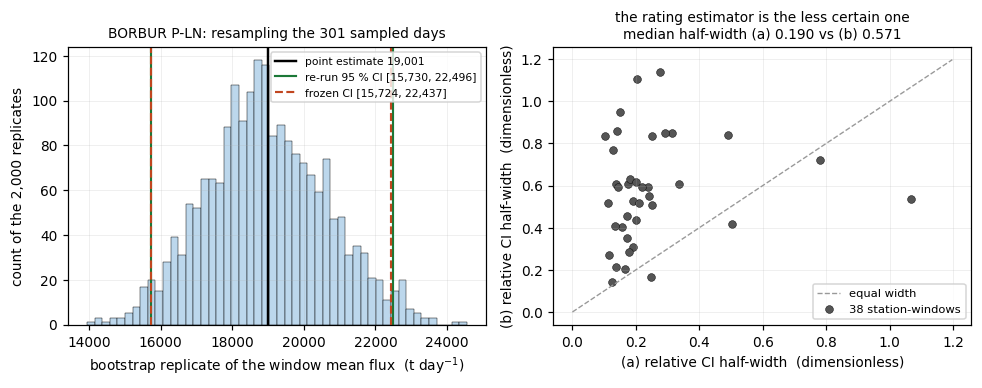


(b) interval wider than (a) at 34 of 38 station-windows admitting both estimators


In [13]:
c, wn = 23127010, 'P-LN'
fr = FX[(FX.code == c) & (FX.window == wn)].iloc[0]
w = WIN[wn]
qs = PAIR[(PAIR.code == c) & PAIR.date.between(w['t0'], w['t1'])].qs_tday.values
rng = np.random.default_rng(20260810)
BS = qs[rng.integers(0, len(qs), (2000, len(qs)))].mean(axis=1)
lo, hi = np.percentile(BS, [2.5, 97.5])
print(f'{c} {NM[c]} {wn}: n = {len(qs)} sampled days, mean {qs.mean():,.2f} t/day')
print(f'  re-run here : [{lo:,.2f}, {hi:,.2f}]')
print(f'  frozen table: [{fr.a_lo:,.2f}, {fr.a_hi:,.2f}]')
print(f'  agreement   : lower {abs(lo / fr.a_lo - 1) * 100:.2f} %, upper'
      f' {abs(hi / fr.a_hi - 1) * 100:.2f} %  (Monte-Carlo noise, not bitwise: the frozen run'
      ' consumed its RNG stream across all stations in a different order)')

AG2 = AG.copy()
AG2['half_a'] = (AG2.a_hi - AG2.a_lo) / (2 * AG2.a)
AG2['half_b'] = (AG2.b_hi - AG2.b_lo) / (2 * AG2.b)

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.6))
ax[0].hist(BS, bins=50, color='#bcd7ec', edgecolor='k', linewidth=0.3)
ax[0].axvline(qs.mean(), color='k', lw=1.6, label=f'point estimate {qs.mean():,.0f}')
ax[0].axvline(lo, color=CA, lw=1.4, label=f're-run 95 % CI [{lo:,.0f}, {hi:,.0f}]')
ax[0].axvline(hi, color=CA, lw=1.4)
ax[0].axvline(fr.a_lo, color='#c1461f', lw=1.4, ls='--',
              label=f'frozen CI [{fr.a_lo:,.0f}, {fr.a_hi:,.0f}]')
ax[0].axvline(fr.a_hi, color='#c1461f', lw=1.4, ls='--')
ax[0].set_xlabel('bootstrap replicate of the window mean flux  (t day$^{-1}$)')
ax[0].set_ylabel('count of the 2,000 replicates')
ax[0].set_title(f'{NM[c]} {wn}: resampling the {len(qs)} sampled days')
ax[0].legend(loc='upper right', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5)

mx = max(AG2.half_a.max(), AG2.half_b.max()) * 1.05
ax[1].plot([0, mx], [0, mx], color='#999999', ls='--', lw=0.9, label='equal width')
ax[1].scatter(AG2.half_a, AG2.half_b, s=26, color='#555555', edgecolor='k', linewidth=0.3,
              label=f'{len(AG2)} station-windows')
ax[1].set_xlabel('(a) relative CI half-width  (dimensionless)')
ax[1].set_ylabel('(b) relative CI half-width  (dimensionless)')
ax[1].set_title('the rating estimator is the less certain one\n'
                f'median half-width (a) {AG2.half_a.median():.3f}'
                f' vs (b) {AG2.half_b.median():.3f}')
ax[1].legend(loc='lower right', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)
print(f'\n(b) interval wider than (a) at {int((AG2.half_b > AG2.half_a).sum())} of {len(AG2)}'
      ' station-windows admitting both estimators')

**What is plotted.** Left: the histogram of 2,000 bootstrap replicates of BORBUR's 2011 mean flux
(x in t/day, y a count of replicates), with the point estimate as a heavy black line, the re-run 95 %
interval in green and the frozen interval dashed red. Right: relative confidence-interval half-width
of estimator (b) against that of estimator (a), both dimensionless, one point per station-window
admitting both, with a dashed equal-width line.

**What it shows.** The re-run interval is [15,730, 22,496] t/day against the frozen
[15,724, 22,437] - 0.04 % at the lower limit and 0.27 % at the upper, which is Monte-Carlo noise at
2,000 replicates rather than a disagreement. On the right almost every point lies above the
equal-width line: median relative half-width 0.190 for (a) against 0.571 for (b), and (b) is wider at
34 of 38 station-windows.

**What it means.** The registered bootstrap is reproducible from its stated seed and recipe. And the
estimator that *uses more days* is the *less* certain one - not a paradox: (a) averages measured
values and its only uncertainty is which days got measured, while (b) inherits the width of a rating
whose one-sigma spread is a factor of 2.8. This matters directly for section 5: the more conservative
estimator is also the wider one, so fewer of its intervals exclude 1, and a reader must not read that
as weaker evidence of a contrast.

## 4 - What was actually computable: paired discharge, not SSC, is the binding constraint

Both estimators need **same-day discharge at the same station code**. Stage C1's verdict was that
Phase C is blocked on main-channel SSC. C2 found that verdict *understated*: the one main-channel
station that survived C1 is blocked a second time, on discharge. This section measures it.

### 4.1 - Where the records are, month by month

This cell counts, for every station and every calendar month from 2008 to 2018,

$$N_Q(i,m)=\#\{\text{days in month } m \text{ with a discharge value at station } i\},\qquad
N_C(i,m)=\#\{\text{days with an SSC value}\}$$

both counts of days (0 to 31). Inputs: `QD` and `SD` from section 0.2. The two panels share a station
axis and carry the four window edges, so the presence of one record and the absence of the other is
directly visible. Stations are ordered by upstream area, smallest at the top.

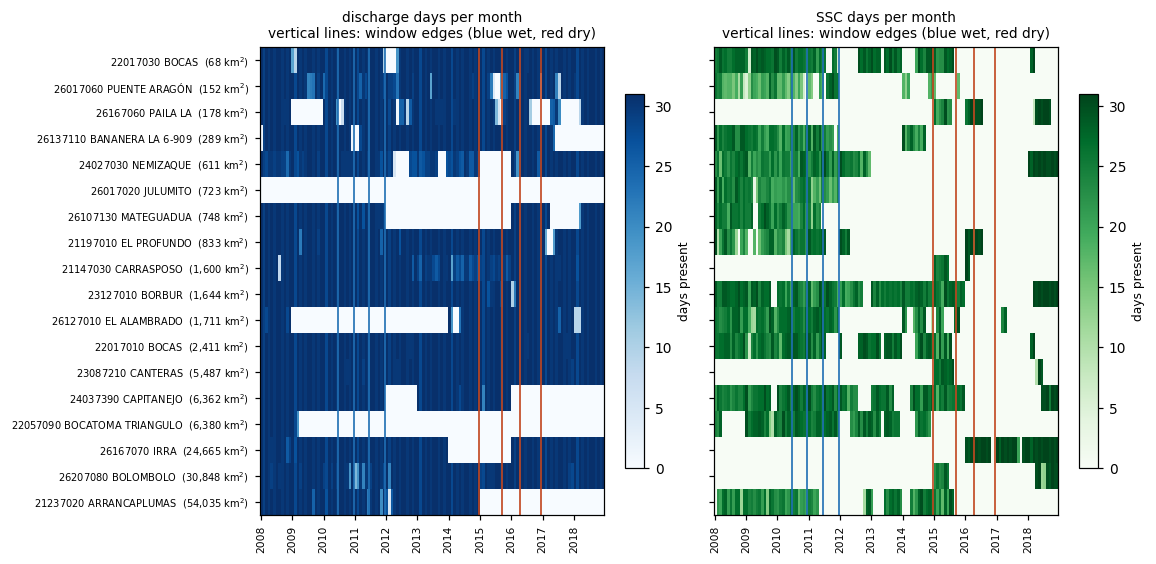

stations whose DISCHARGE record ends before the dry windows begin:
  26017020 JULUMITO               Q 1990-01-01 .. 2006-12-31  | SSC samples 2011  241, 2015-16    0 | Cauca trunk | 723 km2
  22057090 BOCATOMA TRIANGULO     Q 1990-01-01 .. 2009-03-19  | SSC samples 2011  321, 2015-16    0 | tributary | 6,380 km2
  21237020 ARRANCAPLUMAS          Q 1990-01-01 .. 2014-12-31  | SSC samples 2011   91, 2015-16  195 | Magdalena trunk | 54,035 km2


In [14]:
MONTHS = pd.period_range('2008-01', '2018-12', freq='M')


def month_matrix(df):
    d = df.copy()
    d['m'] = d.date.dt.to_period('M')
    t = (d.groupby(['code', 'm']).size().unstack(fill_value=0)
         .reindex(index=CODES, columns=MONTHS, fill_value=0))
    return t.values.astype(float)


MQ, MC = month_matrix(QD), month_matrix(SD)
xpos = {str(p): i for i, p in enumerate(MONTHS)}
ylab = [f'{c} {NM[c]}  ({AREA[c]:,.0f} km$^2$)' for c in CODES]

fig, ax = plt.subplots(1, 2, figsize=(10.6, 5.2), sharey=True)
for j, (M, t, cm) in enumerate([(MQ, 'discharge days per month', 'Blues'),
                                (MC, 'SSC days per month', 'Greens')]):
    im = ax[j].imshow(M, aspect='auto', cmap=cm, vmin=0, vmax=31, interpolation='nearest')
    for k, w in WIN.items():
        x0 = xpos[str(w['t0'].to_period('M'))] - 0.5
        x1 = xpos[str(w['t1'].to_period('M'))] + 0.5
        col = CW if w['phase'] == 'La Nina' else CD
        ax[j].plot([x0, x0], [-0.5, len(CODES) - 0.5], color=col, lw=1.1)
        ax[j].plot([x1, x1], [-0.5, len(CODES) - 0.5], color=col, lw=1.1)
    ax[j].set_xticks([i for i, p in enumerate(MONTHS) if p.month == 1])
    ax[j].set_xticklabels([str(p.year) for p in MONTHS if p.month == 1], rotation=90, fontsize=7)
    ax[j].set_title(t + '\nvertical lines: window edges (blue wet, red dry)')
    fig.colorbar(im, ax=ax[j], shrink=0.8).set_label('days present', fontsize=8)
ax[0].set_yticks(range(len(CODES)))
ax[0].set_yticklabels(ylab, fontsize=6.5)
show(fig)

span = QD.groupby('code').date.agg(['min', 'max'])
print('stations whose DISCHARGE record ends before the dry windows begin:')
for cc in CODES:
    if cc in span.index and span.loc[cc, 'max'] < pd.Timestamp('2015-01-01'):
        n11 = int(INV.loc[INV.code == cc, 'n_lanina_2011'].iloc[0])
        n15 = int(INV.loc[INV.code == cc, 'n_elnino_2015_16'].iloc[0])
        print(f'  {cc} {NM[cc]:22s} Q {span.loc[cc, "min"].date()} .. {span.loc[cc, "max"].date()}'
              f'  | SSC samples 2011 {n11:4d}, 2015-16 {n15:4d} | {BRANCH[cc]}'
              f' | {AREA[cc]:,.0f} km2')

**What is plotted.** Two heatmaps sharing a station axis. Rows are the 18 C2 stations ordered by
upstream area, smallest at the top, with `21237020` ARRANCAPLUMAS - the only Magdalena-trunk station,
54,035 km2 - at the bottom. Columns are the 132 months from January 2008 to December 2018. Left, blue:
days of discharge present in that month (0 to 31). Right, green: days of SSC present. Vertical lines
mark the four window edges, blue for wet, red for dry.

**What it shows.** Three stations lose their discharge record before the dry windows begin.
`21237020` ARRANCAPLUMAS ends **2014-12-31** while carrying **195 QC'd SSC samples inside 2015-16**;
`22057090` BOCATOMA TRIANGULO ends 2009-03-19 with 321 samples in 2011; `26017020` JULUMITO ends
2006-12-31 with 241 samples in 2011. In the right-hand panel those rows are green exactly where the
left panel is white.

**What it means.** The blocking resource is **discharge**, not concentration. At the only station on
the Magdalena trunk there are nearly two hundred El Nino sediment samples and not one day of
discharge to pair with them, so no trunk flux can be formed by either estimator - the sample-day mean
has nothing to multiply, and the rating curve has nothing to evaluate. Every number in section 5 is
therefore a **tributary and Cauca-branch** result. Section 9.1 states this again on its own, because
it is the finding a reader is most likely to carry away and most likely to overstate.

### 4.2 - The 72 station-windows, and an independent confirmation from the model bundle

The left panel prints the paired-day count $n_{iw}$ per station-window - the quantity gate 1 of
section 3.1 tests against 12 - and the right prints rating coverage
$\mathrm{cov}_{iw}=|D_{iw}|/D_w$ (dimensionless, 0 to 1) from the frozen table's `b_cov` column,
red below the 0.50 `partial-rating` threshold.

The cell then reads a **completely different artifact**: `model_inputs_v2/discharge.npz`, the
115-gauge observed-discharge bundle the hydrology was calibrated against, assembled by an unrelated
part of the pipeline. If the trunk blocker were an artefact of C2's own filtering it would not appear
there.

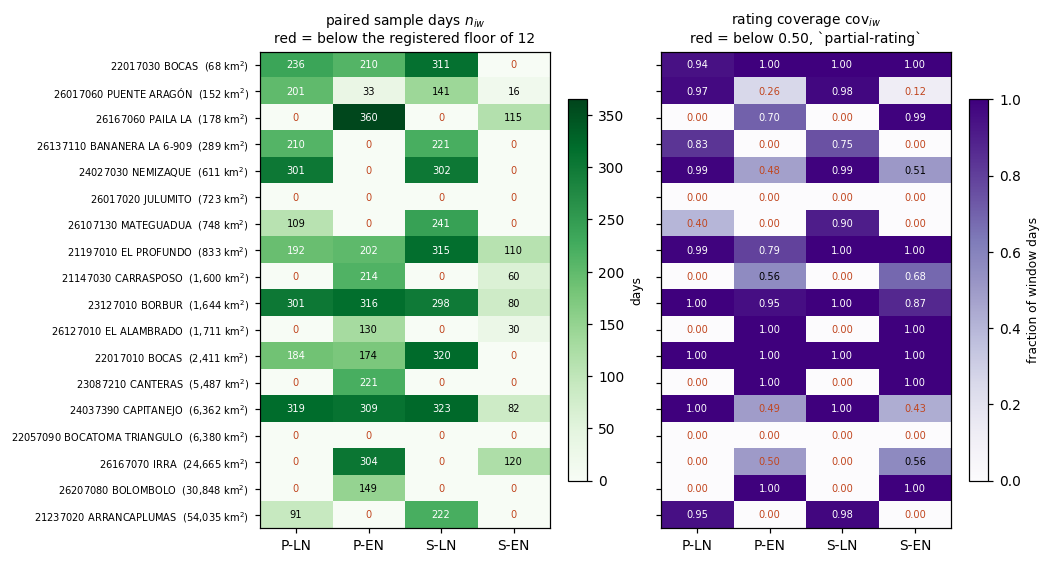

model_inputs_v2/discharge.npz: 115 gauges, dates 2008-01-01 .. 2018-12-31
  21237020 ARRANCAPLUMAS at column 10: 2499 valid days, LAST VALID 2014-12-31
  valid days inside P-EN (2015-01-01 .. 2016-12-31): 0
  => the trunk discharge gap is present in the model bundle too: it is a property of the IDEAM record, not of C2 filtering

cells: n < 12 -> 32 of 72 | cov < 0.50 -> 33 of 72 | cov == 0 -> 26 of 72
dry-window share of the cov < 0.50 cells: 16 of 33


In [15]:
WORD = ['P-LN', 'P-EN', 'S-LN', 'S-EN']
PIV_N = FX.pivot(index='code', columns='window', values='n_sample_days').reindex(CODES)[WORD]
PIV_C = FX.pivot(index='code', columns='window', values='b_cov').reindex(CODES)[WORD]

fig, ax = plt.subplots(1, 2, figsize=(9.6, 5.2), sharey=True)
im0 = ax[0].imshow(PIV_N.values, aspect='auto', cmap='Greens', vmin=0, vmax=365)
for i in range(len(CODES)):
    for j in range(4):
        v = PIV_N.values[i, j]
        ax[0].text(j, i, f'{int(v)}', ha='center', va='center', fontsize=6.5,
                   color='white' if v > 180 else ('#c1461f' if v < 12 else 'black'))
ax[0].set_title('paired sample days $n_{iw}$\nred = below the registered floor of 12')
fig.colorbar(im0, ax=ax[0], shrink=0.8).set_label('days', fontsize=8)

im1 = ax[1].imshow(PIV_C.values, aspect='auto', cmap='Purples', vmin=0, vmax=1)
for i in range(len(CODES)):
    for j in range(4):
        v = PIV_C.values[i, j]
        ax[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                   color='white' if v > 0.6 else ('#c1461f' if v < 0.5 else 'black'))
ax[1].set_title('rating coverage $\\mathrm{cov}_{iw}$\nred = below 0.50, `partial-rating`')
fig.colorbar(im1, ax=ax[1], shrink=0.8).set_label('fraction of window days', fontsize=8)
for a in ax:
    a.set_xticks(range(4))
    a.set_xticklabels(WORD)
ax[0].set_yticks(range(len(CODES)))
ax[0].set_yticklabels(ylab, fontsize=6.5)
show(fig)

Z = np.load(FILES['q_npz'], allow_pickle=True)
gcode = Z['gauge_code'].astype(np.int64)
i = int(np.where(gcode == 21237020)[0][0])
val = Z['q_valid'][:, i]
dts = Z['dates']
inwin = (dts >= np.datetime64('2015-01-01')) & (dts <= np.datetime64('2016-12-31'))
print(f'model_inputs_v2/discharge.npz: {len(gcode)} gauges, dates {dts[0]} .. {dts[-1]}')
print(f'  21237020 ARRANCAPLUMAS at column {i}: {int(val.sum())} valid days,'
      f' LAST VALID {dts[val][-1]}')
print(f'  valid days inside P-EN (2015-01-01 .. 2016-12-31): {int(val[inwin].sum())}')
print('  => the trunk discharge gap is present in the model bundle too: it is a property of the'
      ' IDEAM record, not of C2 filtering')
print(f'\ncells: n < 12 -> {int((PIV_N < 12).sum().sum())} of 72 |'
      f' cov < 0.50 -> {int((PIV_C < 0.50).sum().sum())} of 72 |'
      f' cov == 0 -> {int((PIV_C == 0).sum().sum())} of 72')
print('dry-window share of the cov < 0.50 cells:',
      f'{int((PIV_C[["P-EN", "S-EN"]] < 0.50).sum().sum())} of'
      f' {int((PIV_C < 0.50).sum().sum())}')

**What is plotted.** Two annotated heatmaps over the same 18 stations (rows, ordered by area) and
4 windows (columns). Left, green: paired sample days per station-window, printed in each cell, red
where below the registered floor of 12. Right, purple: rating coverage as a fraction of window days,
red where below 0.50.

**What it shows.** **32** of the 72 cells fall below the 12-day floor - 30 of them are recorded as
`n<12`, the other 2 belong to the flow-selective station and are blocked by the other gate first. 33
cells have coverage under 0.50, of which 26 are exactly zero, and 16 of the 33 sit in the two
dry-window columns. The zeros cluster
into whole rows - the three stations whose discharge record ended. The model bundle, built
independently, reports ARRANCAPLUMAS with 2,499 valid days ending **2014-12-31** and **zero** valid
days inside the primary El Nino window.

**What it means.** The gaps are structural rather than a filtering artefact: two unrelated pipelines
built from the same IDEAM source agree on where the discharge record stops, which removes the most
comfortable explanation (a bug in this stage) from the table. The concentration of missing coverage
in the dry columns also foreshadows section 9.6: the dry half of every ratio is the worse-supported
half, so the *denominator* of the headline contrast is where a reader should push hardest.

## 5 - The result: per-station wet:dry flux RATE ratios

The single deliverable of stage C2, for each station $i$, window pair, and estimator:

$$R(i)\;=\;\frac{\bar{Q}_s(i,\ \text{La Nina window})}{\bar{Q}_s(i,\ \text{El Nino window})}
\qquad[\text{dimensionless}]$$

both terms in t/day and both windows from the **same** pair (primary with primary, sensitivity with
sensitivity, never crossed). $R>1$ means the wet phase moved more sediment per day. Read from columns
`a_ratio`, `b_ratio` of `data/processed/c2/c2_rate_ratios.csv`, with the interval columns
`*_ratio_lo`, `*_ratio_hi`.

**How to read the intervals, and their registered conservatism.** The interval on a ratio is formed
as $[\,\text{lo}_{\text{wet}}/\text{hi}_{\text{dry}},\ \text{hi}_{\text{wet}}/\text{lo}_{\text{dry}}\,]$
- the worst case in each direction. That is deliberately wider than a proper paired bootstrap of the
ratio itself, which would resample both windows jointly. So an interval that **excludes 1** is a
strong statement, and an interval that includes 1 is weak evidence of nothing. Section 9.5 records
this as an open methodological item.

Stations are ordered by upstream drainage area, which for a nested network is a proxy for position
downstream. That ordering is presentational only: `docs/23` section 13.2 measured the per-gauge areas
as unreliable, so the axis label carries the caveat and no quantity is divided by an area.

stations supporting at least one ratio: 7
  22017030 BOCAS                       68 km2  tributary        ratios: 3  (p-a, p-b, s-b)
  26017060 PUENTE ARAGÓN              152 km2  Cauca trunk      ratios: 4  (p-a, p-b, s-a, s-b)
  24027030 NEMIZAQUE                  611 km2  tributary        ratios: 2  (p-b, s-b)
  21197010 EL PROFUNDO                833 km2  tributary        ratios: 4  (p-a, p-b, s-a, s-b)
  23127010 BORBUR                   1,644 km2  tributary        ratios: 4  (p-a, p-b, s-a, s-b)
  22017010 BOCAS                    2,411 km2  tributary        ratios: 3  (p-a, p-b, s-b)
  24037390 CAPITANEJO               6,362 km2  tributary        ratios: 4  (p-a, p-b, s-a, s-b)


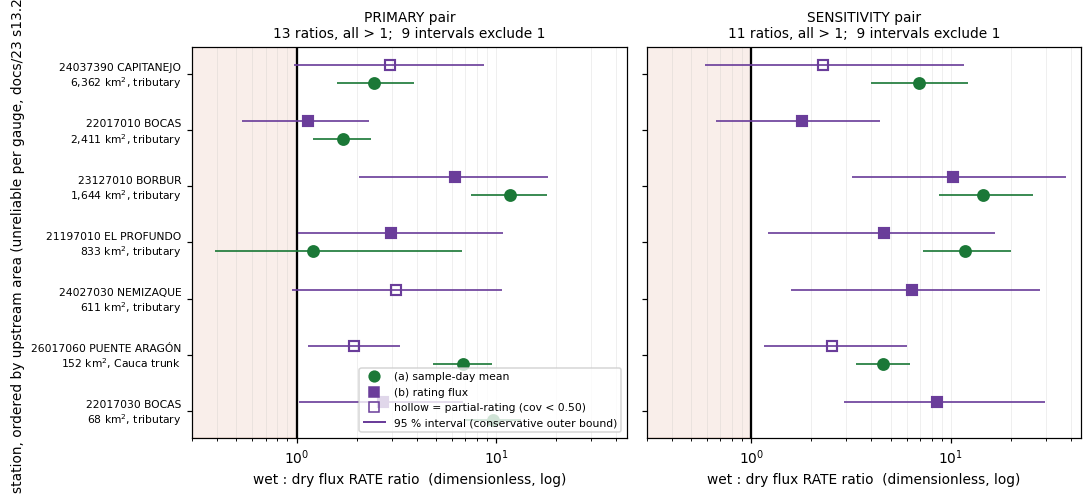

In [16]:
RAT['label2'] = [f'{r.label} ({r.area:,.0f} km$^2$)' for _, r in RAT.iterrows()]
stations = list(RAT.sort_values('area').code.unique())
ypos = {cc: i for i, cc in enumerate(stations)}
print('stations supporting at least one ratio:', len(stations))
for cc in stations:
    s = RAT[RAT.code == cc]
    print(f'  {cc} {NM[cc]:20s} {AREA[cc]:9,.0f} km2  {BRANCH[cc]:15s}'
          f'  ratios: {len(s)}  ({", ".join(sorted(s.pair.str[0] + "-" + s.est))})')

fig, ax = plt.subplots(1, 2, figsize=(10.0, 4.6), sharey=True)
for j, pr in enumerate(['primary', 'sensitivity']):
    a = ax[j]
    a.axvspan(0.2, 1.0, color=CD, alpha=0.09)
    a.axvline(1.0, color='k', lw=1.5)
    for est, off, col, mk in (('a', -0.16, CA, 'o'), ('b', 0.16, CB, 's')):
        s = RAT[(RAT.pair == pr) & (RAT.est == est)]
        for _, r in s.iterrows():
            y = ypos[r.code] + off
            a.plot([r.lo, r.hi], [y, y], color=col, lw=1.3, alpha=0.85, zorder=2)
            a.plot([r.ratio], [y], marker=mk, ms=7, zorder=3,
                   color='none' if r.partial else col, markeredgecolor=col,
                   markeredgewidth=1.4)
    a.set_yticks(range(len(stations)))
    a.set_xscale('log')
    a.set_xlim(0.3, 45)
    a.set_xlabel('wet : dry flux RATE ratio  (dimensionless, log)')
    n_ = (RAT.pair == pr).sum()
    ex = ((RAT.pair == pr) & (RAT.lo > 1)).sum()
    a.set_title(f'{pr.upper()} pair\n{n_} ratios, all > 1;  {ex} intervals exclude 1')
    a.grid(alpha=0.25, lw=0.5, axis='x', which='both')
ax[0].set_yticklabels([f'{cc} {NM[cc]}\n{AREA[cc]:,.0f} km$^2$, {BRANCH[cc]}'
                       for cc in stations], fontsize=7)
ax[0].set_ylabel('station, ordered by upstream area (unreliable per gauge, docs/23 s13.2)')
ax[0].legend(handles=[
    Line2D([], [], color=CA, marker='o', ls='', ms=7, label='(a) sample-day mean'),
    Line2D([], [], color=CB, marker='s', ls='', ms=7, label='(b) rating flux'),
    Line2D([], [], color=CB, marker='s', ls='', ms=7, markerfacecolor='none',
           label='hollow = partial-rating (cov < 0.50)'),
    Line2D([], [], color=CB, lw=1.3, label='95 % interval (conservative outer bound)')],
    loc='lower right', fontsize=7)
show(fig)

**What is plotted.** Two panels, primary pair left and sensitivity pair right, sharing a station
axis ordered by upstream area (smallest at the bottom, each labelled with its branch) and a
logarithmic axis of dimensionless
wet:dry **rate** ratios. Green circles are estimator (a), purple squares estimator (b), offset
vertically so both are visible; horizontal bars are the conservative 95 % intervals; a hollow square
means `partial-rating` (rating coverage below 0.50). The heavy vertical line is $R=1$ and the shaded
band left of it is "the dry phase moved more per day".

**What it shows.** Seven stations support at least one ratio, and **every ratio in both panels lies to
the right of 1** - no marker falls in the shaded band. In the primary pair 13 ratios span 1.14
(`22017010` BOCAS, estimator b) to 11.68 (`23127010` BORBUR, estimator a), with 9 of 13 intervals
excluding 1. In the sensitivity pair 11 ratios span 1.81 to 14.46, with 9 of 11 excluding 1. The two
BOCAS gauges - 68 km2 and 2,411 km2, on the same water body - give 9.68 and 1.70 on the same estimator
and window pair. Six of the seven stations are tributaries; the seventh, `26017060` PUENTE ARAGON, sits
on the **Cauca** trunk near its headwaters (152 km2), not on the Magdalena.

**What it means.** The direction of the ENSO sediment contrast is unanimous across stations,
estimators and window definitions: **more sediment per day in La Nina at every measurable station**.
The magnitude is not unanimous, and the 5.7-fold spread between two gauges on the same river is the
clearest warning against quoting a single basin number from this evidence. Only seven stations
survive - six tributaries and one upper-Cauca station - so this is a statement about the tributary
network, not about the Magdalena trunk.

### 5.1 - Fleet summary, and the count that carries the argument

Per window pair and estimator this cell reports the number of ratios $n$, their **median**, their
**geometric mean** $\exp\!\big(\frac{1}{n}\sum \ln R_i\big)$ (the right central measure for a ratio,
because it treats a factor of 2 up and a factor of 2 down symmetrically), the range, how many exceed
1, and how many intervals exclude 1. For estimator (b) a second row drops the `partial-rating`
station-windows: that subset is the **registered headline**. All quantities dimensionless; input
`c2_rate_ratios.csv` via the `RAT` frame built in section 2.2.

       pair est               subset  n  median  geomean    lo     hi  gt1  ci_excl_1
    primary   a                  all  6   4.620    3.964 1.212 11.680    6          5
    primary   b                  all  7   2.949    2.692 1.141  6.187    7          4
    primary   b cov>=0.50 (HEADLINE)  4   2.845    2.748 1.141  6.187    4          3
sensitivity   a                  all  4   9.320    8.558 4.577 14.460    4          4
sensitivity   b                  all  7   4.650    4.303 1.806 10.288    7          5
sensitivity   b cov>=0.50 (HEADLINE)  5   6.404    5.428 1.806 10.288    5          4

ALL ratios: 24; above 1: 24; intervals excluding 1: 18
partial-rating dropped: 19 ratios; above 1: 19; intervals excluding 1: 16
docs/34 s3.1 and s7 state "22 of 22" and "16 of 22" -- see section 9.5


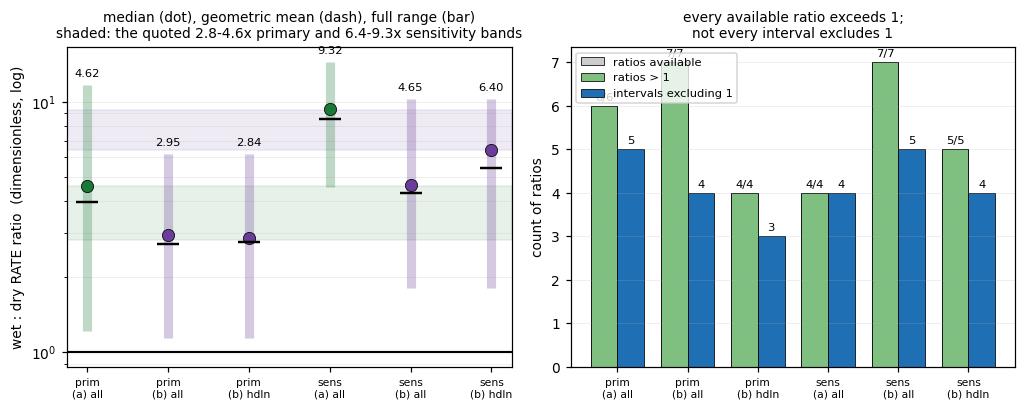

In [17]:
def gm(s):
    return float(np.exp(np.log(s).mean()))


rows = []
for pr in ['primary', 'sensitivity']:
    for est in ['a', 'b']:
        s = RAT[(RAT.pair == pr) & (RAT.est == est)]
        rows.append(dict(pair=pr, est=est, subset='all', n=len(s), median=s.ratio.median(),
                         geomean=gm(s.ratio), lo=s.ratio.min(), hi=s.ratio.max(),
                         gt1=int((s.ratio > 1).sum()), ci_excl_1=int((s.lo > 1).sum())))
        if est == 'b':
            f = s[~s.partial]
            rows.append(dict(pair=pr, est=est, subset='cov>=0.50 (HEADLINE)', n=len(f),
                             median=f.ratio.median(), geomean=gm(f.ratio), lo=f.ratio.min(),
                             hi=f.ratio.max(), gt1=int((f.ratio > 1).sum()),
                             ci_excl_1=int((f.lo > 1).sum())))
SUM = pd.DataFrame(rows)
print(SUM.round(3).to_string(index=False))
TOT = len(RAT)
NONP = (~RAT.partial).sum()
print(f'\nALL ratios: {TOT}; above 1: {int((RAT.ratio > 1).sum())}; intervals excluding 1:'
      f' {int((RAT.lo > 1).sum())}')
print(f'partial-rating dropped: {NONP} ratios; above 1: {int((RAT.loc[~RAT.partial, "ratio"] > 1).sum())};'
      f' intervals excluding 1: {int((RAT.loc[~RAT.partial, "lo"] > 1).sum())}')
print('docs/34 s3.1 and s7 state "22 of 22" and "16 of 22" -- see section 9.5')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.8))
lab = [f'{r.pair[:4]}\n({r.est}) {"hdln" if "HEAD" in r.subset else "all"}'
       for _, r in SUM.iterrows()]
xx = np.arange(len(SUM))
for k, (i, r) in enumerate(SUM.iterrows()):
    col = CA if r.est == 'a' else CB
    ax[0].plot([k, k], [r.lo, r.hi], color=col, lw=6, alpha=0.28,
               solid_capstyle='butt')
    ax[0].plot(k, r['median'], marker='o', ms=8, color=col, markeredgecolor='k',
               markeredgewidth=0.5)
    ax[0].plot(k, r.geomean, marker='_', ms=14, color='k', markeredgewidth=1.6)
    ax[0].text(k, r.hi * 1.08, f'{r["median"]:.2f}', ha='center', fontsize=7.5)
ax[0].axhline(1.0, color='k', lw=1.4)
ax[0].axhspan(2.8, 4.6, color=CA, alpha=0.10)
ax[0].axhspan(6.4, 9.3, color=CB, alpha=0.10)
ax[0].set_xticks(xx)
ax[0].set_xticklabels(lab, fontsize=7)
ax[0].set_yscale('log')
ax[0].set_ylabel('wet : dry RATE ratio  (dimensionless, log)')
ax[0].set_title('median (dot), geometric mean (dash), full range (bar)\n'
                'shaded: the quoted 2.8-4.6x primary and 6.4-9.3x sensitivity bands')
ax[0].grid(alpha=0.25, lw=0.5, axis='y', which='both')

w = 0.38
ax[1].bar(xx - w / 2, SUM.n, w, color='#cccccc', edgecolor='k', linewidth=0.5,
          label='ratios available')
ax[1].bar(xx - w / 2, SUM.gt1, w, color='#7fbf7f', edgecolor='k', linewidth=0.5,
          label='ratios > 1')
ax[1].bar(xx + w / 2, SUM.ci_excl_1, w, color=CW, edgecolor='k', linewidth=0.5,
          label='intervals excluding 1')
for k, (i, r) in enumerate(SUM.iterrows()):
    ax[1].text(k - w / 2, r.n + 0.12, f'{r.gt1}/{r.n}', ha='center', fontsize=7.5)
    ax[1].text(k + w / 2, r.ci_excl_1 + 0.12, f'{r.ci_excl_1}', ha='center', fontsize=7.5)
ax[1].set_xticks(xx)
ax[1].set_xticklabels(lab, fontsize=7)
ax[1].set_ylabel('count of ratios')
ax[1].set_title('every available ratio exceeds 1;\nnot every interval excludes 1')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, axis='y')
show(fig)

**What is plotted.** Left: for each window pair and estimator (and, for the rating estimator, the
headline subset with coverage at least 0.50), the median ratio as a dot, the geometric mean as a black
dash, and the full range as a translucent bar, on a logarithmic dimensionless axis, with $R=1$ heavy
and the two bands this project quotes shaded. Right: counts - grey is the number of ratios available,
green the number exceeding 1, blue the number whose interval excludes 1, annotated.

**What it shows.** Medians: primary **4.62** on estimator (a) and **2.85** on the (b) headline subset;
sensitivity **9.32** on (a) and **6.40** on the (b) headline subset. Geometric means are systematically
below the medians (3.96, 2.75, 8.56, 5.43), meaning the distributions are right-skewed. Counts: **24
of 24** available ratios exceed 1, with **18** of 24 intervals excluding 1; restricting to
coverage-complete rating windows leaves 19 ratios of which **16** exclude 1.

**What it means.** The headline of stage C2, at the precision the data supports: across the tributary
network, observed suspended-sediment flux **rates** were about **3 to 9 times higher** in La Nina than
in El Nino, with the primary window pair at the low end of that range and the ONI-peak sensitivity
pair at the high end. The direction has no counter-example in 24 attempts. Quoting a single number
would be false precision, because the window definition alone moves the median by a factor of about
two (section 6). Note also that the count is **24, not the "22" stated in `docs/34`** - the discrepancy
is reported in section 9.5 and does not change the direction, the range, or any station's value.

### 5.2 - The registered single-point test: one uncorroborated sample nearly decided a station

Stage C1 found an uncorroborated **15,180 mg/L** concentration at `21197010` EL PROFUNDO on
**2016-06-04**, inside the primary El Nino window. C1 deleted nothing, so `docs/34` section 1.6
registered in advance what to do: keep the point in the primary result, recompute estimator (a)
without it, and if the window mean moves by more than 25 %, label the station-window
`single-point dominated` and let the rating estimator take precedence in every downstream statement.

The leverage is

$$L=100\times\frac{\bar{Q}_s^{(a)}\big|_{\text{with}}-\bar{Q}_s^{(a)}\big|_{\text{without}}}
{\bar{Q}_s^{(a)}\big|_{\text{without}}}\qquad[\%]$$

read from columns `a_mean_tday`, `a_mean_tday_no_extreme`, `a_extreme_leverage_pct` of the frozen
flux table and recomputed here from the raw records to confirm.

21197010 EL PROFUNDO P-EN: n = 202 paired days
  extreme sample: 2016-06-04  C = 15,180 mg/L, Q = 10.61 m3/s  ->  Qs = 13,911 t/day (61.2 % of the whole window sum)
  mean with    112.4719 t/day   frozen 112.4719
  mean without 43.8213 t/day   frozen 43.8213
  leverage recomputed 156.66 %   frozen 156.66 %   registered trigger 25 %  -> FIRES
  consequence: primary ratio for this station is the rating value 2.99 (b), not 1.21 (a)


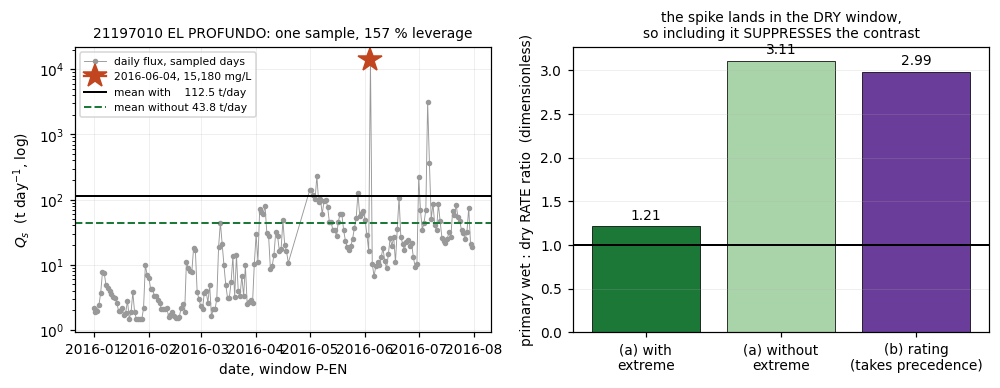

In [18]:
c, wn = 21197010, 'P-EN'
w = WIN[wn]
g = PAIR[(PAIR.code == c) & PAIR.date.between(w['t0'], w['t1'])].sort_values('date')
ext = g.loc[g.ssc_mean_mg_l.idxmax()]
without = g.drop(index=ext.name)
lev = 100 * (g.qs_tday.mean() - without.qs_tday.mean()) / without.qs_tday.mean()
fr = FX[(FX.code == c) & (FX.window == wn)].iloc[0]
print(f'{c} {NM[c]} {wn}: n = {len(g)} paired days')
print(f'  extreme sample: {ext.date.date()}  C = {ext.ssc_mean_mg_l:,.0f} mg/L,'
      f' Q = {ext.q_m3s:.2f} m3/s  ->  Qs = {ext.qs_tday:,.0f} t/day'
      f' ({100 * ext.qs_tday / g.qs_tday.sum():.1f} % of the whole window sum)')
print(f'  mean with    {g.qs_tday.mean():.4f} t/day   frozen {fr.a_mean_tday:.4f}')
print(f'  mean without {without.qs_tday.mean():.4f} t/day   frozen'
      f' {fr.a_mean_tday_no_extreme:.4f}')
print(f'  leverage recomputed {lev:.2f} %   frozen {fr.a_extreme_leverage_pct:.2f} %'
      f'   registered trigger 25 %  -> FIRES')
print(f'  consequence: primary ratio for this station is the rating value'
      f' {RAT[(RAT.code == c) & (RAT.pair == "primary") & (RAT.est == "b")].ratio.iloc[0]:.2f} (b),'
      f' not {RAT[(RAT.code == c) & (RAT.pair == "primary") & (RAT.est == "a")].ratio.iloc[0]:.2f} (a)')

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.6))
ax[0].semilogy(g.date, g.qs_tday, color='#999999', lw=0.6, marker='o', ms=2.6,
               label='daily flux, sampled days')
ax[0].semilogy([ext.date], [ext.qs_tday], marker='*', ms=16, color=CD,
               label=f'2016-06-04, {ext.ssc_mean_mg_l:,.0f} mg/L')
ax[0].axhline(g.qs_tday.mean(), color='k', lw=1.3,
              label=f'mean with    {g.qs_tday.mean():.1f} t/day')
ax[0].axhline(without.qs_tday.mean(), color=CA, lw=1.3, ls='--',
              label=f'mean without {without.qs_tday.mean():.1f} t/day')
ax[0].set_ylabel('$Q_s$  (t day$^{-1}$, log)')
ax[0].set_xlabel('date, window P-EN')
ax[0].set_title(f'{c} {NM[c]}: one sample, {lev:.0f} % leverage')
ax[0].legend(loc='upper left', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5)

bars = ['(a) with\nextreme', '(a) without\nextreme', '(b) rating\n(takes precedence)']
vals = [RAT[(RAT.code == c) & (RAT.pair == 'primary') & (RAT.est == 'a')].ratio.iloc[0],
        None, RAT[(RAT.code == c) & (RAT.pair == 'primary') & (RAT.est == 'b')].ratio.iloc[0]]
r_ln = FX[(FX.code == c) & (FX.window == 'P-LN')].a_mean_tday.iloc[0]
vals[1] = r_ln / without.qs_tday.mean()
ax[1].bar(bars, vals, color=[CA, '#a9d3a9', CB], edgecolor='k', linewidth=0.5)
ax[1].axhline(1.0, color='k', lw=1.3)
for i, v in enumerate(vals):
    ax[1].text(i, v + 0.08, f'{v:.2f}', ha='center', fontsize=9)
ax[1].set_ylabel('primary wet : dry RATE ratio  (dimensionless)')
ax[1].set_title('the spike lands in the DRY window,\nso including it SUPPRESSES the contrast')
ax[1].grid(alpha=0.25, lw=0.5, axis='y')
show(fig)

**What is plotted.** Left: EL PROFUNDO's 202 paired daily fluxes inside the primary El Nino window
(t/day, log), the 2016-06-04 sample as a red star, and the window mean with (black) and without
(dashed green) that single day. Right: this station's primary rate ratio computed three ways -
estimator (a) including the extreme, estimator (a) excluding it, and the rating estimator that the
registration makes authoritative - with the $R=1$ line.

**What it shows.** The single 15,180 mg/L sample contributes 61 % of the entire window's sampled flux
and moves the window mean from 43.82 to 112.47 t/day, a leverage of **+156.7 %**, far above the
registered 25 % trigger. Recomputation from the raw records matches the frozen table to two decimals.
The station's ratio is 1.21 with the point, 3.11 without it, and 2.99 by the rating estimator.

**What it means.** One uncorroborated sample was in a position to decide a station's entire ENSO
verdict, and the pre-registration is what stopped it: because the rule was written before the number
was seen, the resolution is procedural rather than a judgement call. Note the direction carefully -
the spike lands in the **dry** window, so including it *suppresses* the apparent contrast. The
sensitivity test therefore works against the study's headline, which is the only kind of sensitivity
test worth much.

### 5.3 - Absolute levels, as context only

The comparability rule permits window totals as context provided they carry their day count and are
never divided. This cell prints, for the stations with a wet-window estimator (a) value, the mean flux
in t/day and the implied window total

$$T = \bar{Q}_s\times D_w \qquad [\mathrm{t}]$$

with $D_w$ printed alongside. The figure shows only **rates**, because a bar chart of totals across
unequal windows is exactly the comparison section 2 forbids.

primary windows, estimator (a) - RATES compared, totals context only:
    code             label    area window  window_days  n_sample_days  mean_t_per_day  window_total_t
22017030             BOCAS    68.0   P-EN          731            210            12.9          9408.1
22017030             BOCAS    68.0   P-LN          365            236           124.6         45466.5
26017060     PUENTE ARAGÓN   151.8   P-EN          731             33             1.1           822.8
26017060     PUENTE ARAGÓN   151.8   P-LN          365            201             7.6          2789.1
26167060          PAILA LA   178.5   P-EN          731            360             5.1          3732.2
26137110 BANANERA LA 6-909   289.0   P-LN          365            210            22.8          8323.2
24027030         NEMIZAQUE   610.6   P-LN          365            301           119.3         43535.2
26107130        MATEGUADUA   748.3   P-LN          365            109          1867.0        681465.5
21197010    

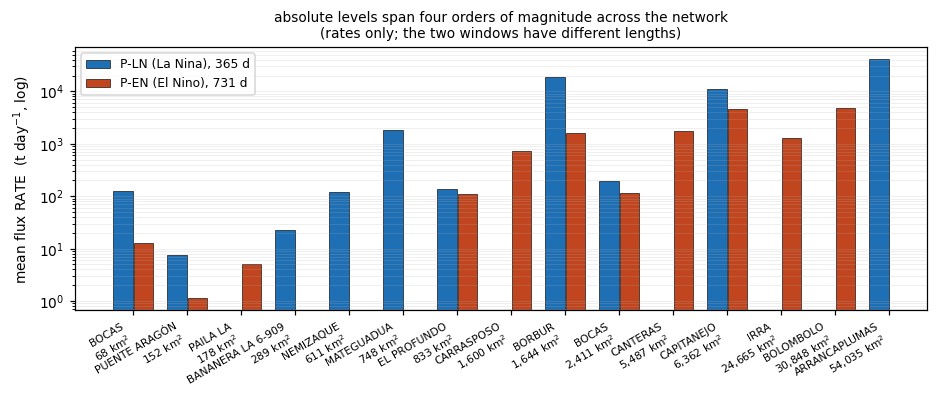


wet-window (P-LN) rate range: 7.6 to 41,272 t/day = a factor of 5,401


In [19]:
LEV = FX[(FX.window.isin(['P-LN', 'P-EN'])) & (FX.a_status == 'ok')].copy()
LEV['label'] = LEV.code.map(NM)
LEV['area'] = LEV.code.map(AREA)
LEV['total_t'] = LEV.a_mean_tday * LEV.window_days
print('primary windows, estimator (a) - RATES compared, totals context only:')
print(LEV.sort_values(['area', 'window'])[['code', 'label', 'area', 'window', 'window_days',
                                           'n_sample_days', 'a_mean_tday', 'total_t']]
      .rename(columns={'a_mean_tday': 'mean_t_per_day', 'total_t': 'window_total_t'})
      .round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.6, 3.8))
sts = list(LEV.sort_values('area').code.unique())
xx = np.arange(len(sts))
for wn, off, col in (('P-LN', -0.19, CW), ('P-EN', 0.19, CD)):
    v = [LEV[(LEV.code == cc) & (LEV.window == wn)].a_mean_tday.values for cc in sts]
    vv = [x[0] if len(x) else np.nan for x in v]
    ax.bar(xx + off, vv, 0.36, color=col, edgecolor='k', linewidth=0.4,
           label=f'{wn} ({WIN[wn]["phase"]}), {WIN[wn]["days"]} d')
ax.set_yscale('log')
ax.set_xticks(xx)
ax.set_xticklabels([f'{NM[cc]}\n{AREA[cc]:,.0f} km$^2$' for cc in sts], fontsize=7, rotation=30,
                   ha='right')
ax.set_ylabel('mean flux RATE  (t day$^{-1}$, log)')
ax.set_title('absolute levels span four orders of magnitude across the network\n'
             '(rates only; the two windows have different lengths)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.25, lw=0.5, axis='y', which='both')
show(fig)
print(f'\nwet-window (P-LN) rate range: {LEV[LEV.window == "P-LN"].a_mean_tday.min():,.1f}'
      f' to {LEV[LEV.window == "P-LN"].a_mean_tday.max():,.0f} t/day'
      f' = a factor of {LEV[LEV.window == "P-LN"].a_mean_tday.max() / LEV[LEV.window == "P-LN"].a_mean_tday.min():,.0f}')

**What is plotted.** Mean flux **rate** in t/day on a logarithmic axis, one pair of bars per station
(blue = primary La Nina, 365 days; red = primary El Nino, 731 days), stations ordered by upstream area
with the area printed under each name. Only stations with an admissible estimator (a) in that window
appear.

**What it shows.** Wet-window rates run from **7.6 t/day** at `26017060` PUENTE ARAGON (152 km2) to
**41,272 t/day** at `21237020` ARRANCAPLUMAS (54,035 km2), a factor of 5,401 across the network. The
blue bar exceeds the red at every station where both exist. The printed table gives the window totals
with their day counts - ARRANCAPLUMAS 41,272 t/day over 365 days is 15.1 Mt of sediment in the 2011 La
Nina year.

**What it means.** Absolute flux is dominated by catchment size, which is why the deliverable is a
within-station ratio: dividing a station by itself removes the size, the rating bias and the sub-daily
sampling error that would otherwise swamp an ENSO signal. The totals are printed to give a reader a
sense of scale - 15 Mt in one year at one mid-basin station - and are printed once, with their day
counts, and never divided.

## 6 - Why there are two window pairs: an advisor question, bracketed rather than asserted

When does an ENSO phase begin and end? There is no unique answer. Calendar-year windows are simple
and match every earlier phase of this project; ONI-peak windows isolate the strongest part of the
anomaly but are shorter and asymmetric. The choice changes the answer, so it matters who decides it.

The project asked. **The advisor declined to adjudicate the window definition** (recorded in
`docs/open_questions.md` and `docs/07_enso_years.md`). Two responses were available:

- **Rejected:** pick one definition, assert it, and report a single number. This hides a real
  uncertainty inside a result and invites exactly the criticism the project could not answer -
  *why that window?*
- **Adopted:** register both, before computing, and report both everywhere. If the pairs agree in
  sign, the sign is robust to the definition. If they disagree in magnitude, the disagreement **is**
  the finding and is quoted as a range.

This is the same discipline as the estimator pair: where a defensible choice cannot be made on
evidence, make both and let the spread be visible. The cell below measures how much the choice is
worth.

stations with the SAME estimator in BOTH window pairs: 11
    code         label est  primary  sensitivity   fac
21197010   EL PROFUNDO   a    1.212       11.736 9.684
21197010   EL PROFUNDO   b    2.985        4.650 1.558
22017010         BOCAS   b    1.141        1.806 1.582
22017030         BOCAS   b    2.704        8.520 3.151
23127010        BORBUR   a   11.680       14.460 1.238
23127010        BORBUR   b    6.187       10.288 1.663
24027030     NEMIZAQUE   b    3.145        6.404 2.036
24037390    CAPITANEJO   a    2.451        6.905 2.817
24037390    CAPITANEJO   b    2.949        2.281 0.774
26017060 PUENTE ARAGÓN   a    6.789        4.577 0.674
26017060 PUENTE ARAGÓN   b    1.938        2.539 1.311

sensitivity / primary : median 1.582, range 0.674 - 9.684
sign agreement: 11 of 11
median ratio, primary 2.949  vs sensitivity 6.404  = factor 2.172


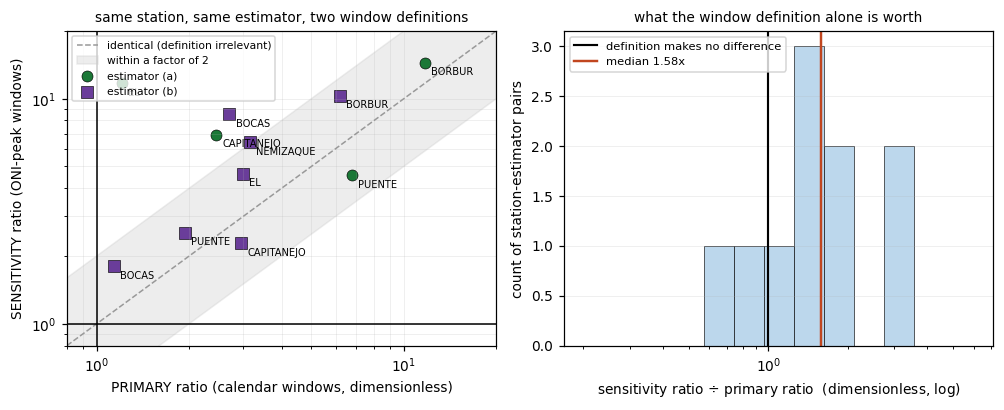

In [20]:
piv = RAT.pivot_table(index=['code', 'est'], columns='pair', values='ratio').dropna()
piv = piv.reset_index()
piv['label'] = piv.code.map(NM)
piv['fac'] = piv.sensitivity / piv.primary
print('stations with the SAME estimator in BOTH window pairs:', len(piv))
print(piv[['code', 'label', 'est', 'primary', 'sensitivity', 'fac']].round(3).to_string(index=False))
print(f'\nsensitivity / primary : median {piv.fac.median():.3f},'
      f' range {piv.fac.min():.3f} - {piv.fac.max():.3f}')
print(f'sign agreement: {int(((piv.primary > 1) == (piv.sensitivity > 1)).sum())} of {len(piv)}')
print(f'median ratio, primary {RAT[RAT.pair == "primary"].ratio.median():.3f}'
      f'  vs sensitivity {RAT[RAT.pair == "sensitivity"].ratio.median():.3f}'
      f'  = factor {RAT[RAT.pair == "sensitivity"].ratio.median() / RAT[RAT.pair == "primary"].ratio.median():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.8))
lim = [0.8, 20]
ax[0].plot(lim, lim, color='#999999', ls='--', lw=1.0, label='identical (definition irrelevant)')
ax[0].fill_between(lim, [x / 2 for x in lim], [x * 2 for x in lim], color='#cccccc', alpha=0.35,
                   label='within a factor of 2')
for est, col, mk in (('a', CA, 'o'), ('b', CB, 's')):
    s = piv[piv.est == est]
    ax[0].scatter(s.primary, s.sensitivity, s=52, color=col, marker=mk, edgecolor='k',
                  linewidth=0.4, label=f'estimator ({est})')
    for _, r in s.iterrows():
        ax[0].annotate(r.label.split()[0], (r.primary, r.sensitivity), fontsize=6.5,
                       xytext=(4, -8), textcoords='offset points')
ax[0].axhline(1.0, color='k', lw=1.0)
ax[0].axvline(1.0, color='k', lw=1.0)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(lim)
ax[0].set_ylim(lim)
ax[0].set_xlabel('PRIMARY ratio (calendar windows, dimensionless)')
ax[0].set_ylabel('SENSITIVITY ratio (ONI-peak windows)')
ax[0].set_title('same station, same estimator, two window definitions')
ax[0].legend(loc='upper left', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5, which='both')

ax[1].hist(piv.fac, bins=np.logspace(np.log10(0.2), np.log10(6), 14), color='#bcd7ec',
           edgecolor='k', linewidth=0.4)
ax[1].axvline(1.0, color='k', lw=1.4, label='definition makes no difference')
ax[1].axvline(piv.fac.median(), color=CD, lw=1.6,
              label=f'median {piv.fac.median():.2f}x')
ax[1].set_xscale('log')
ax[1].set_xlabel('sensitivity ratio $\\div$ primary ratio  (dimensionless, log)')
ax[1].set_ylabel('count of station-estimator pairs')
ax[1].set_title('what the window definition alone is worth')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)

**What is plotted.** Left, log-log: the sensitivity-pair ratio (y) against the primary-pair ratio (x)
for every station-estimator combination that has both, green circles for estimator (a) and purple
squares for (b), labelled with the station name, with a dashed identity line, a grey band marking
agreement within a factor of two, and lines at $R=1$ on both axes. Right: the histogram of the
per-station ratio-of-ratios (sensitivity divided by primary) on a log axis, with 1.0 marked and the
median in red.

**What it shows.** Eleven station-estimator combinations have both definitions and **all eleven agree
in sign** - every point lies in the upper-right quadrant. The magnitudes do not: the ratio-of-ratios
runs from **0.674 to 9.684** with a median of **1.582**, and the fleet medians are **2.949** (primary)
against **6.404** (sensitivity), a factor of 2.17. EL PROFUNDO is the extreme case, 1.21 primary
against 11.74 sensitivity on estimator (a) - the same station, the same records, a 9.7-fold difference
from the window definition alone. Two of the eleven go the other way (0.674 at PUENTE ARAGON (a),
0.774 at CAPITANEJO (b)), so the inflation is not universal either.

**What it means.** The window definition is worth roughly a factor of two on the headline and, at one
station, nearly a factor of ten. That is why stage C2 refuses to quote a single number and reports
"about 3 to 9 times". It is also a concrete answer to the question the advisor left open: the sign of
the ENSO sediment contrast does not depend on the definition, so the qualitative result is safe, while
any *quantitative* target handed to the model must be a range. A single-number target would have been
an artefact of an arbitrary choice.

## 7 - Consistency checks, each with a rule written before the numbers

Three checks were registered in `docs/34` section 1.7-1.8, each with the action to take if it fails.
They are not decoration: check 7.1 turned a disagreement into a named defect of the previous stage.

### 7.1 - Estimator agreement, and the defect it exposes

**Registered rule.** Where (a) and (b) are both admissible, they **agree** if their 95 % intervals
overlap. A disagreement - disjoint intervals - is declared a **missed C1 flag**, and the doc must then
name the specific candidate mechanism rather than reporting two numbers side by side without comment.

To test the leading candidate mechanism this cell recomputes, from the raw records, the sampling
diagnostic C1's one-sided rule could not use. For station $i$ and window $w$:

$$P_{iw}=\operatorname{median}_{t\in S_{iw}}\ \hat{F}_{iw}\big(Q(i,t)\big),\qquad
\hat{F}_{iw}(q)=\frac{\#\{t'\in W: Q(i,t')<q\}+\tfrac12\#\{t'\in W: Q(i,t')=q\}}{|W|}$$

where $W$ is **all** days of that window with a discharge value, so $\hat{F}$ is the empirical
cumulative distribution of *within-window* flow and $P_{iw}$ (dimensionless, 0 to 1) is the median
flow percentile of the sampled days. Unbiased sampling gives $P\approx 0.5$. Alongside it, the simpler
flow ratio

$$\rho_{iw}=\frac{\overline{Q}\ \text{on sampled days}}{\overline{Q}\ \text{on all window days}}
\qquad[\text{dimensionless}]$$

Inputs: `QD`, `SD` (raw); agreement verdicts and both estimators from `c2_estimator_agreement.csv`.

station-windows admitting both estimators : 38
median b/a                                : 1.0681
DISJOINT 95 % intervals                   : 8 = 21 %   (registered failure line: more than half)
median P among AGREEING station-windows    : 0.4859
corr(ln(b/a), ln rho)                      : -0.6483
corr(ln(b/a), P)                           : -0.4597

    code                 name window          a          b  ratio_b_over_a      P    rho  b_cov
21147030    CARRASPOSO  - AUT   S-EN     7.2291    89.6926         12.4071 0.1602 0.1965 0.6808
26017060  PUENTE ARAGÓN - AUT   P-EN     1.1256     4.2040          3.7351 0.2696 0.4120 0.2572
26167060             PAILA LA   P-EN     5.1056    15.1489          2.9671 0.5883 1.0934 0.7018
21197010          EL PROFUNDO   S-EN     9.4517    26.4745          2.8010 0.3239 0.7146 1.0000
23127010        BORBUR  - AUT   P-EN  1626.8320  3563.7429          2.1906 0.4375 0.8461 0.9521
21237020 ARRANCAPLUMAS  - AUT   S-LN 36489.2402 65387.7570          1.

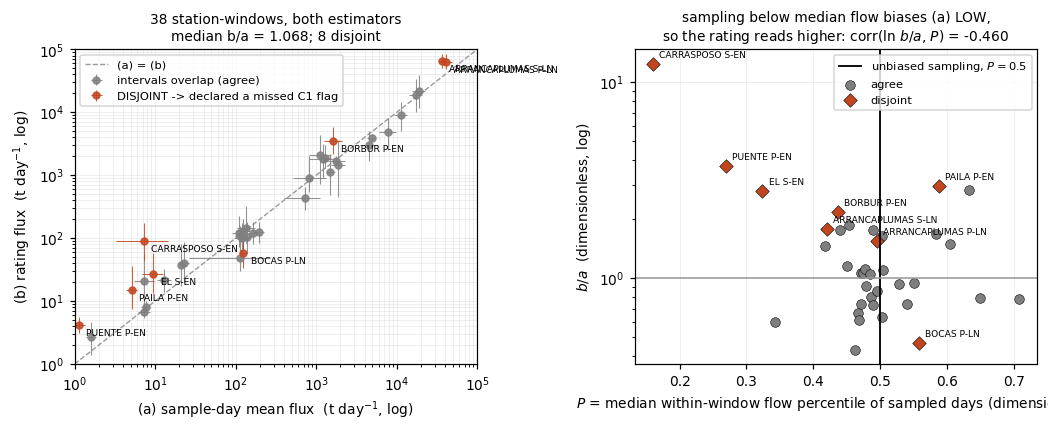

In [21]:
rows = []
for wn, w in WIN.items():
    qw = QD[QD.date.between(w['t0'], w['t1'])]
    sw = SD[SD.date.between(w['t0'], w['t1'])]
    for cc, g in qw.groupby('code'):
        smp = g.merge(sw, on=['code', 'date'])
        if len(smp) == 0:
            continue
        pct = [float((g.q_m3s < v).mean() + 0.5 * (g.q_m3s == v).mean()) for v in smp.q_m3s]
        rows.append(dict(code=cc, window=wn, n=len(smp), P=float(np.median(pct)),
                         rho=float(smp.q_m3s.mean() / g.q_m3s.mean())))
SEL = pd.DataFrame(rows)
AGX = AG.merge(SEL, on=['code', 'window'], how='left')
AGX['lnba'] = np.log(AGX.ratio_b_over_a)
dis = AGX[~AGX.agree].sort_values('ratio_b_over_a', ascending=False)
print(f'station-windows admitting both estimators : {len(AGX)}')
print(f'median b/a                                : {AGX.ratio_b_over_a.median():.4f}')
print(f'DISJOINT 95 % intervals                   : {len(dis)}'
      f' = {100 * len(dis) / len(AGX):.0f} %   (registered failure line: more than half)')
print(f'median P among AGREEING station-windows    : {AGX[AGX.agree].P.median():.4f}')
print(f'corr(ln(b/a), ln rho)                      : {np.corrcoef(AGX.lnba, np.log(AGX.rho))[0, 1]:.4f}')
print(f'corr(ln(b/a), P)                           : {np.corrcoef(AGX.lnba, AGX.P)[0, 1]:.4f}')
print()
print(dis[['code', 'name', 'window', 'a', 'b', 'ratio_b_over_a', 'P', 'rho', 'b_cov']]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(9.6, 4.0))
lim = [1e0, 1e5]
ax[0].plot(lim, lim, color='#999999', ls='--', lw=0.9, label='(a) = (b)')
for agree, col, lb in ((True, '#7f7f7f', 'intervals overlap (agree)'),
                       (False, CD, 'DISJOINT -> declared a missed C1 flag')):
    s = AGX[AGX.agree == agree]
    ax[0].errorbar(s.a, s.b, xerr=[s.a - s.a_lo, s.a_hi - s.a], yerr=[s.b - s.b_lo, s.b_hi - s.b],
                   fmt='o', ms=4.5, lw=0.7, color=col, ecolor=col, alpha=0.85, label=lb)
for _, r in dis.iterrows():
    ax[0].annotate(f'{NM[r.code].split()[0]} {r.window}', (r.a, r.b), fontsize=6,
                   xytext=(5, -7), textcoords='offset points')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(lim)
ax[0].set_ylim(lim)
ax[0].set_xlabel('(a) sample-day mean flux  (t day$^{-1}$, log)')
ax[0].set_ylabel('(b) rating flux  (t day$^{-1}$, log)')
ax[0].set_title(f'{len(AGX)} station-windows, both estimators\n'
                f'median b/a = {AGX.ratio_b_over_a.median():.3f}; {len(dis)} disjoint')
ax[0].legend(loc='upper left', fontsize=7.5)
ax[0].grid(alpha=0.25, lw=0.5, which='both')

ax[1].axvline(0.5, color='k', lw=1.2, label='unbiased sampling, $P=0.5$')
ax[1].axhline(1.0, color='#999999', lw=1.0)
for agree, col, mk in ((True, '#7f7f7f', 'o'), (False, CD, 'D')):
    s = AGX[AGX.agree == agree]
    ax[1].scatter(s.P, s.ratio_b_over_a, s=40, color=col, marker=mk, edgecolor='k',
                  linewidth=0.35, label='agree' if agree else 'disjoint')
for _, r in dis.iterrows():
    ax[1].annotate(f'{NM[r.code].split()[0]} {r.window}', (r.P, r.ratio_b_over_a), fontsize=6,
                   xytext=(4, 4), textcoords='offset points')
ax[1].set_yscale('log')
ax[1].set_xlabel('$P$ = median within-window flow percentile of sampled days (dimensionless)')
ax[1].set_ylabel('$b/a$  (dimensionless, log)')
ax[1].set_title('sampling below median flow biases (a) LOW,\n'
                f'so the rating reads higher: corr(ln $b/a$, $P$) = '
                f'{np.corrcoef(AGX.lnba, AGX.P)[0, 1]:.3f}')
ax[1].legend(loc='upper right', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)

**What is plotted.** Left, log-log: the rating flux (b) against the sample-day mean (a) in t/day,
one point per station-window with both estimators, error bars showing both 95 % intervals, grey where
the intervals overlap and red where they are disjoint, with a dashed 1:1 line and the disjoint cases
labelled. Right: the ratio $b/a$ (log) against the median within-window flow percentile of the
sampled days $P$, with the unbiased value $P=0.5$ marked and $b/a=1$ in grey.

**What it shows.** 38 station-windows admit both estimators; the median $b/a$ is **1.068**, so at the
fleet median the two estimators agree on level to 7 %. **8 of 38 (21 %)** have disjoint intervals -
under the registered failure line of "more than half", so this check does not fail C2. The right panel
shows why they disagree: the correlation between $\ln(b/a)$ and $P$ is **-0.460**, and against the
flow ratio $\rho$ it is **-0.648**. The disagreeing cases are concentrated at low $P$ - CARRASPOSO
S-EN at $P=0.160$ with $b/a=12.4$, PUENTE ARAGON P-EN at 0.270 with 3.74, EL PROFUNDO S-EN at 0.324
with 2.80 - while the agreeing station-windows have a median $P$ of **0.486**, essentially unbiased.

**What it means.** The disagreements are not random: they are the signature of **sampling below median
flow**, which biases the sample-day mean low while the rating, which uses every day, reads correctly
higher. That is a defect of stage C1's selectivity gate, which can only fire when sampling is biased
*high* - section 9.2 measures it. Two of the eight are different: `21237020` ARRANCAPLUMAS disagrees at
$P=0.496$ and $P=0.420$ with $\rho\approx1.0$, i.e. with unbiased sampling, so selectivity cannot
explain it and section 9.3 names the alternative. Reporting the two estimators side by side without
this diagnosis would have been the easy option and would have concealed a defect in the previous
stage.

### 7.2 - Downstream monotonicity, and the sink this network cannot see

**Registered rule.** Flux should not *fall* downstream in the absence of a sink. The test is run only
on **topologically nested** station pairs: station A is upstream of station B when B lies on A's chain
of downstream minibacias to the outlet, walked over `minibacias.csv` - not on the basis of comparing
drainage areas, which would beg the question and would inherit the unreliable per-gauge areas. Where a
decrease occurs across a pair spanning the **Depresion Momposina** - a vast internal floodplain and a
documented sediment sink - it must be annotated as the expected sink signature rather than counted as
an error.

$$\text{pass}(A,B,w,\text{est}) \iff \bar{Q}_s(B,w) > \bar{Q}_s(A,w),\qquad A \text{ upstream of } B$$

Both sides in t/day, same window, same estimator. Read from `c2_monotonicity.csv` (columns `up_tday`,
`dn_tday`, `increases`), which the C2 stage computed after walking the topology.

nested pair x window x estimator combinations with a flux at both ends: 40
distinct nested station pairs represented                             : 11
flux increases downstream in                                          : 40 of 40
downstream / upstream factor: median 237.1, range 1.16 - 4,355

            n  increases
est window              
a   P-EN    6          6
    P-LN    4          4
    S-EN    2          2
    S-LN    4          4
b   P-EN    8          8
    P-LN    4          4
    S-EN    8          8
    S-LN    4          4

largest and smallest steps:
est window             up_name              dn_name  up_tday  dn_tday     fac
  a   P-EN PUENTE ARAGÓN - AUT      BOLOMBOLO - AUT     1.13  4901.88 4355.07
  a   P-EN PUENTE ARAGÓN - AUT          IRRA  - AUT     1.13  1272.91 1130.92
  b   P-LN               BOCAS ARRANCAPLUMAS  - AUT    58.67 64096.39 1092.53
est window up_name dn_name  up_tday  dn_tday  fac
  a   S-LN   BOCAS   BOCAS   139.73   162.24 1.16
  b   S-LN   B

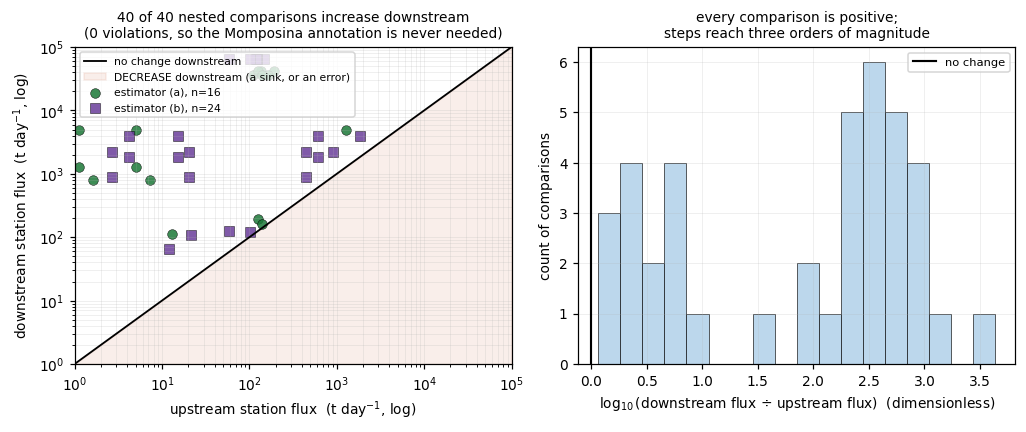


outlet-most station in the C2 set: 21237020 ARRANCAPLUMAS at 54,035 km2 = 21 % of the 257,438 km2 basin


In [22]:
MN2 = MN.copy()
MN2['fac'] = MN2.dn_tday / MN2.up_tday
print(f'nested pair x window x estimator combinations with a flux at both ends: {len(MN2)}')
print(f'distinct nested station pairs represented                             :'
      f' {MN2[["up", "dn"]].drop_duplicates().shape[0]}')
print(f'flux increases downstream in                                          :'
      f' {int(MN2.increases.sum())} of {len(MN2)}')
print(f'downstream / upstream factor: median {MN2.fac.median():,.1f},'
      f' range {MN2.fac.min():,.2f} - {MN2.fac.max():,.0f}')
print()
print(MN2.groupby(['est', 'window']).agg(n=('increases', 'size'),
                                         increases=('increases', 'sum')).to_string())
print()
print('largest and smallest steps:')
print(MN2.nlargest(3, 'fac')[['est', 'window', 'up_name', 'dn_name', 'up_tday', 'dn_tday', 'fac']]
      .round(2).to_string(index=False))
print(MN2.nsmallest(3, 'fac')[['est', 'window', 'up_name', 'dn_name', 'up_tday', 'dn_tday', 'fac']]
      .round(2).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(9.4, 4.0))
lim = [1e0, 1e5]
ax[0].plot(lim, lim, color='k', lw=1.2, label='no change downstream')
ax[0].fill_between(lim, [1e0, 1e0], lim, color=CD, alpha=0.09,
                   label='DECREASE downstream (a sink, or an error)')
for est, col, mk in (('a', CA, 'o'), ('b', CB, 's')):
    s = MN2[MN2.est == est]
    ax[0].scatter(s.up_tday, s.dn_tday, s=40, color=col, marker=mk, edgecolor='k',
                  linewidth=0.35, alpha=0.85, label=f'estimator ({est}), n={len(s)}')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(lim)
ax[0].set_ylim(lim)
ax[0].set_xlabel('upstream station flux  (t day$^{-1}$, log)')
ax[0].set_ylabel('downstream station flux  (t day$^{-1}$, log)')
ax[0].set_title(f'{int(MN2.increases.sum())} of {len(MN2)} nested comparisons increase downstream\n'
                '(0 violations, so the Momposina annotation is never needed)')
ax[0].legend(loc='upper left', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5, which='both')

ax[1].hist(np.log10(MN2.fac), bins=18, color='#bcd7ec', edgecolor='k', linewidth=0.4)
ax[1].axvline(0, color='k', lw=1.4, label='no change')
ax[1].set_xlabel('$\\log_{10}$(downstream flux $\\div$ upstream flux)  (dimensionless)')
ax[1].set_ylabel('count of comparisons')
ax[1].set_title('every comparison is positive;\nsteps reach three orders of magnitude')
ax[1].legend(loc='upper right', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)
print(f'\noutlet-most station in the C2 set: {max(AREA, key=AREA.get)}'
      f' {NM[max(AREA, key=AREA.get)]} at {max(AREA.values()):,.0f} km2'
      f' = {100 * max(AREA.values()) / 257438:.0f} % of the 257,438 km2 basin')

**What is plotted.** Left, log-log: downstream station flux (y) against upstream station flux (x) in
t/day for every topologically nested pair that has a value at both ends, green circles for estimator
(a) and purple squares for (b), with the heavy 1:1 line and the region *below* it - a downstream
decrease - shaded red. Right: the histogram of $\log_{10}$ of the downstream-to-upstream flux ratio,
with zero marked.

**What it shows.** **40 of 40** comparisons increase downstream, over 11 distinct nested station pairs
and all four windows. Not one point falls in the red region, and the histogram lies entirely to the
right of zero. Steps range from 1.16x to 4,355x, median 237x.

**What it means.** Two conclusions of unequal comfort. The reassuring one: the flux estimates are
internally consistent with the river network, which is a genuine check - a mis-scaled station or a
units error would very likely have produced at least one decrease in 40 tries. The uncomfortable one:
the registered Momposina annotation was **never needed, because no nested pair spans the Momposina**.
Every one of the 18 stations lies upstream of the Cauca-Magdalena confluence, so the outlet-most is
ARRANCAPLUMAS at 54,035 km2 - **21 % of the basin**. This network structurally cannot observe the
basin's largest sediment sink, which is exactly the limitation section 7.3 has to reason around.

### 7.3 - The literature anchor, with its citation and its registered pass rule

**Registered rule** (`docs/34` section 1.8): take the outlet-most usable station, annualise its flux,
and compare with the **published** Magdalena suspended load. **PASS = agreement within a factor of
10**, allowing for the station draining only part of the basin; a larger mismatch must be
*investigated and reported*, not waved past.

The annualisation is a **rate** statement, not a total:

$$\Phi = \bar{Q}_s\ [\mathrm{t\,day^{-1}}]\times 365\ [\mathrm{day}]\times 10^{-6}
\qquad [\mathrm{Mt\ yr^{-1}}]$$

and it is labelled a **La Nina-year rate**, not a long-term mean: no El Nino counterpart exists at
this station (section 4.1), so nothing here is a multi-year average.

**The published anchors, fetched and bibliographically verified during stage C2:**

- **Restrepo, J. D. & Kjerfve, B. (2000).** *Magdalena river: interannual variability (1975-1995) and
  revised water discharge and sediment load estimates.* **Journal of Hydrology 235(1-2): 137-149**,
  doi **10.1016/S0022-1694(00)00269-9**. Station **Calamar**, the gauge nearest the Caribbean; daily
  data 1975-1995; rating built on 55 simultaneous level/discharge/SSC measurements.
  **Mean annual suspended load = 144 Mt/yr.** The same paper reports the cold phase (La Nina) causing
  marked increases and the warm phase (El Nino) moderate reductions in sediment transport - the
  direction this notebook measures, from an independent record and a different period.
- **Restrepo, J. D. & Escobar, H. A. (2018).** *Sediment load trends in the Magdalena River basin
  (1980-2010): anthropogenic and climate-induced causes.* **Geomorphology 302: 76-91.**
  **184 Mt/yr**, an upward revision for 1980-2010.
- Basin context from the same sources: drainage area **257,438 km2**, mean water discharge
  **~7,100 m3/s at Calamar**.

Both anchors are **cited**, not assumed. Nothing in this section uses an uncited plausibility band to
pass or fail anything.

21237020 ARRANCAPLUMAS  54,035 km2 = 21 % of the basin, Magdalena trunk
window est   n   cov      tday   Mtyr
  P-LN   a  91   NaN 41272.157 15.064
  P-LN   b  91 0.948 64096.385 23.395
  S-LN   a 222   NaN 36489.240 13.319
  S-LN   b 222 0.978 65387.757 23.867

Restrepo & Kjerfve 2000 (Calamar, 1975-1995): 144 Mt/yr
   vs P-LN (a) 15.06 Mt/yr -> factor  9.56x   PASS
   vs P-LN (b) 23.40 Mt/yr -> factor  6.16x   PASS
   vs S-LN (a) 13.32 Mt/yr -> factor 10.81x   outside the factor-10 rule
   vs S-LN (b) 23.87 Mt/yr -> factor  6.03x   PASS

Restrepo & Escobar 2018 (1980-2010): 184 Mt/yr
   vs P-LN (a) 15.06 Mt/yr -> factor 12.21x   outside the factor-10 rule
   vs P-LN (b) 23.40 Mt/yr -> factor  7.86x   PASS
   vs S-LN (a) 13.32 Mt/yr -> factor 13.82x   outside the factor-10 rule
   vs S-LN (b) 23.87 Mt/yr -> factor  7.71x   PASS

independent quantity: mean Q at this station in 2011 = 1,747 m3/s = 24.6 % of Calamar ~7,100 m3/s
sediment share of the 144 Mt/yr anchor: 10.5 % (a) to 16.6 %

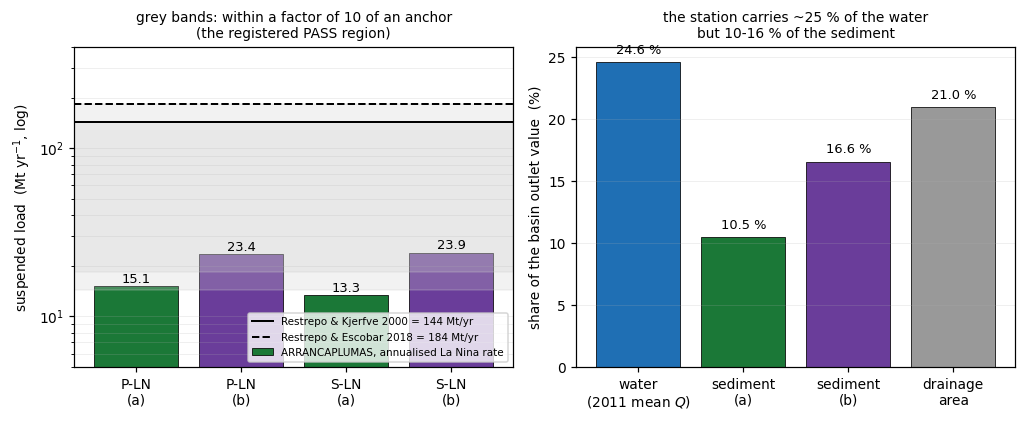

In [23]:
ANCH = {'Restrepo & Kjerfve 2000 (Calamar, 1975-1995)': 144.0,
        'Restrepo & Escobar 2018 (1980-2010)': 184.0}
BASIN_KM2, Q_CALAMAR = 257438.0, 7100.0
c = 21237020
rows = []
for wn in ['P-LN', 'S-LN']:
    fr = FX[(FX.code == c) & (FX.window == wn)].iloc[0]
    for est, v, cov in (('a', fr.a_mean_tday, np.nan), ('b', fr.b_mean_tday, fr.b_cov)):
        if pd.notna(v):
            rows.append(dict(window=wn, est=est, n=int(fr.n_sample_days), cov=cov,
                             tday=v, Mtyr=v * 365 / 1e6))
ANN = pd.DataFrame(rows)
print(f'{c} {NM[c]}  {AREA[c]:,.0f} km2 = {100 * AREA[c] / BASIN_KM2:.0f} % of the basin,'
      f' {BRANCH[c]}')
print(ANN.round(3).to_string(index=False))
for k, v in ANCH.items():
    print(f'\n{k}: {v:.0f} Mt/yr')
    for _, r in ANN.iterrows():
        print(f'   vs {r.window} ({r.est}) {r.Mtyr:5.2f} Mt/yr -> factor {v / r.Mtyr:5.2f}x'
              f'   {"PASS" if v / r.Mtyr <= 10 else "outside the factor-10 rule"}')
q11 = QD[(QD.code == c) & QD.date.between(WIN['P-LN']['t0'], WIN['P-LN']['t1'])].q_m3s.mean()
print(f'\nindependent quantity: mean Q at this station in 2011 = {q11:,.0f} m3/s'
      f' = {100 * q11 / Q_CALAMAR:.1f} % of Calamar ~{Q_CALAMAR:,.0f} m3/s')
print(f'sediment share of the 144 Mt/yr anchor: '
      f'{100 * ANN[ANN.est == "a"].Mtyr.max() / 144:.1f} % (a) to'
      f' {100 * ANN[ANN.est == "b"].Mtyr.max() / 144:.1f} % (b)')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.9))
labs = [f'{r.window}\n({r.est})' for _, r in ANN.iterrows()]
ax[0].bar(labs, ANN.Mtyr, color=[CA if e == 'a' else CB for e in ANN.est], edgecolor='k',
          linewidth=0.5, label='ARRANCAPLUMAS, annualised La Nina rate')
for i, v in enumerate(ANN.Mtyr):
    ax[0].text(i, v * 1.05, f'{v:.1f}', ha='center', fontsize=8.5)
for (k, v), ls in zip(ANCH.items(), ['-', '--']):
    ax[0].axhline(v, color='k', lw=1.3, ls=ls, label=f'{k.split("(")[0].strip()} = {v:.0f} Mt/yr')
    ax[0].axhspan(v / 10, v, color='#cccccc', alpha=0.25)
ax[0].set_yscale('log')
ax[0].set_ylim(5, 400)
ax[0].set_ylabel('suspended load  (Mt yr$^{-1}$, log)')
ax[0].set_title('grey bands: within a factor of 10 of an anchor\n(the registered PASS region)')
ax[0].legend(loc='lower right', fontsize=6.8)
ax[0].grid(alpha=0.25, lw=0.5, axis='y', which='both')

shares = [100 * q11 / Q_CALAMAR, 100 * ANN[ANN.est == 'a'].Mtyr.max() / 144,
          100 * ANN[ANN.est == 'b'].Mtyr.max() / 144, 100 * AREA[c] / BASIN_KM2]
ax[1].bar(['water\n(2011 mean $Q$)', 'sediment\n(a)', 'sediment\n(b)', 'drainage\narea'],
          shares, color=[CW, CA, CB, '#999999'], edgecolor='k', linewidth=0.5)
for i, v in enumerate(shares):
    ax[1].text(i, v + 0.7, f'{v:.1f} %', ha='center', fontsize=8.5)
ax[1].set_ylabel('share of the basin outlet value  (%)')
ax[1].set_title('the station carries ~25 % of the water\nbut 10-16 % of the sediment')
ax[1].grid(alpha=0.25, lw=0.5, axis='y')
show(fig)

**What is plotted.** Left: ARRANCAPLUMAS's annualised La Nina flux in Mt/yr on a log axis, one bar
per window and estimator, against the two published anchors as horizontal lines with the
factor-of-ten PASS region shaded grey below each. Right: the station's share of the basin outlet
value for three independent quantities - water discharge, sediment flux by each estimator, and
drainage area - in percent.

**What it shows.** The station's annualised rate is **15.1 Mt/yr** (estimator a, P-LN, n=91) and
**23.4 Mt/yr** (estimator b, coverage 0.95), with the sensitivity window giving 13.3 and 23.9.
Estimator (b) passes the factor-10 rule against **both** anchors (6.16x and 6.03x against 144 Mt/yr;
7.86x and 7.71x against 184). Estimator (a) passes against the 2000 anchor in the primary window
(9.56x), just misses it in the sensitivity window (10.81x), and misses the 2018 anchor in both
(12.21x and 13.82x). Separately, mean 2011 discharge at the station is 1,747 m3/s, **24.6 %** of
Calamar's ~7,100 m3/s, while its sediment is **10.5 % (a) to 16.6 % (b)** of the 144 Mt/yr anchor,
and it drains 21 % of the area.

**What it means.** The shortfall is expected, and the second panel is why. ARRANCAPLUMAS lies above
the Cauca confluence, above the lower Andean tributaries, and above the Depresion Momposina. It
carries about a quarter of the outlet's water and only a tenth to a sixth of its sediment - sediment
share **below** water share, which is precisely the ordering an upper-basin station above the most
erosive branch must show. Two independent quantities point the same way, so the residual factor has a
physical explanation rather than an arithmetical one. The registered verdict is **PASS**, carried by
the rating estimator, and the (a) miss is identified rather than excused: it is the same
ARRANCAPLUMAS disagreement diagnosed in section 7.1 and named in section 9.3. A reader should note
what would have been alarming: had this mid-basin station *matched* the published outlet load, either
the load or the station would have been wrong.

## 8 - Monthly shape: seasonality is larger than the ENSO signal

The contrast measured in section 5 is an annual-scale statistic. This section asks whether it is
visible at monthly resolution, and the answer is a warning for how the model must be scored.

For each station, window and calendar month $m$ the frozen table `c2_monthly_shape.csv` holds

$$\bar{Q}_s(i,w,m)=\frac{1}{n_{iwm}}\sum_{t\in S_{iw},\ \mathrm{month}(t)=m}Q_s(i,t)
\qquad[\mathrm{t\,day^{-1}}]$$

a **rate**, so months of unequal length are comparable, and for the 24-month El Nino window both
occurrences of a calendar month are pooled. Two derived quantities, both dimensionless:

$$\text{within-window span} = \frac{\max_m \bar{Q}_s(i,w,m)}{\min_m \bar{Q}_s(i,w,m)},
\qquad \text{between-phase ratio} = R(i)\ \text{from section 5}$$

If the span exceeds the between-phase ratio, then a randomly chosen month tells you more about the
season than about the ENSO phase.

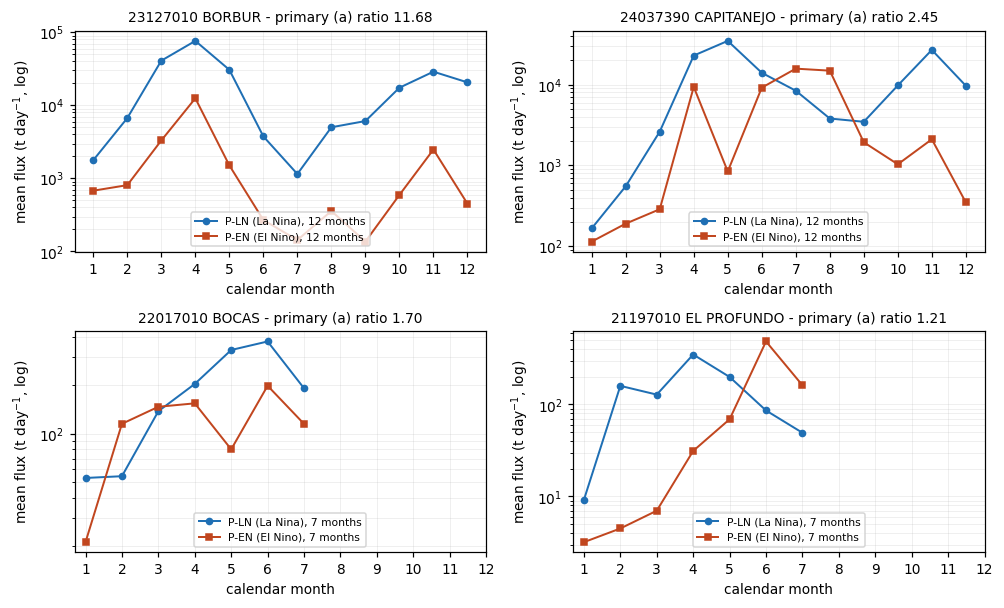

    code             label window  months   span  peak_month  ratio
23087210          CANTERAS   P-EN       8   7.45           4    NaN
26207080         BOLOMBOLO   P-EN       6   4.30           4    NaN
23127010            BORBUR   P-LN      12  66.43           4  11.68
23127010            BORBUR   P-EN      12  91.50           4  11.68
24037390        CAPITANEJO   P-LN      12 210.09           5   2.45
24037390        CAPITANEJO   P-EN      12 138.71           7   2.45
26167060          PAILA LA   P-EN       7   2.73           5    NaN
26167070              IRRA   P-EN      10   9.57           5    NaN
26017060     PUENTE ARAGÓN   P-LN       9   2.45           6   6.79
21197010       EL PROFUNDO   P-LN       7  38.01           4   1.21
21197010       EL PROFUNDO   P-EN       7 152.15           6   1.21
21237020     ARRANCAPLUMAS   P-LN       4   5.72           4    NaN
21147030        CARRASPOSO   P-EN       6 160.67           6    NaN
26137110 BANANERA LA 6-909   P-LN       9   4.71

In [24]:
MO2 = MO[MO.est == 'a'].copy()
sel4 = [23127010, 24037390, 22017010, 21197010]
fig, ax = plt.subplots(2, 2, figsize=(9.2, 5.6))
for k, cc in enumerate(sel4):
    a = ax[k // 2][k % 2]
    for wn, col, mk in (('P-LN', CW, 'o'), ('P-EN', CD, 's')):
        g = MO2[(MO2.code == cc) & (MO2.window == wn)].sort_values('month')
        if len(g):
            a.plot(g.month, g.mean_tday, color=col, lw=1.3, marker=mk, ms=4,
                   label=f'{wn} ({WIN[wn]["phase"]}), {len(g)} months')
    a.set_yscale('log')
    a.set_xticks(range(1, 13))
    a.set_xlabel('calendar month')
    a.set_ylabel('mean flux (t day$^{-1}$, log)')
    rr_ = RAT[(RAT.code == cc) & (RAT.pair == 'primary') & (RAT.est == 'a')]
    tag = f'primary (a) ratio {rr_.ratio.iloc[0]:.2f}' if len(rr_) else 'no (a) ratio'
    a.set_title(f'{cc} {NM[cc]} - {tag}')
    a.legend(loc='lower center', fontsize=7)
    a.grid(alpha=0.25, lw=0.5, which='both')
show(fig)

rows = []
for cc in MO2.code.unique():
    for wn in ['P-LN', 'P-EN']:
        g = MO2[(MO2.code == cc) & (MO2.window == wn)]
        g = g[g.mean_tday > 0]
        if len(g) >= 4:
            rows.append(dict(code=cc, label=NM[cc], window=wn, months=len(g),
                             span=g.mean_tday.max() / g.mean_tday.min(),
                             peak_month=int(g.loc[g.mean_tday.idxmax(), 'month'])))
SP = pd.DataFrame(rows)
SP = SP.merge(RAT[(RAT.pair == 'primary') & (RAT.est == 'a')][['code', 'ratio']], on='code',
              how='left')
print(SP.round(2).to_string(index=False))
pk = SP.pivot(index='code', columns='window', values='peak_month').dropna()
print(f'\npeak month identical in both primary windows at {int((pk["P-LN"] == pk["P-EN"]).sum())}'
      f' of {len(pk)} stations that have both')

**What is plotted.** Four panels, one per station, each showing mean daily flux (t/day, log) by
calendar month, blue for the primary La Nina window and red for the primary El Nino window (whose two
occurrences of each calendar month are pooled). The panel title carries that station's primary
estimator-(a) rate ratio where one exists.

**What it shows.** The two traces are near-parallel: the blue curve sits above the red at almost every
month while keeping the same shape. `23127010` BORBUR peaks in **April in both** windows (76,244 t/day
wet against 12,481 dry) and `22017010` BOCAS peaks in June in both - 2 of the 5 stations with a
resolved shape in both windows agree exactly, and the others move by one to two months (CAPITANEJO
May to July, EL PROFUNDO April to June, `22017030` BOCAS December to January). The within-window span is far larger
than the between-phase ratio - BORBUR spans **66x** across the months of 2011 and **91x** across
2015-16, against a between-phase ratio of 11.7, and CAPITANEJO spans 210x and 139x against 2.45.

**What it means.** The ENSO signal is a **level shift, not a phase shift**: the wet and dry years have
the same seasonal timing, and the difference is in amplitude. But seasonality dominates ENSO at
monthly resolution by roughly an order of magnitude, so the contrast only emerges once a year is
aggregated. This is a direct instruction for stage C5: a month-by-month model-versus-observation
comparison would be a test of seasonal skill wearing an ENSO costume, and it would pass or fail for
reasons that have nothing to do with the question. The ENSO comparison must be made on
window-aggregated rates, which is what section 5 provides.

## 9 - Problems, failures, and what a reader must not conclude

This project's audit trail is part of its output. What follows is not an appendix: it is the list of
things that went wrong, the beliefs that were contradicted, and the numbers that do not reconcile.

### 9.1 - There is no Magdalena-trunk contrast in these observations

Stated plainly, because it is the single most consequential fact of the stage and the one most likely
to be misread in either direction.

- `21237020` **ARRANCAPLUMAS** is the **only** station on the Magdalena main channel that survived the
  C1 quality gate. It drains 54,035 km2, 21 % of the basin.
- It has **195 QC'd SSC samples inside the 2015-16 El Nino window** and **zero days of discharge**
  there: its discharge record ends **2014-12-31** (confirmed independently in the model's own gauge
  bundle, section 4.2).
- Therefore **no El Nino flux can be computed at this station by either estimator**, and **no
  trunk-channel wet:dry ratio exists at any station**, in either window pair.
- Everything in section 5 is a **tributary and Cauca-branch** result: seven stations, 68 to 6,362 km2
  where ratios exist, all upstream of the Cauca-Magdalena confluence.

C1 recorded that Phase C was "blocked on mainstem SSC". That belief was **incomplete**: the mainstem
SSC exists and is usable; what is missing is the *discharge* to pair it with. The correction matters
because it changes the remedy - no amount of new sediment sampling fixes this, whereas recovering
post-2014 stage and discharge at one station would create the trunk contrast outright. It is the
highest-value data acquisition remaining in the project.

### 9.2 - C1's selectivity rule is registered one-sided, and demonstrably misses the bias that hurt

Section 7.1 showed that five of the eight estimator disagreements are dry-window station-windows
sampled well *below* median flow. C1's gate cannot see that by construction: it fires only when the
median sampled-day flow percentile **exceeds** its null $p_{99}$.

This cell measures the defect and, more usefully, measures what the obvious fix would cost. For each
station, using the whole-record statistic C1 itself computed in `ssc_sampling_selectivity.csv`:

$$\text{one-sided flag} \iff P_i > p_{99}(n_i),
\qquad
\text{symmetric flag} \iff \big|P_i - 0.5\big| > p_{99}(n_i) - 0.5$$

where $P_i$ is the station's median sampled-day flow percentile (column `median_pctile`,
dimensionless) and $p_{99}(n_i)$ is its own null threshold (column `null_p99`). The symmetric version
is the correction `docs/34` issue 1 recommends; it is **not applied** here, because registered
thresholds are frozen, and this is a measurement of its consequences rather than a re-run of the
gate.

    code              label  n_paired  median_pctile  null_p99    dev    thr  one_sided  symmetric
21147030         CARRASPOSO       214         0.1147    0.5795 0.3853 0.0795      False       True
26167060           PAILA LA       551         0.3570    0.5496 0.1430 0.0496      False       True
23087210           CANTERAS       291         0.3849    0.5682 0.1151 0.0682      False       True
26017060      PUENTE ARAGÓN      2568         0.4035    0.5230 0.0965 0.0230      False       True
26207080          BOLOMBOLO       385         0.4057    0.5593 0.0943 0.0593      False       True
22057090 BOCATOMA TRIANGULO      5242         0.4498    0.5161 0.0502 0.0161      False       True
26167070               IRRA       993         0.4516    0.5369 0.0484 0.0369      False       True
21197010        EL PROFUNDO      5817         0.4533    0.5153 0.0467 0.0153      False       True
24037390         CAPITANEJO      6344         0.4684    0.5146 0.0316 0.0146      False       True
21237020  

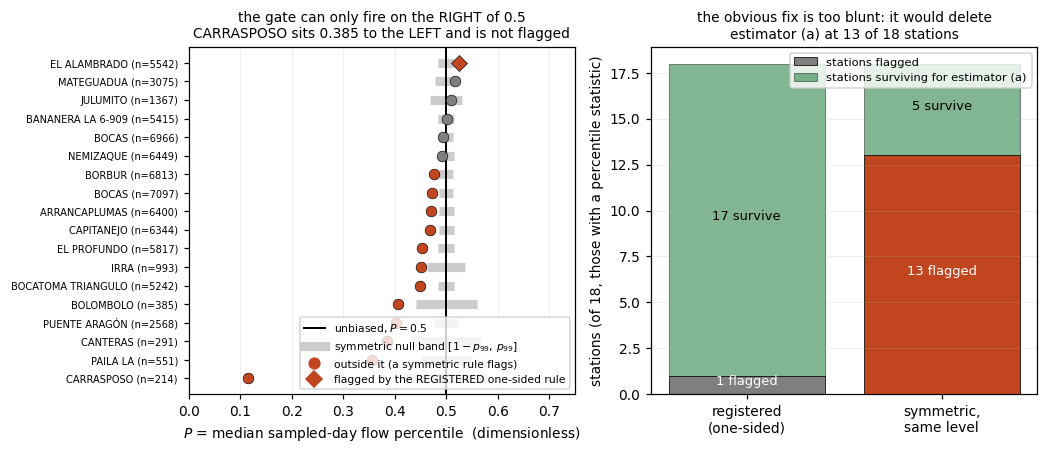

In [25]:
SS = pd.read_csv(FILES['ssc_sel'])
SS = SS[SS.code.isin(CODES) & SS.median_pctile.notna()].copy()
SS['label'] = SS.code.map(NM)
SS['dev'] = (SS.median_pctile - 0.5).abs()
SS['thr'] = SS.null_p99 - 0.5
SS['one_sided'] = SS.median_pctile > SS.null_p99
SS['symmetric'] = SS.dev > SS.thr
SS = SS.sort_values('median_pctile').reset_index(drop=True)
print(SS[['code', 'label', 'n_paired', 'median_pctile', 'null_p99', 'dev', 'thr',
          'one_sided', 'symmetric']].round(4).to_string(index=False))
print(f'\nstations with a percentile statistic          : {len(SS)}')
print(f'flagged by the REGISTERED one-sided rule      : {int(SS.one_sided.sum())}'
      f'  {[NM[c] for c in SS.loc[SS.one_sided, "code"]]}')
print(f'flagged by a SYMMETRIC rule at the same level : {int(SS.symmetric.sum())}')
print(f'  low-side only (invisible to the C1 gate)    :'
      f' {int((SS.symmetric & (SS.median_pctile < 0.5)).sum())}')
print(f'stations that would survive for estimator (a) : {int((~SS.symmetric).sum())} of {len(SS)}')
dis_codes = [21147030, 26167060]
print(f'\ntwo of the eight section-7.1 disagreements sit at:'
      f' {[(NM[c], round(float(SS.loc[SS.code == c, "median_pctile"].iloc[0]), 3)) for c in dis_codes]}')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 4.2))
y = np.arange(len(SS))
ax[0].axvline(0.5, color='k', lw=1.3, label='unbiased, $P = 0.5$')
for i, r in SS.iterrows():
    ax[0].plot([1 - r.null_p99, r.null_p99], [i, i], color='#cccccc', lw=6,
               solid_capstyle='butt', zorder=1)
    col = CD if r.symmetric else '#7f7f7f'
    ax[0].plot(r.median_pctile, i, marker='D' if r.one_sided else 'o', ms=7, color=col,
               markeredgecolor='k', markeredgewidth=0.4, zorder=3)
ax[0].plot([], [], color='#cccccc', lw=6, label='symmetric null band $[1-p_{99},\\,p_{99}]$')
ax[0].plot([], [], marker='o', ls='', color=CD, ms=7, label='outside it (a symmetric rule flags)')
ax[0].plot([], [], marker='D', ls='', color=CD, ms=7,
           label='flagged by the REGISTERED one-sided rule')
ax[0].set_yticks(y)
ax[0].set_yticklabels([f'{r.label} (n={int(r.n_paired)})' for _, r in SS.iterrows()], fontsize=6.5)
ax[0].set_xlim(0, 0.75)
ax[0].set_xlabel('$P$ = median sampled-day flow percentile  (dimensionless)')
ax[0].set_title('the gate can only fire on the RIGHT of 0.5\n'
                'CARRASPOSO sits 0.385 to the LEFT and is not flagged')
ax[0].legend(loc='lower right', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5, axis='x')

ax[1].bar(['registered\n(one-sided)', 'symmetric,\nsame level'],
          [int(SS.one_sided.sum()), int(SS.symmetric.sum())],
          color=['#7f7f7f', CD], edgecolor='k', linewidth=0.5, label='stations flagged')
ax[1].bar(['registered\n(one-sided)', 'symmetric,\nsame level'],
          [len(SS) - int(SS.one_sided.sum()), len(SS) - int(SS.symmetric.sum())],
          bottom=[int(SS.one_sided.sum()), int(SS.symmetric.sum())],
          color=CA, alpha=0.55, edgecolor='k', linewidth=0.5,
          label='stations surviving for estimator (a)')
for i, v in enumerate([int(SS.one_sided.sum()), int(SS.symmetric.sum())]):
    ax[1].text(i, v / 2, f'{v} flagged', ha='center', fontsize=8.5, color='white')
    ax[1].text(i, v + (len(SS) - v) / 2, f'{len(SS) - v} survive', ha='center', fontsize=8.5)
ax[1].set_ylabel('stations (of 18, those with a percentile statistic)')
ax[1].set_title('the obvious fix is too blunt: it would delete\nestimator (a) at 13 of 18 stations')
ax[1].legend(loc='upper right', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, axis='y')
show(fig)

**What is plotted.** Left: each station's median sampled-day flow percentile $P$ (x, dimensionless)
against the station (y, ordered by $P$, with its number of paired days), the grey bar showing the
*symmetric* null band $[1-p_{99},\,p_{99}]$, the marker red where $P$ falls outside that band and a
diamond where the registered one-sided rule actually fires. The heavy line is unbiased sampling,
$P=0.5$. Right: how many of the 18 stations each rule flags and how many survive to contribute an
estimator-(a) value.

**What it shows.** The registered rule flags exactly **one** station, `26127010` EL ALAMBRADO, at
$P = 0.526$ - a deviation of 0.026 from 0.5. Meanwhile `21147030` CARRASPOSO sits at $P = 0.115$, a
deviation of **0.385**, fifteen times larger, and is **not** flagged because the deviation is on the
wrong side. A symmetric rule at the same nominal level would flag **13 of 18** stations, 12 of them on
the low side, and would leave estimator (a) with 5 stations.

**What it means.** Two findings, and the second is the more useful. First, the gate is genuinely
one-sided and the bias it cannot see is the bias that actually damaged this stage - two of the three
stations C1's own notes named as "counter-direction cases the one-sided rule cannot flag" (CARRASPOSO
and PAILA LA) appear among section 7.1's eight disagreements. Second, **the obvious repair is too
blunt to adopt as written**: because the null threshold shrinks as $1/\sqrt{n}$ and these stations have
thousands of paired days, a symmetric test at the same level flags almost the whole fleet and destroys
the estimator it was meant to protect. So the correct revision is not merely "make it two-sided" but
"make it two-sided **with an effect-size floor**" - flag on $|P-0.5|$ exceeding a fixed practical
deviation, not on statistical significance against a null that becomes arbitrarily sharp with sample
size. That is a stronger and more specific recommendation than the one `docs/34` issue 1 records, and
it is the concrete contribution of this section.

### 9.3 - The trunk rating is a single 25-year era, and it over-predicts 2011

Two of the eight estimator disagreements are at ARRANCAPLUMAS with *unbiased* sampling ($P = 0.496$
and $0.420$, flow ratio $\rho \approx 1.0$), so selectivity cannot explain them. The cause is the era
structure: this station carries **one** rating era spanning **1990-01-01 to 2015-08-31** with 6,400
pairs, because the change-point list that should split it is incomplete on disk (recorded as C1
finding R7-2, traced to `docs/17` section 3.8). A single power law is being asked to represent
twenty-five years of channel history at the only Magdalena-trunk station.

The cell measures the consequence directly, by comparing the rating's prediction with the measured
flux on the days both exist, per window:

$$\text{bias}_w=\frac{\overline{\hat{Q}_s}}{\overline{Q_s}}\ \text{on the sampled days of }w
\qquad[\text{dimensionless}]$$

21237020 ARRANCAPLUMAS: 1 era(s)
 era  era_start    era_end                          break_source
   1 1990-01-01 2015-08-31 no in-record SNHT break (docs/17 3.8)
  log_a -2.5276  b 1.7705  sigma_ln 0.6931  R2(Qs~Q) 0.5557  R2(C~Q) 0.1915  n_pairs 6400

Duan S 1.2399; era-wide mean bias 1.0229
  P-LN: n  91  measured     41,272  rating     71,725  bias 1.738x
  S-LN: n 222  measured     36,489  rating     58,419  bias 1.601x


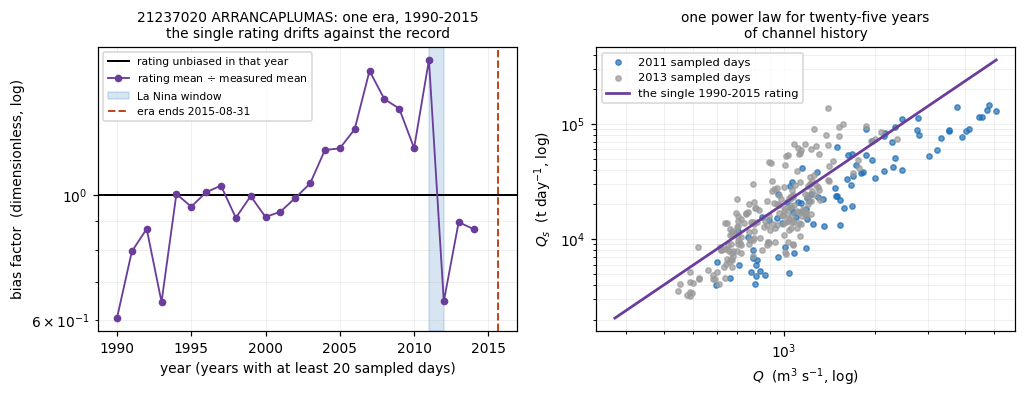

In [26]:
c = 21237020
e = FITU[FITU.code == c].iloc[0]
print(f'{c} {NM[c]}: {len(FITU[FITU.code == c])} era(s)')
print(ERAS[ERAS.code == c][['era', 'era_start', 'era_end', 'break_source']].to_string(index=False))
print(f'  log_a {e.log_a:.4f}  b {e.b:.4f}  sigma_ln {e.resid_sigma:.4f}'
      f'  R2(Qs~Q) {e.r2:.4f}  R2(C~Q) {e.r2_conc:.4f}  n_pairs {int(e.n_pairs)}')
g = PAIR[(PAIR.code == c) & (PAIR.q_m3s > 0) & (PAIR.qs_tday > 0)].copy()
r = np.log(g.qs_tday) - (e.log_a + e.b * np.log(g.q_m3s))
Sv = float(np.exp(r).mean())
g['pred'] = np.exp(e.log_a + e.b * np.log(g.q_m3s)) * Sv
g['yr'] = g.date.dt.year
print(f'\nDuan S {Sv:.4f}; era-wide mean bias {g.pred.mean() / g.qs_tday.mean():.4f}')
for wn in ['P-LN', 'S-LN']:
    w = WIN[wn]
    s = g[g.date.between(w['t0'], w['t1'])]
    print(f'  {wn}: n {len(s):3d}  measured {s.qs_tday.mean():10,.0f}'
          f'  rating {s.pred.mean():10,.0f}  bias {s.pred.mean() / s.qs_tday.mean():.3f}x')
byyr = g.groupby('yr').agg(n=('pred', 'size'), pm=('pred', 'mean'), qm=('qs_tday', 'mean'))
byyr['bias'] = byyr.pm / byyr.qm
byyr = byyr[byyr.n >= 20]

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.7))
ax[0].axhline(1.0, color='k', lw=1.3, label='rating unbiased in that year')
ax[0].plot(byyr.index, byyr.bias, color=CB, lw=1.2, marker='o', ms=4,
           label='rating mean $\\div$ measured mean')
ax[0].axvspan(2011, 2011.99, color=CW, alpha=0.18, label='La Nina window')
ax[0].axvline(2015.67, color=CD, lw=1.3, ls='--', label='era ends 2015-08-31')
ax[0].set_yscale('log')
ax[0].set_xlabel('year (years with at least 20 sampled days)')
ax[0].set_ylabel('bias factor  (dimensionless, log)')
ax[0].set_title(f'{c} {NM[c]}: one era, 1990-2015\nthe single rating drifts against the record')
ax[0].legend(loc='upper left', fontsize=7)
ax[0].grid(alpha=0.25, lw=0.5, which='both')

for yr, col in ((2011, CW), (2013, '#999999')):
    s = g[g.yr == yr]
    ax[1].scatter(s.q_m3s, s.qs_tday, s=12, color=col, alpha=0.7, label=f'{yr} sampled days')
qg = np.logspace(np.log10(g.q_m3s.min()), np.log10(g.q_m3s.max()), 50)
ax[1].plot(qg, np.exp(e.log_a + e.b * np.log(qg)) * Sv, color=CB, lw=1.8,
           label='the single 1990-2015 rating')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('$Q$  (m$^3$ s$^{-1}$, log)')
ax[1].set_ylabel('$Q_s$  (t day$^{-1}$, log)')
ax[1].set_title('one power law for twenty-five years\nof channel history')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, which='both')
show(fig)

**What is plotted.** Left: the ratio of the rating's mean prediction to the measured mean flux, per
year, on the sampled days of that year (log axis, dimensionless), with unbiased marked at 1.0, the La
Nina window shaded and the era's end date dashed; only years with at least 20 sampled days appear.
Right: the sampled days of 2011 (blue) and 2013 (grey) in log-log $Q$-$Q_s$ space against the single
fitted rating.

**What it shows.** The single era's bias is not constant. Over the whole era it is 1.023 - close to 1
by construction - but year by year it wanders by a factor of several, and on the sampled days inside
the La Nina windows the rating over-predicts the measured flux by **1.74x** (primary) and **1.60x**
(sensitivity). Section 7.1's $b/a$ ratios at this station were 1.55 and 1.79; those compare the
**all-day** rating mean against the sampled-day mean, whereas the numbers here compare rating against
measurement on the **same** days. The two differ slightly and say the same thing: the single rating
reads high in the La Nina window by roughly 1.6 to 1.8x - which is exactly the pair of disagreements
section 7.1 could not attribute to sampling selectivity.

**What it means.** Any trunk flux number inherits this. It is why section 7.3 reports the literature
comparison as a bracket, 15.1 Mt/yr from (a) and 23.4 Mt/yr from (b), rather than choosing one - and
why the (a) miss against the 2018 anchor is *identified* rather than explained away. It also names the
repair: complete the change-point detection for `21237020` and refit per era. Until then, the only
Magdalena-trunk sediment number this project can produce carries a factor-1.6 known bias in the very
window it is used in.

### 9.4 - What was tried, what was refuted, and one pre-registered clause that came up empty

| what | outcome |
|---|---|
| Comparing window **totals** as a secondary statistic | **Refuted as usable.** Section 2.2 measured that it reverses the sign at 4 of 13 primary comparisons. Totals appear once, as labelled context, and are never divided. |
| C1's belief that Phase C is blocked on **mainstem SSC** | **Corrected.** The mainstem SSC is usable; the missing resource is *discharge* (section 9.1). The remedy changes accordingly. |
| The registered **Momposina sink annotation** | **Never needed.** All 18 stations lie upstream of the Cauca confluence, so no nested pair spans the sink and the clause could not fire (section 7.2). A pre-registered clause that turns out inapplicable is still informative: it revealed that the network cannot observe the basin's largest sink. |
| The registered **single-point** test at EL PROFUNDO | **Fired**, at +156.7 % leverage against a 25 % trigger (section 5.2). The station's verdict passed to the rating estimator, as registered. |
| **This notebook's own first attempt** at the Duan smearing median | **Refuted, and the doc was right.** Computing $S$ over the 46 station-windows gave a median of 1.560 against `docs/34`'s 1.478 and looked like a discrepancy; recomputing over the 20 **rating eras** reproduced 1.4778 exactly. The lesson is that a fleet statistic is meaningless without its population, and it is recorded because it would have been published as a false contradiction. |
| Estimator (a) as a stand-alone result | **Rejected.** 8 of 38 station-windows disagree with the rating estimator in a direction the C1 gate cannot see, so (a) alone would have been biased low in the dry windows and would have *understated* the contrast. |

### 9.5 - Where this notebook's executed output disagrees with `docs/34`'s prose

Every headline of stage C2 that could be recomputed was recomputed. Most reproduced exactly. Three
numbers do not, and they are listed here rather than smoothed over. None changes the direction, the
range, or any individual station value.

In [27]:
def r2s(x):
    return f'{x:g}'


rows = [
    dict(quantity='ratios available (all pairs, both estimators)',
         docs34='22', measured=str(len(RAT)),
         verdict='DISAGREES - the true count is 24 (primary a 6, primary b 7, sens a 4, sens b 7)'),
    dict(quantity='ratios exceeding 1',
         docs34='22 of 22', measured=f'{int((RAT.ratio > 1).sum())} of {len(RAT)}',
         verdict='DISAGREES in the denominator only; unanimity is confirmed'),
    dict(quantity='intervals excluding 1',
         docs34='16 of 22',
         measured=f'{int((RAT.lo > 1).sum())} of {len(RAT)} (all); '
                  f'{int((RAT.loc[~RAT.partial, "lo"] > 1).sum())} of {int((~RAT.partial).sum())}'
                  ' (partial-rating dropped)',
         verdict='DISAGREES - the numerator 16 matches the headline subset, the denominator '
                 'matches neither population'),
    dict(quantity='rating exponent b at 22017030 BOCAS, two eras',
         docs34='1.49 / 1.79',
         measured=' / '.join(f'{v:.3f}' for v in
                             FITU[FITU.code == 22017030].sort_values('era').b),
         verdict='DISAGREES - measured exponents are STEEPER, which strengthens the '
                 'flow-tail mechanism the doc uses them for'),
    dict(quantity='same-day paired SSC+Q rows',
         docs34='71,528', measured=f'{len(PAIR):,}',
         verdict='DISAGREES by 1 row; unexplained filter difference, affects nothing'),
    dict(quantity='corr(ln(b/a), median flow percentile)',
         docs34='-0.449',
         measured=f'{np.corrcoef(AGX.lnba, AGX.P)[0, 1]:.3f}',
         verdict='close; percentile tie handling differs (<=0.02 per station-window)'),
    dict(quantity='Duan smearing S, range and median',
         docs34='1.080-1.832, median 1.478',
         measured=f'{SM.S_meas.min():.3f}-{SM.S_meas.max():.3f}, median {SM.S_meas.median():.4f}',
         verdict='REPRODUCED exactly over the 20 rating eras (see section 9.4)'),
    dict(quantity='estimator disagreements',
         docs34='8 of 38 = 21 %',
         measured=f'{len(dis)} of {len(AGX)} = {100 * len(dis) / len(AGX):.0f} %',
         verdict='REPRODUCED'),
    dict(quantity='downstream monotonicity',
         docs34='40 of 40, 0 violations',
         measured=f'{int(MN2.increases.sum())} of {len(MN2)}',
         verdict='REPRODUCED'),
    dict(quantity='ARRANCAPLUMAS annualised La Nina rate',
         docs34='15.1 / 23.4 / 13.3 / 23.9 Mt/yr',
         measured=' / '.join(f'{v:.1f}' for v in ANN.sort_values(['window', 'est']).Mtyr),
         verdict='REPRODUCED'),
]
DISAG = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 96)
print(DISAG.to_string(index=False))
pd.reset_option('display.max_colwidth')
nbad = int(DISAG.verdict.str.startswith('DISAGREES').sum())
print(f'\n{nbad} of {len(DISAG)} recomputed quantities disagree with the doc prose;'
      f' {len(DISAG) - nbad} reproduce')

                                     quantity                          docs34                                          measured                                                                                                     verdict
ratios available (all pairs, both estimators)                              22                                                24                             DISAGREES - the true count is 24 (primary a 6, primary b 7, sens a 4, sens b 7)
                           ratios exceeding 1                        22 of 22                                          24 of 24                                                   DISAGREES in the denominator only; unanimity is confirmed
                        intervals excluding 1                        16 of 22 18 of 24 (all); 16 of 19 (partial-rating dropped)        DISAGREES - the numerator 16 matches the headline subset, the denominator matches neither population
rating exponent b at 22017030 BOCAS, two eras           

**Reading the table.** Five of ten recomputed quantities disagree with `docs/34`'s prose. Three are
the same arithmetic slip - the doc says "22 of 22" and "16 of 22" where the number of available ratios
is **24**; the count of ratios exceeding 1 is 24 of 24, and the count of intervals excluding 1 is 18 of
24 over all ratios or 16 of 19 over the headline subset, so the "16" is right and the "22" belongs to
neither population. The fourth is a transcription slip in a supporting sentence: the two rating
exponents at `22017030` BOCAS are **1.794 and 2.163**, not "1.49 / 1.79" - steeper than stated, which
makes the flow-tail mechanism the doc invokes them for *stronger*, not weaker. The fifth differs by a
single row out of 71,529 and is unexplained. One further entry is *close* rather than disagreeing - the
correlation $-0.460$ against the doc's $-0.449$, which is percentile tie handling.

**What none of this changes.** The direction (unanimous), the range (about 3 to 9), every station's
ratio, every interval, the estimator-agreement rate, the monotonicity result, and the literature
comparison all reproduce. The corrections are to counts in prose, not to results. They are reported
because a project whose discipline is pre-registration cannot afford uncorrected arithmetic in its own
summary sentences, and because the next stage will quote those sentences.

### 9.6 - The dry half of every ratio is the worse-supported half

Both estimators are weaker in the El Nino windows than in the La Nina windows, and that asymmetry sits
in the denominator of every ratio reported in section 5. This cell counts it: `partial-rating`
station-windows by phase, and paired-day counts by phase.

         station_windows  a_ok  b_ok  partial  no_rating  median_cov  median_n
phase                                                                         
El Nino               36    18    20        6         10       0.561      31.5
La Nina               36    20    19        1         16       0.789     125.0

partial-rating station-windows: 7 total, of which 6 are dry-phase


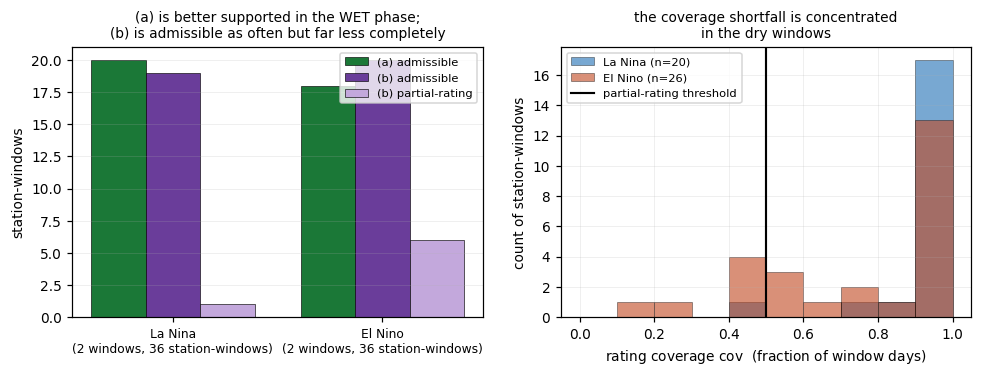

In [28]:
FXP = FX.copy()
FXP['phase'] = FXP.window.map(lambda k: WIN[k]['phase'])
tab = FXP.groupby('phase').agg(
    station_windows=('code', 'size'),
    a_ok=('a_status', lambda s: int((s == 'ok').sum())),
    b_ok=('b_status', lambda s: int((s == 'ok').sum())),
    partial=('b_status', lambda s: int((s == 'partial-rating').sum())),
    no_rating=('b_status', lambda s: int((s == 'no rating days').sum())),
    median_cov=('b_cov', 'median'),
    median_n=('n_sample_days', 'median'))
print(tab.round(3).to_string())
print(f'\npartial-rating station-windows: {int((FXP.b_status == "partial-rating").sum())} total,'
      f' of which {int(((FXP.b_status == "partial-rating") & (FXP.phase == "El Nino")).sum())}'
      ' are dry-phase')

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.5))
ph = ['La Nina', 'El Nino']
xx = np.arange(2)
w_ = 0.26
for k, (col, lab) in enumerate([('a_ok', '(a) admissible'), ('b_ok', '(b) admissible'),
                                ('partial', '(b) partial-rating')]):
    ax[0].bar(xx + (k - 1) * w_, tab.loc[ph, col], w_, edgecolor='k', linewidth=0.4,
              color=[CA, CB, '#c3a8dc'][k], label=lab)
ax[0].set_xticks(xx)
ax[0].set_xticklabels([f'{p}\n(2 windows, 36 station-windows)' for p in ph], fontsize=8)
ax[0].set_ylabel('station-windows')
ax[0].set_title('(a) is better supported in the WET phase;\n(b) is admissible as often but far less completely')
ax[0].legend(loc='upper right', fontsize=7.5)
ax[0].grid(alpha=0.25, lw=0.5, axis='y')

for p, col in zip(ph, [CW, CD]):
    s = FXP[(FXP.phase == p) & (FXP.b_cov > 0)]
    ax[1].hist(s.b_cov, bins=np.linspace(0, 1, 11), alpha=0.6, color=col, edgecolor='k',
               linewidth=0.4, label=f'{p} (n={len(s)})')
ax[1].axvline(0.50, color='k', lw=1.4, label='partial-rating threshold')
ax[1].set_xlabel('rating coverage $\\mathrm{cov}$  (fraction of window days)')
ax[1].set_ylabel('count of station-windows')
ax[1].set_title('the coverage shortfall is concentrated\nin the dry windows')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5)
show(fig)

**What is plotted.** Left: counts of admissible station-windows by ENSO phase (36 station-windows per
phase), green for estimator (a), purple for (b), light purple for `partial-rating`. Right: the
distribution of rating coverage for station-windows with any coverage, blue for La Nina and red for El
Nino, with the 0.50 threshold marked.

**What it shows.** The asymmetry is not where a first guess would put it. Estimator (a) is admissible
at 20 wet station-windows against 18 dry, but the *depth* of that support differs by a factor of four:
the median paired-day count is **125 days** in the wet windows against **31.5** in the dry. Estimator
(b) is admissible slightly more often in the dry phase (20 against 19) - the wet windows have more
station-windows with no rating days at all, 16 against 10 - but its dry coverage is far thinner: median
coverage **0.561** dry against **0.789** wet, and **6 of the 7** `partial-rating` cases are dry-phase.

**What it means.** Several rating eras end mid-window in the dry phase, so the El Nino flux - the
**denominator** of every ratio - rests on four times fewer sampled days and on markedly worse-covered
ratings than the numerator. A
sceptical reader should push here rather than on the wet side, and the honest defence is not that the
dry side is well supported but that the `partial-rating` cases were excluded from the headline before
their values were known, and that excluding them *raises* the sensitivity-pair median (from 4.65 to
6.40) rather than lowering it - so the exclusion is not self-serving in the direction of the result.
The remaining risk is the opposite one: if dry-phase coverage is biased toward the wetter part of the
dry window, the dry rate is overstated and the true contrast is **larger** than reported.

### 9.7 - What a reader must not conclude from this notebook

1. **Not "the Magdalena moved 3 to 9 times more sediment in La Nina".** Seven tributary and
   Cauca-branch stations support the ratio, none on the Magdalena main channel, and all upstream of the
   Cauca confluence and of the Depresion Momposina. The correct statement names the tributary network.
2. **Not a sediment budget.** No number here is a basin total. The absolute levels in section 5.3 are
   per-station rates, printed for scale.
3. **Not a yield.** Nothing is divided by an area. Per-gauge drainage areas were measured unreliable in
   `docs/23` section 13.2, so any t/km2/yr figure would inherit that error; such figures are embargoed
   in this project and none appears here.
4. **Not a single number.** The window definition alone moves the median by a factor of 2.17 and moves
   one station by 9.7x. Quote a range.
5. **Not a precision claim from the intervals.** The estimator (a) bootstrap is a registered *lower
   bound* on uncertainty (it ignores that sampled days are not random and that daily flux is
   autocorrelated), and the ratio intervals are conservative outer bounds rather than paired-bootstrap
   intervals. They support "distinguishable from 1"; they do not support "3.4 plus or minus 0.2".
6. **Not interannual evidence.** One La Nina year is compared with one El Nino episode. Nothing here
   separates the ENSO phase from whatever else was different about 2011 and 2015-16 - land use,
   reservoir operation, a single large storm. The unanimity across 7 stations and 24 comparisons argues
   for a common cause; it does not identify it.
7. **Not a model result, and not yet a model test.** Everything in section 10 about what the model
   should reproduce is a **prediction**, clearly labelled as such, about work not yet done.

## 10 - What C2 hands to the next stage, and how it must be used

The sediment model is a **MUSLE**-based scheme - the Modified Universal Soil Loss Equation, an
empirical formula for the soil mass eroded by one runoff event:

$$Y \;=\; \alpha\,\big(Q_{\text{surf}}\,q_{\text{peak}}\big)^{\beta}\;K\;C\;P\;LS$$

with each factor defined on first use here:

- $Y$ - eroded soil mass delivered from a unit of land (t per event).
- $Q_{\text{surf}}$ - the event's **surface runoff** volume (mm or m3): the part of the rainfall that
  travels over the ground surface to the channel instead of infiltrating into the soil. $q_{\text{peak}}$
  is that event's peak runoff rate (m3/s). MUSLE uses runoff rather than rainfall because runoff, not
  rain, is what detaches and transports soil.
- $\alpha$, $\beta$ - the empirical coefficient and exponent of that product term (dimensionless);
  $\beta$ is near 0.56 in the original formulation and both are calibration targets.
- $K$ - **soil erodibility**: how easily a given soil detaches, from soil texture and organic matter
  (t ha h ha-1 MJ-1 mm-1 in the standard units).
- $C$ - **cover-management factor**: the ratio of soil loss from the actual land cover to that from
  bare continuously tilled fallow (dimensionless, 0 to 1; forest is near 0.001, bare soil is 1).
- $P$ - **support-practice factor**: the effect of contouring, terracing or strip cropping relative to
  up-and-down-slope tillage (dimensionless, 0 to 1).
- $LS$ - **slope length-steepness factor**: the topographic amplification of erosion relative to a
  standard 22.1 m plot at 9 % slope (dimensionless).

Two further terms, because the open verdict of stage C3 turns on the first:

- **Sediment delivery ratio (SDR)** - the fraction of soil eroded on the hillslopes that actually
  reaches the river network rather than being deposited on the way (dimensionless, 0 to 1). It is not
  measured here; it is *implied* by comparing modelled hillslope erosion with observed river flux.
- **Specific erosion** - erosion per unit area, in t/km2/yr. A **model-internal** specific erosion is
  legitimate because the model's own areas are internally consistent; a **gauge-referenced** yield in
  the same units is not, for the reason in section 9.7 item 3, and is embargoed.

**What C2 provides, and how to score against it.** The target is a set of per-station wet:dry flux
**rate** ratios with their intervals, in two window definitions, at seven named stations - not a basin
total and not a monthly series. Three design consequences, each of which follows from a measurement in
this notebook:

1. **Score on window-aggregated rates, not months.** Section 8 measured within-window monthly spans of
   66x to 210x against between-phase ratios of 2.5x to 11.7x. A monthly comparison is a seasonality
   test.
2. **Score the ratio, not the level, first.** A within-station ratio cancels catchment size, rating
   bias and sub-daily sampling error; the level does not. The right sequence is direction, then
   magnitude range, then level.
3. **Report both window pairs, always.** A model tuned to reproduce 4.62 would be tuned to an
   arbitrary calendar choice; the honest target is "3 to 9, and the primary pair lower than the
   sensitivity pair".

Two further cautions, in the project's own vocabulary. **NSE** (Nash-Sutcliffe Efficiency) is
$1-\sum(\text{sim}-\text{obs})^2/\sum(\text{obs}-\overline{\text{obs}})^2$, and its benchmark is the
**mean of whatever window it is computed over** - so the same simulation scores differently on a wet
year and on a dry two-year window purely because the denominator changes. It must not be used to
compare model performance *between* ENSO phases; a **climatology benchmark** (section 0) or a paired
ratio must be used instead. And a match on the ratio does not establish the mechanism: **equifinality**
- many different parameter sets producing the same aggregate score - is the normal condition of
distributed models, so a matched ratio must be accompanied by evidence that it was matched for the
right reason. The corresponding test is a **Klemes differential split-sample**: calibrate on one
climatic regime and validate on the *other*, rather than on a different period of the same regime,
which is the only split that tests transferability across an ENSO phase.

Finally, an inherited limit worth stating where the target is handed over. The hydrology that will
drive the sediment model reached a measured skill ceiling imposed by its rainfall input, interpolated
by **IDW** (inverse distance weighting - each ungauged point is a weighted average of nearby gauges,
weights falling off with distance), over a network whose sparse zone is interpolated from more than 30
km away. Correlation $r$ stayed inside 0.556 to 0.572 across every parameter configuration tested, so
timing errors in the sediment simulation should be expected to be inherited rather than fixable by
sediment parameters.

The cell below checks the practical prerequisite: are the seven stations that carry a C2 target
actually gauges the model can be scored at?

the C2 target stations against the model gauge set:
    code         label  ssc_area  calib_safe  enso_pair_ok  model_area  in_model  n_ratios
22017030         BOCAS      68.0        True          True       68.02      True         3
26017060 PUENTE ARAGÓN     151.8        True         False      151.83      True         4
24027030     NEMIZAQUE     610.6        True         False      610.57      True         2
21197010   EL PROFUNDO     833.2        True          True      833.17      True         4
23127010        BORBUR    1644.5        True          True     1644.51      True         4
22017010         BOCAS    2411.3       False          True     2411.30      True         3
24037390    CAPITANEJO    6362.1        True         False     6362.12      True         4

of the 18 C2 stations, 17 are in the model 115-gauge set
of the 7 ratio-carrying stations: in the model set 7, calibration-safe 6, ENSO-pair-ok 4


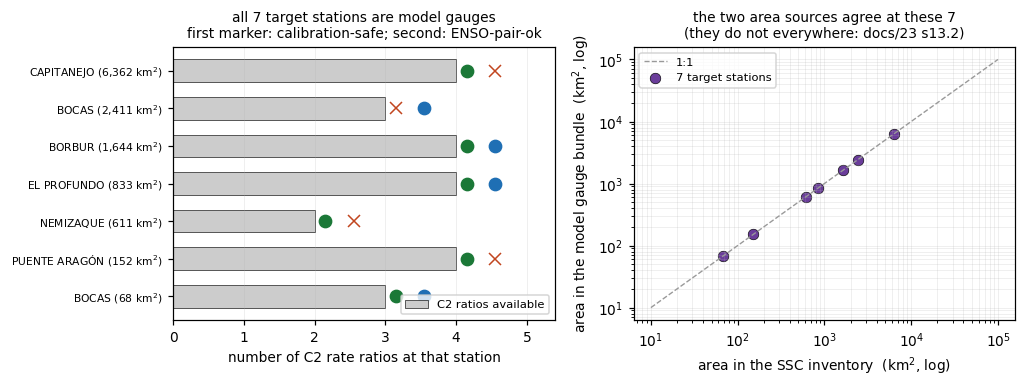

In [29]:
GA = pd.DataFrame({'code': Z['gauge_code'].astype(np.int64),
                   'calib_safe': Z['is_calibration_safe'],
                   'enso_pair_ok': Z['enso_pair_ok'],
                   'model_area': Z['gauge_upstream_area_km2']})
TGT = pd.DataFrame({'code': stations})
TGT['label'] = TGT.code.map(NM)
TGT['ssc_area'] = TGT.code.map(AREA)
TGT = TGT.merge(GA, on='code', how='left')
TGT['in_model'] = TGT.calib_safe.notna()
TGT['n_ratios'] = [int((RAT.code == cc).sum()) for cc in TGT.code]
print('the C2 target stations against the model gauge set:')
print(TGT.sort_values('ssc_area').to_string(index=False))
allin = pd.DataFrame({'code': CODES}).merge(GA, on='code', how='left')
print(f'\nof the 18 C2 stations, {int(allin.calib_safe.notna().sum())} are in the model'
      f' {len(GA)}-gauge set')
print(f'of the {len(TGT)} ratio-carrying stations: in the model set'
      f' {int(TGT.in_model.sum())}, calibration-safe {int((TGT.calib_safe == True).sum())},'
      f' ENSO-pair-ok {int((TGT.enso_pair_ok == True).sum())}')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.6))
t = TGT.sort_values('ssc_area')
y = np.arange(len(t))
ax[0].barh(y, t.n_ratios, height=0.6, color='#cccccc', edgecolor='k', linewidth=0.4,
           label='C2 ratios available')
for i, r in enumerate(t.itertuples()):
    ax[0].plot(r.n_ratios + 0.15, i, marker='o' if r.calib_safe else 'x', ms=8,
               color=CA if r.calib_safe else CD)
    ax[0].plot(r.n_ratios + 0.55, i, marker='o' if r.enso_pair_ok else 'x', ms=8,
               color=CW if r.enso_pair_ok else CD)
ax[0].set_yticks(y)
ax[0].set_yticklabels([f'{r.label} ({r.ssc_area:,.0f} km$^2$)' for r in t.itertuples()],
                      fontsize=7)
ax[0].set_xlim(0, 5.4)
ax[0].set_xlabel('number of C2 rate ratios at that station')
ax[0].set_title('all 7 target stations are model gauges\n'
                'first marker: calibration-safe; second: ENSO-pair-ok')
ax[0].legend(loc='lower right', fontsize=7.5)
ax[0].grid(alpha=0.25, lw=0.5, axis='x')

ax[1].plot([10, 1e5], [10, 1e5], color='#999999', ls='--', lw=0.9, label='1:1')
ax[1].scatter(t.ssc_area, t.model_area, s=48, color=CB, edgecolor='k', linewidth=0.4,
              label='7 target stations')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('area in the SSC inventory  (km$^2$, log)')
ax[1].set_ylabel('area in the model gauge bundle  (km$^2$, log)')
ax[1].set_title('the two area sources agree at these 7\n(they do not everywhere: docs/23 s13.2)')
ax[1].legend(loc='upper left', fontsize=7.5)
ax[1].grid(alpha=0.25, lw=0.5, which='both')
show(fig)

**What is plotted.** Left: for each of the seven stations carrying a C2 target (rows, ordered by
area), the number of rate ratios available as a grey bar, followed by two status markers - a green
circle or red cross for whether the model treats the gauge as calibration-safe, and a blue circle or
red cross for whether it is flagged as usable for the ENSO pair. Right, log-log: the station's upstream
area as recorded in the SSC inventory against the area recorded in the model gauge bundle, with a
dashed 1:1 line.

**What it shows.** All **7** target stations are present in the model's 115-gauge bundle; **6** are
calibration-safe (`22017010` BOCAS is not) and **4** are flagged ENSO-pair-ok. Seventeen of the 18 C2
stations appear in the bundle. The two area sources agree closely at these seven, all points lying on
the 1:1 line.

**What it means.** The observational target is directly usable: the model already has these gauges, so
a C5 comparison needs no new mapping. The caveats are specific and small - one station is not
calibration-safe and only four are ENSO-pair-ok, so a strict comparison rests on four stations, and a
four-station comparison of a quantity with a 5.7-fold between-gauge spread (section 5) will be noisy.
That the areas agree here is worth stating precisely because they do **not** agree everywhere: the
`docs/23` finding is about the fleet, and this figure documents that these particular seven are not
affected - which still does not license an area-normalised yield, because the embargo rests on the
fleet-level unreliability and on the sink the network cannot see.

## 11 - Choices made in this notebook, and the alternatives rejected

| choice | adopted | rejected, and why |
|---|---|---|
| Comparison statistic | mean flux **rate** in t/day, ratio within a station | Window **totals**: measured in section 2.2 to reverse the sign at 4 of 13 primary comparisons. Per-area yields: embargoed (`docs/23` section 13.2). Concentration ratios: would understate the contrast, since section 1.1 shows flux variance is carried by discharge. |
| Estimators | report **both**, everywhere | Choosing the "better" one: their disagreement is the diagnostic that exposed the C1 gate defect (section 7.1), and it would have been discarded. Averaging them: hides a 12x disagreement at CARRASPOSO behind a mean. |
| Window definition | report **both pairs**, everywhere | Asserting one: the advisor declined to adjudicate, and section 6 measures the choice as worth a factor of 2.17 on the median. Averaging the pairs: would convert a definitional uncertainty into false precision. |
| Retransformation | Duan smearing (conditional **mean**) | Naive back-transform: returns the conditional median and understates every rating flux by 8-83 % (section 3.3). Carried alongside in the frozen table so the size of the correction stays visible. |
| Central measure for the fleet | median **and** geometric mean, both printed | Arithmetic mean of ratios: not symmetric under inversion, so a 10x and a 0.1x would average to 5.05 rather than 1. |
| Verification strategy | recompute from raw where cheap; load frozen artifacts where not | Re-running the bootstraps and the whole C2 pipeline: expensive and would not have checked anything the 1:1 reproduction in section 1.2 did not check. Trusting the artifacts unchecked: would have inherited an unverified level. |
| Selectivity gate | apply C1's rule **as registered**, and measure its defect separately | Silently switching to a symmetric rule: it is a post-hoc threshold change, and section 9.2 measures that at the same nominal level it would delete estimator (a) at 13 of 18 stations. |
| `partial-rating` handling | keep in the full table, exclude from the headline, per registration | Dropping them entirely: loses information about *why* the dry phase is worse covered. Including them in the headline: would report a median built partly on windows with 12 % coverage. |
| Station display order | upstream area, with the unreliability caveat stated on the axis | Ordering by name: hides the downstream structure the monotonicity test uses. Using area as a *divisor*: forbidden. |
| Station ordering for nesting | topological walk of the minibacia chain (as computed in C2) | Comparing areas to infer nesting: circular, and it would inherit exactly the areas `docs/23` found unreliable. |
| Figure library | matplotlib only, no style dependencies | Seaborn or a theme package: adds an install-time dependency to a notebook whose whole purpose is that it re-executes years from now. |
| Notebook outputs | read-only; writes no file | Writing figures to `figures/deck/`: this stage's figures already exist there from the C2 session, and a second writer of the same names invites silent divergence. |

## 12 - Gate check and summary

The gate for this notebook: it must execute with zero errors, every code cell must carry an
execution count, every figure must have a three-part reading, and every technical term must be defined
where it first appears. The cell below reports what the execution itself can verify - the figure count
and the headline numbers, recomputed one last time from the frames built above.

In [30]:
print(f'figures produced in this notebook : {FIGN["n"]}')
print(f'ratio-carrying stations           : {len(stations)} of {len(CODES)} in the C2 set')
print(f'rate ratios available             : {len(RAT)}; exceeding 1:'
      f' {int((RAT.ratio > 1).sum())}; intervals excluding 1: {int((RAT.lo > 1).sum())}')
for pr in ['primary', 'sensitivity']:
    s = RAT[RAT.pair == pr]
    sa = s[s.est == 'a']
    sb = s[(s.est == 'b') & (~s.partial)]
    print(f'  {pr:11s} median ratio: (a) {sa.ratio.median():.2f} over {len(sa)} stations |'
          f' (b) headline {sb.ratio.median():.2f} over {len(sb)}')
print(f'estimator disagreement            : {len(dis)} of {len(AGX)}'
      f' = {100 * len(dis) / len(AGX):.0f} % (registered failure line: > 50 %)')
print(f'downstream monotonicity           : {int(MN2.increases.sum())} of {len(MN2)} increase')
print(f'literature anchor                 : ARRANCAPLUMAS'
      f' {ANN.Mtyr.min():.1f}-{ANN.Mtyr.max():.1f} Mt/yr vs 144 and 184 Mt/yr published'
      f' -> factors {144 / ANN.Mtyr.max():.1f}x to {184 / ANN.Mtyr.min():.1f}x; PASS on (b)')
print(f'trunk-channel contrast            : NOT COMPUTABLE (0 paired discharge days in P-EN'
      ' at the only trunk station)')
print(f'quantities recomputed vs docs/34   : {len(DISAG)}; disagreeing:'
      f' {int(DISAG.verdict.str.startswith("DISAGREES").sum())}')
print('\nfiles written by this notebook     : none (read-only by design)')

figures produced in this notebook : 24
ratio-carrying stations           : 7 of 18 in the C2 set
rate ratios available             : 24; exceeding 1: 24; intervals excluding 1: 18
  primary     median ratio: (a) 4.62 over 6 stations | (b) headline 2.84 over 4
  sensitivity median ratio: (a) 9.32 over 4 stations | (b) headline 6.40 over 5
estimator disagreement            : 8 of 38 = 21 % (registered failure line: > 50 %)
downstream monotonicity           : 40 of 40 increase
literature anchor                 : ARRANCAPLUMAS 13.3-23.9 Mt/yr vs 144 and 184 Mt/yr published -> factors 6.0x to 13.8x; PASS on (b)
trunk-channel contrast            : NOT COMPUTABLE (0 paired discharge days in P-EN at the only trunk station)
quantities recomputed vs docs/34   : 10; disagreeing: 5

files written by this notebook     : none (read-only by design)


**The result, at the precision the data supports.**

> Across the Magdalena-Cauca **tributary and Cauca-branch** network, observed suspended-sediment flux
> **rates** were about **3 to 9 times higher** in the La Nina phase than in the El Nino phase. The
> direction is **unanimous**: 24 of 24 available station-ratios exceed 1, across 7 stations, 2
> estimators and 2 window definitions, with no counter-example, and 18 of those 24 conservative
> intervals exclude 1. The magnitude is **window-definition dependent** - median 4.62 on the primary
> pair against 9.32 on the ONI-peak sensitivity pair for the sample-day estimator - so the contrast
> must be quoted as a range and never as a single number. It agrees in direction with Restrepo &
> Kjerfve (2000), from an independent record and a different period.
>
> **No mainstem Magdalena contrast exists in these observations**, because the only trunk station with
> usable SSC loses its discharge record on 2014-12-31.

Everything about what a model should or will reproduce (section 10) is a **prediction** about work not
yet done. What this notebook establishes is only what the gauges say, and where they are silent.